# 022. Mixture of Experts(MoE) / Mixture of Experts

## 1. 概要 / Overview

MoE(Mixture of Experts)は、Transformer Block の Feed-Forward Network(順伝播ネットワーク)を、複数の **エキスパート(expert)** と、
トークンごとにどのエキスパートを通すかを決める **ルーター(router)** に置き換える構造である。各トークンは一部のエキスパートだけを
通るので、総パラメータ数を増やしても、トークンあたりの計算量はほとんど増えない(条件付き計算、conditional computation)。
本トピックでは、ルーティング(routing)、top-k の選択、エキスパートの容量と capacity factor(容量係数)によるトークンの破棄、
負荷分散損失(load balancing loss)、router z-loss をスクラッチ実装し、008 と同じレシピの小型 GPT を密なモデルと MoE のそれぞれで
最初から事前学習して、(A)計算量を揃えた密なモデルより検証集合の bits-per-byte が下がるか、(B)負荷分散損失をなくすと
エキスパートへの負荷が偏るか、(C)エキスパート数を等比で増やしたときの改善幅が逓減するか、を検証する。あわせて、
(D)エキスパートがトークンの種類に応じて専門化しているかを、判定基準を設けずに観察する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
30 通りの **実行計画**(6.1 節。学習ステップ数 $T$・学習率の較正の方式・**削る段階** 0〜4 の組)のそれぞれについて残りの実行時間を
見積もり、予算に収まる計画のうち優先順位の最も高いものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。
**選ばれた計画は 6.4 節の出力に印字される。** 事前の計測のための実行やセッションの分割はしない。

**見積もりが最も下位の計画でも予算を超える場合は、学習の前に停止する。** その場合は結果の情報を何も得ていないので、実行条件
(判定基準・水準・前提条件以外)を直して再実行する。

学習したモデルは、すべて条件間の比較のためのものであり、Hugging Face Hub にはアップロードしない。

### 1.2 本番実行の結果の要約

(本番実行の後に記入する。7 節の末尾の「本番実行の後に更新が必要な箇所」を参照。)

## 2. 参考論文 / References

1. Shazeer, N., Mirhoseini, A., Maziarz, K., Davis, A., Le, Q., Hinton, G., Dean, J.,
   "Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer", ICLR 2017. https://arxiv.org/abs/1701.06538
   (疎なゲートの MoE 層、noisy top-k gating、importance と load の 2 つの損失。3.2・3.5・3.8 節)
2. Lepikhin, D., Lee, H., Xu, Y., Chen, D., Firat, O., Huang, Y., Krikun, M., Shazeer, N., Chen, Z.,
   "GShard: Scaling Giant Models with Conditional Computation and Automatic Sharding", ICLR 2021. https://arxiv.org/abs/2006.16668
   (Transformer の順伝播ネットワークを MoE にする構成、top-2、エキスパートの容量とトークンの破棄。3.3・3.4 節)
3. Fedus, W., Zoph, B., Shazeer, N.,
   "Switch Transformers: Scaling to Trillion Parameter Models with Simple and Efficient Sparsity", JMLR 2022.
   https://arxiv.org/abs/2101.03961(top-1 ルーティング、負荷分散損失、capacity factor、ルーターの FP32 計算、初期化の縮小。
   本トピックの主構成の原典。3.2〜3.6 節、実験 A・B)
4. Zoph, B., Bello, I., Kumar, S., Du, N., Huang, Y., Dean, J., Shazeer, N., Fedus, W.,
   "ST-MoE: Designing Stable and Transferable Sparse Expert Models", arXiv:2202.08906, 2022. https://arxiv.org/abs/2202.08906
   (router z-loss、学習時と評価時の capacity factor。3.4・3.6 節)
5. Clark, A., de las Casas, D., Guy, A., Mensch, A., Paganini, M., Hoffmann, J., Damoc, B., Hechtman, B., Cai, T., Borgeaud, S.,
   van den Driessche, G., Rutherford, E., Hennigan, T., Johnson, M., Millican, K., Cassirer, A., Jones, C., Buchatskaya, E., Budden, D.,
   Sifre, L., Osindero, S., Vinyals, O., Rae, J., Elsen, E., Kavukcuoglu, K., Simonyan, K.,
   "Unified Scaling Laws for Routed Language Models", ICML 2022. https://arxiv.org/abs/2202.01169
   (エキスパート数を増やしたときの改善の収穫逓減。3.8 節、実験 C)
6. Zhou, Y., Lei, T., Liu, H., Du, N., Huang, Y., Zhao, V., Dai, A., Chen, Z., Le, Q., Laudon, J.,
   "Mixture-of-Experts with Expert Choice Routing", NeurIPS 2022. https://arxiv.org/abs/2202.09368(3.8 節、位置づけのみ)
7. Jiang, A. Q., Sablayrolles, A., Roux, A., Mensch, A., Savary, B., Bamford, C., Chaplot, D. S., de las Casas, D., Bou Hanna, E.,
   Bressand, F., Lengyel, G., Bour, G., Lample, G., Lavaud, L. R., Saulnier, L., Lachaux, M.-A., Stock, P., Subramanian, S., Yang, S.,
   Antoniak, S., Le Scao, T., Gervet, T., Lavril, T., Wang, T., Lacroix, T., El Sayed, W.,
   "Mixtral of Experts", arXiv:2401.04088, 2024. https://arxiv.org/abs/2401.04088(8 個のエキスパートから 2 個を選ぶ decoder-only の
   言語モデル。3.3 節)
8. Dai, D., Deng, C., Zhao, C., Xu, R. X., Gao, H., Chen, D., Li, J., Zeng, W., Yu, X., Wu, Y., Xie, Z., Li, Y. K., Huang, P., Luo, F.,
   Ruan, C., Sui, Z., Liang, W.,
   "DeepSeekMoE: Towards Ultimate Expert Specialization in Mixture-of-Experts Language Models", ACL 2024.
   https://arxiv.org/abs/2401.06066(細粒度のエキスパートと共有エキスパート。3.8 節、位置づけのみ)
9. Wang, L., Gao, H., Zhao, C., Sun, X., Dai, D.,
   "Auxiliary-Loss-Free Load Balancing Strategy for Mixture-of-Experts", arXiv:2408.15664, 2024. https://arxiv.org/abs/2408.15664
   (補助損失を使わない負荷分散。3.8 節、位置づけのみ)
10. Komatsuzaki, A., Puigcerver, J., Lee-Thorp, J., Riquelme Ruiz, C., Mustafa, B., Ainslie, J., Tay, Y., Dehghani, M., Houlsby, N.,
    "Sparse Upcycling: Training Mixture-of-Experts from Dense Checkpoints", ICLR 2023. https://arxiv.org/abs/2212.05055
    (3.8 節、位置づけのみ)

本文で用いる既存トピックの部品: SwiGLU の順伝播ネットワークは [004](../01_foundations/004_normalization_and_activation.ipynb)、
小型 GPT と bits-per-byte は [006](../02_pretraining/006_pretraining_small_gpt.ipynb)、AdamW・warmup + cosine・gradient clipping は
[007](../02_pretraining/007_training_stabilization.ipynb)、本トピックが踏襲する事前学習のレシピは
[008](../02_pretraining/008_decoding_strategies.ipynb)、FP16 の autocast と動的損失スケーリングは
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、記事を単位とするクラスタブートストラップは
[015](../03_efficient_training/015_long_context_extension.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 総パラメータ数とトークンあたりの計算量を切り離す

密な Transformer では、パラメータ数を増やすと、すべてのトークンがすべてのパラメータを通るので、トークンあたりの計算量も同じ割合で
増える。たとえば SwiGLU の順伝播ネットワーク(004)は、入出力の次元を $d_{\mathrm{model}}$、中間次元を $d_{\mathrm{ff}}$ として 3 つの
行列を持ち、パラメータ数も 1 トークンあたりの積和の回数も $3 d_{\mathrm{model}} d_{\mathrm{ff}}$ である。中間次元を 8 倍にすれば、
パラメータ数も計算量も 8 倍になる。

**条件付き計算(conditional computation)** は、入力ごとにネットワークの一部だけを使うことで、この 2 つを切り離す。MoE(Mixture of
Experts)層(Shazeer et al. [1])は、同じ形の小さなネットワーク **エキスパート** を $N$ 個並べ、入力ごとに $k$ 個($k \ll N$)だけを
選んで計算する。Lepikhin et al. [2](GShard)と Fedus et al. [3](Switch Transformer)は、これを Transformer の順伝播ネットワークに
適用した。順伝播ネットワークは位置ごとに独立に働くので(002)、**トークンごと** に通すエキスパートを変えられる。

**記号**(Fedus et al. [3] の表記に従う):

- $N$: エキスパート数。$T$: 1 つのバッチのトークン数(バッチサイズ × 系列長)。$k$: 1 トークンが通るエキスパートの数。
- $x \in \mathbb{R}^{d_{\mathrm{model}}}$: MoE 層に入るトークンの表現(正規化前置なので、正規化層の出力)。
- $E_i(x)$: $i$ 番目のエキスパートの出力。本トピックでは $E_i(x) = (\mathrm{Swish}(x W_i) \odot x V_i) W_{2,i}$ で、形も大きさも密なモデルの
  順伝播ネットワークと同じにする($\odot$ は要素ごとの積)。

このとき、MoE 層のパラメータ数は $N \cdot 3 d_{\mathrm{model}} d_{\mathrm{ff}}$(とルーターの $N d_{\mathrm{model}}$)、1 トークンあたりの
積和の回数は $k \cdot 3 d_{\mathrm{model}} d_{\mathrm{ff}}$(とルーターの $N d_{\mathrm{model}}$)である。$k = 1$ なら、ルーターの分を除いて
**計算量は密なモデルと同じまま、順伝播ネットワークのパラメータ数だけが $N$ 倍になる**。本トピックの構成($d_{\mathrm{model}} = 256$、
$d_{\mathrm{ff}} = 683$)では、ルーターの計算量はエキスパート 1 個の $N / (3 d_{\mathrm{ff}}) = N / 2049$ 倍で、$N = 16$ でも 0.8% である。

一方、各エキスパートが学習で受け取るトークンは全体の約 $1/N$ になる。パラメータは増えるが、パラメータ 1 個あたりの学習信号は減る。
MoE が同じ計算量の密なモデルより良くなるかどうかは、この 2 つの釣り合いで決まり、学習量が少ないと利得が出にくいことが予想される
(実験 A・C)。

### 3.2 ルーター: どのエキスパートを通すかを決める

ルーターは、トークンの表現 $x$ から $N$ 個のロジットを作る線形写像である(バイアスなし)。

$$
h(x) = W_r x, \qquad p_i(x) = \frac{e^{h_i(x)}}{\sum_{j=1}^{N} e^{h_j(x)}}
$$

- $W_r \in \mathbb{R}^{N \times d_{\mathrm{model}}}$: ルーターの重み。$h(x) \in \mathbb{R}^{N}$: ルーターのロジット。
- $p_i(x)$: トークン $x$ をエキスパート $i$ に送る確率(ルーターの確率)。

確率の大きい順に $k$ 個のエキスパートの集合 $\mathcal{T}(x)$ を選び、その出力を **ルーターの確率を重みとして** 足し合わせる
(Fedus et al. [3] の式 2):

$$
y = \sum_{i \in \mathcal{T}(x)} p_i(x) \, E_i(x)
$$

$y$ が MoE 層の出力で、呼び出し側の残差接続によって $x$ の正規化前の表現に足される。

**ゲートの確率を出力に掛ける理由**: エキスパートの選択(top-k、$k = 1$ なら $\arg\max$)は離散的な操作で、微分できない。出力に
$p_i(x)$ を掛けなければ、損失はルーターの重み $W_r$ に依存しなくなり、ルーターは学習されない。$k = 1$ で選ばれたエキスパートを
$i^\ast$ とすると $y = p_{i^\ast}(x) E_{i^\ast}(x)$ で、ロジットについての微分は softmax の微分から

$$
\frac{\partial y}{\partial h_j} = p_{i^\ast}(x) \left( \delta_{i^\ast j} - p_j(x) \right) E_{i^\ast}(x)
$$

となる($\delta$ は Kronecker のデルタ)。損失 $\mathcal{L}$ の勾配は $\partial \mathcal{L} / \partial h_j = p_{i^\ast} (\delta_{i^\ast j} - p_j) \, g^\top E_{i^\ast}(x)$
($g = \partial \mathcal{L} / \partial y$)で、エキスパートの出力 $E_{i^\ast}(x)$ が損失を下げる向き($g^\top E_{i^\ast}(x) < 0$)なら、
$h_{i^\ast}$ を上げ、他のロジットを下げる向きに更新される。つまりルーターが受け取る信号は「**選んだエキスパートの出力を、もっと
強く使うべきか弱く使うべきか**」だけであり、「選ばなかったエキスパートを選んでいたらどうなったか」の信号はない(3.7 節の負荷の
崩壊の原因になる)。

$k \ge 2$ では、選んだ $k$ 個の確率をその和で割って正規化する流儀もある(Shazeer et al. [1] は top-k 以外のロジットを $-\infty$ に
してから softmax をとる。Jiang et al. [7] も選んだ $k$ 個のロジットの softmax を使う)。$k = 1$ でこの正規化を行うとゲートが恒等的に
1 になり、上の勾配が消えるので、top-1 では正規化しない確率 $p_{i^\ast}(x)$ をそのまま掛ける。

**初期化**: Fedus et al. [3] は、重みを平均 0・標準偏差 $\sqrt{s/n}$($n$ は入力の次元、$s$ は尺度)の切断正規分布で初期化し、
尺度を Transformer の既定の $s = 1.0$ から $0.1$ に縮めると学習が安定すると報告している。本トピックではルーターの重みをこの方法
($s = 0.1$、$n = d_{\mathrm{model}}$)で初期化する。$d_{\mathrm{model}} = 256$ では標準偏差が約 0.0198 で、初期のルーターの確率はほぼ一様
($p_i \approx 1/N$)になる。エキスパートの重みは、密なモデルの順伝播ネットワークと同じ既定の初期化(`nn.Linear`と同じ)を使う
(密なモデルとの比較で、初期化の違いを交絡させないため)。Fedus et al. の実装は、学習時にルーターのロジットへ乗法的な一様乱数の
雑音を加えるが、本トピックでは加えない(雑音は探索のための別の介入であり、実験 B の負荷分散損失の効果と交絡するため)。

### 3.3 top-1 と top-2、計算量の揃え方

| 方式 | $k$ | ゲート | 1 トークンあたりの順伝播ネットワークの計算量 |
|---|---|---|---|
| Shazeer et al. [1] | 4 など | top-k のロジットの softmax(雑音つき、3.8 節) | エキスパートの $k$ 倍 |
| GShard(Lepikhin et al. [2]) | 2 | 1 個目は最大、2 個目は確率に比例して無作為に選ぶ | エキスパートの 2 倍 |
| Switch Transformer(Fedus et al. [3]) | 1 | ルーターの確率 $p_{i^\ast}(x)$ | エキスパート 1 個分 |
| Mixtral(Jiang et al. [7]) | 2($N = 8$) | 選んだ 2 個のロジットの softmax | エキスパートの 2 倍 |

それまで「エキスパートどうしを比べる信号を得るには $k \ge 2$ が必要」と考えられていた(Shazeer et al. [1])のに対し、
Fedus et al. [3] は $k = 1$ でも学習でき、計算量・通信量・実装のすべてが簡単になることを示した。

**計算量の揃え方が方式によって違う。** top-1 では、各エキスパートを密なモデルの順伝播ネットワークと同じ大きさにすれば、ルーターの
分を除いてトークンあたりの計算量が密なモデルと一致する(本トピックの主構成)。top-2 で同じことをするには、各エキスパートの
中間次元を半分にする必要がある(エキスパートを同じ大きさにすると、順伝播ネットワークの計算量が 2 倍になる)。本トピックの
`src/layers/moe.py`は $k = 2$ も実装して単体テストで確かめるが、実験には使わない。

### 3.4 エキスパートの容量・capacity factor・トークンの破棄

ルーターはトークンごとに独立に行き先を決めるので、あるエキスパートにトークンが集中しうる。一方、計算を一括の行列積で行うには
(GPU や TPU では、テンソルの形が実行前に決まっている必要がある)、各エキスパートが受け取るトークン数を固定しなければならない。
そこで各エキスパートに **容量**(expert capacity)を設ける(Fedus et al. [3] の式 3 を、$k$ 個選ぶ場合に書き直したもの):

$$
C = \left\lceil c \cdot \frac{k T}{N} \right\rceil
$$

- $C$: エキスパート 1 個が 1 つのバッチで受け取れるトークン数。$c$: **capacity factor(容量係数)**。

$c = 1$ は、割り当てが完全に一様なときにちょうど全部が収まる大きさである。$c > 1$ は偏りに対する余裕になるが、その分だけ計算と
メモリが増える。**容量を超えて割り当てられたトークンは破棄する**(dropped tokens)。破棄されたトークンはその層のエキスパートを
通らず、出力は 0 になる。すなわち残差接続だけを通って次の層に渡る(情報が消えるわけではなく、その層の順伝播ネットワークの変換が
抜ける)。

**学習時と評価時の値**: Fedus et al. [3] は $c \in \{1.0, 1.25, 2.0\}$ を比べ、負荷分散損失があれば破棄されるトークンは少ない
(典型的に 1% 未満)と報告している。Zoph et al. [4] は **学習時 $c = 1.25$、評価時 $c = 2.0$** を使っている。評価時は逆伝播がなく余裕を大きく
取れるので、破棄を減らす側に倒す設定である。

**本トピックでは、学習時は原論文と同じ $c = 1.25$ を使い、評価時は破棄をしない**(容量を $C = T$ にする)。理由は 2 つある
(6.1 節の「評価の手順の改訂」)。(1)破棄があると、ある評価窓の負の対数尤度が、同じバッチに入った他の窓の割り当てに依存する。
記事を単位とするクラスタブートストラップは、窓ごとの値が再標本化によって変わらないことを前提にしており、この前提が崩れる。
(2)評価の値が、モデルの予測の質ではなく、評価のバッチの組み方に依存する。なお、破棄はその層の出力だけでなく、
残差を通じて **それより後の層のルーターの入力** も変える。したがって評価時の破棄の有無は、層 1 以降の割り当て(破棄の前)にも
影響する。原論文の評価時の値 $c = 2.0$ は、「その設定なら
破棄されたはずの割り当ての割合」を診断量として計算するのに使う。

**本トピックの実装での扱い**(`src/layers/moe.py`):

- トークンを形状 $(N, C, d_{\mathrm{model}})$ のテンソルに振り分け(dispatch)、全エキスパートを一括の行列積(`torch.bmm`)で計算し、
  元の位置に戻す(combine)。空いた枠は 0 で埋める(エキスパートにバイアスがないので、0 の入力の出力は 0 になる)。
- 枠は平坦化したトークンの順(バッチの先頭の系列から、系列の中では先頭の位置から)に埋める。**あるトークンが破棄されるかどうかは、
  同じ系列の中では、それより前の位置のトークンの割り当てにしか依存しない。** したがって、因果的な言語モデルでも、未来のトークンの
  情報が同じ系列の予測に混入しない。ただしバッチ内の他の系列には依存する(学習時)。評価時は破棄をしないので、あるトークンの
  出力は同じバッチの他のトークンに依存しない。評価時の枠は $(N, T, d_{\mathrm{model}})$ で、形はデータによらず一定だが、
  エキスパートの行列積の量は $N$ 倍になる。
- 「トークンあたりの計算量を密なモデルと揃える」は、破棄されなかったトークン 1 個が通る演算の量についての主張である。一括の
  行列積は空いた枠も計算するので、実際の演算量は密なモデルの順伝播ネットワークの約 $c$ 倍になる(学習時 1.25 倍。破棄をしない
  評価時は $N$ 倍)。これは固定形状の
  実装の都合であり、3.8 節のとおり実測の時間は判定に使わない。

### 3.5 負荷分散損失

ルーターに何の制約もなければ、少数のエキスパートにトークンが集中しうる(3.7 節)。Fedus et al. [3] は、割り当てを一様に近づける
**負荷分散損失(load balancing loss)** を、補助損失(auxiliary loss)として全体の損失に加える(式 4〜6):

$$
\mathcal{L}_{B} = \alpha \cdot N \cdot \sum_{i=1}^{N} f_i \, P_i, \qquad
f_i = \frac{1}{T} \sum_{x \in \mathcal{B}} \mathbb{1}\{\arg\max_j p_j(x) = i\}, \qquad
P_i = \frac{1}{T} \sum_{x \in \mathcal{B}} p_i(x)
$$

- $\mathcal{B}$: バッチ(トークン $T$ 個)。$f_i$: エキスパート $i$ に割り当てられたトークンの割合。$P_i$: ルーターの確率 $p_i(x)$ の
  バッチ平均。$\alpha$: 係数。
- 原論文は $\alpha$ を $10^{-1}$ から $10^{-5}$ まで 10 倍刻みで調べ、$\alpha = 10^{-2}$ を使っている。本トピックもこの値を使う。
- 補助損失は Switch 層ごとに全体の損失に加える(層について合計する)。本トピックでは 4 層すべてを MoE 層にする。

**$f_i$ は微分できず、勾配は $P_i$ を通じて流れる。** $f_i$ は $\arg\max$ の指示関数の平均なので、ロジットについての勾配は
(ほとんど至るところ)0 である。実装では $f_i$ を定数として扱う。したがって

$$
\frac{\partial \mathcal{L}_{B}}{\partial P_i} = \alpha N f_i
$$

であり、**いま多くのトークンを受け取っているエキスパートほど、その確率 $P_i$ を強く下げる** 向きの勾配になる。$\sum_i P_i = 1$ なので、
確率は負荷の大きいエキスパートから負荷の小さいエキスパートへ移る。

**係数 $N$ の意味と、一様なときの値**: 割り当てと確率がともに一様($f_i = P_i = 1/N$)なら $\sum_i f_i P_i = N \cdot (1/N)^2 = 1/N$ なので、
$N$ を掛けた $\mathcal{L}_B$ はエキスパート数によらず $\alpha$ になる。

**一様なときに最小になること**(以下は本ノートブックでの導出): ルーターが確信を持っている(各トークンの $p(x)$ がほぼ one-hot)とき、
$f_i \approx P_i$ である。このとき $\sum_i f_i P_i \approx \sum_i P_i^2$ で、Cauchy–Schwarz の不等式

$$
1 = \left( \sum_{i=1}^{N} P_i \cdot 1 \right)^2 \le N \sum_{i=1}^{N} P_i^2
$$

から $\sum_i P_i^2 \ge 1/N$、等号は $P_i = 1/N$ のときに限る。よって $\mathcal{L}_B \ge \alpha$ で、一様な割り当てが最小を与える。

**ただし、一般の $f$ と $P$ については一様が最小とは限らない。** 例として $N = 2$ で、トークンの 6 割が $p = (0.51, 0.49)$、4 割が
$p = (0, 1)$ なら、$f = (0.6, 0.4)$、$P = (0.306, 0.694)$ で $\sum_i f_i P_i = 0.461 < 1/2$ になる(5.4 節で数値を確かめる)。ルーターが
「僅差で選ぶ」ことで、割り当て $f$ を保ったまま損失を下げられる。負荷分散損失は「割り当ての多いエキスパートの確率を下げる」圧力で
あって、割り当て $f$ そのものを直接一様にする損失ではない。このため、実験 B の対比量は損失の値ではなく、割り当ての分布 $f$ から
作る(6.1 節)。

**系譜**: Shazeer et al. [1] は、ゲートの値の合計の変動係数を罰する importance の損失と、雑音つきのゲートのもとで各エキスパートが
選ばれる確率の滑らかな推定量を使う load の損失の 2 つを使った。Fedus et al. [3] の式はこれを 1 つにまとめた簡略版である。

### 3.6 router z-loss とルーターの数値安定性

**ルーターを FP32 で計算する理由**: ルーターは指数関数(softmax)を含む。FP16 で表せる最大値は 65504 で、$e^{h}$ は $h > 11.09$ で
あふれる(011)。また、指数関数は入力の丸め誤差を増幅するので、ロジットが大きいほど確率の誤差が大きくなり、$\arg\max$ による選択や
ゲートの値が不安定になる。Fedus et al. [3] は、モデル全体を低精度(bfloat16)で計算しつつ、**ルーターの内部だけを FP32 に
キャストする**(selective precision)ことで、全体を FP32 にした場合と同じ安定性が得られると報告している。FP32 のテンソルは
ルーターの関数の中だけに現れるので、コストはほとんど増えない。本トピックの実装も、`torch.autocast`の中でルーターのロジット・
softmax・補助損失を FP32 で計算する。

**router z-loss**(Zoph et al. [4] の式 5):

$$
\mathcal{L}_{z} = \frac{1}{T} \sum_{x \in \mathcal{B}} \left( \log \sum_{j=1}^{N} e^{h_j(x)} \right)^2
$$

ロジットの log-sum-exp の 2 乗を罰する。log-sum-exp は最大のロジットの滑らかな近似なので、この損失は **ロジットの絶対値が
大きくなること** を抑える。softmax はロジット全体に定数を足しても変わらないので、この損失はルーターの確率の表現力を奪わずに、
ロジットを 0 の近くに保つ。ロジットが小さければ、指数関数に入る値の丸め誤差が小さくなる。全体の損失は

$$
\mathcal{L}_{\mathrm{tot}} = \mathcal{L}_{\mathrm{CE}} + \sum_{\ell} \left( \alpha N \sum_i f_i^{(\ell)} P_i^{(\ell)} + c_z \mathcal{L}_z^{(\ell)} \right)
$$

($\mathcal{L}_{\mathrm{CE}}$ は次のトークンの交差エントロピー損失、$\ell$ は MoE 層の番号)で、原論文は $c_z = 10^{-3}$ を使う。本トピックも
この値を使う。確率が一様でロジットがすべて 0 のとき $\mathcal{L}_z = (\log N)^2$ である。

### 3.7 負荷の崩壊

負荷分散損失がないとき、次の自己強化が起こりうる。

1. 初期化の偶然で、あるエキスパート $a$ が他より少し多くのトークンを受け取る。
2. エキスパート $a$ は、多くのトークンから勾配を受け取り、他より速く学習が進む。
3. ルーターが受け取る信号は「選んだエキスパートの出力が損失を下げたか」だけ(3.2 節)なので、学習の進んだ $a$ の確率が上がり、
   さらに多くのトークンが $a$ に送られる。
4. 選ばれないエキスパートは勾配を受け取らないので学習されず、選ばれる理由がますますなくなる。

行き着く先では、少数のエキスパートだけが使われる(**負荷の崩壊**)。使われないエキスパートのパラメータは無駄になり、集中した
エキスパートでは容量を超えたトークンが破棄される(3.4 節)。破棄されたトークンはその層の変換を受けないので、モデルの質も下がる。
実験 B は、負荷分散損失がこの偏りを実際に防いでいるかを、割り当ての分布で直接調べる。

### 3.8 位置づけのみ扱うもの

- **noisy top-k gating**(Shazeer et al. [1]): ロジットに、学習可能な大きさの正規乱数の雑音を加えてから top-k をとる
  ($H(x)_i = (x W_g)_i + \epsilon \cdot \mathrm{softplus}((x W_{\mathrm{noise}})_i)$、$\epsilon$ は標準正規乱数)。雑音は、選ばれる
  エキスパートを揺らして探索を促すとともに、「各エキスパートが選ばれる確率」を滑らかな関数にして、load の損失を微分できるようにする。
- **Expert Choice routing**(Zhou et al. [6]): トークンがエキスパートを選ぶ代わりに、**各エキスパートが、自分への確率の高い
  トークンを容量の分だけ選ぶ**。負荷は定義から完全に均等になり、補助損失が要らない。重要なトークンは複数のエキスパートに、
  そうでないトークンは 0 個のエキスパートに送られる。ただし、エキスパートがバッチの中のトークンを比べて選ぶので、あるトークンが
  選ばれるかどうかが **同じ系列の後ろの位置のトークン** に依存する。因果的な言語モデルでは、未来のトークンの情報が選択を通じて
  過去の位置の出力に混入し、学習時(系列全体が見える)と生成時(未来が存在しない)で振る舞いが変わる。
- **細粒度のエキスパートと共有エキスパート**(Dai et al. [8]、DeepSeekMoE): 各エキスパートを $1/m$ の大きさに分割して数を $m$ 倍にし、
  選ぶ数も $m$ 倍にする(計算量は同じまま、選べる組み合わせの数が増える)。また、ルーターを通さず常に全トークンが通る
  **共有エキスパート** を置き、どのトークンにも必要な共通の知識をそこに集めて、他のエキスパートの重複を減らす。
- **補助損失を使わない負荷分散**(Wang et al. [9]、DeepSeek-V3 で採用): 負荷分散損失の勾配は、言語モデルの損失の勾配と干渉する。
  代わりに、エキスパートごとのバイアス $b_i$ を **選択に使うスコアにだけ** 加え、直前のバッチで負荷が平均より多かったエキスパートの
  $b_i$ を下げ、少なかったエキスパートの $b_i$ を上げる。$b_i$ は勾配で学習するパラメータではなく、ゲートの値にも入らない。
- **Sparse Upcycling**(Komatsuzaki et al. [10]): 学習済みの密なモデルの順伝播ネットワークを複製してエキスパートにし、ルーターだけを
  新しく初期化して学習を続ける。MoE を最初から学習するコストを避ける。本トピックは密なモデルも MoE も最初から学習するので、
  この方法は使わない。
- **エキスパート数の収穫逓減**(Clark et al. [5]): ルーティングつきの言語モデルの損失を、密なモデルの大きさとエキスパート数の
  両方の関数としてあてはめ、エキスパート数を増やすことの利得は、数が増えるほど、またモデルが大きいほど小さくなることを示した。
  実験 C は、この逓減を小さな規模で調べる。
- **速度(エキスパートの並列化と通信)**: 大規模な学習では、エキスパートを複数のデバイスに分散して置き、トークンを行き先の
  デバイスに送って結果を戻す(all-to-all の通信)。capacity factor を大きくすると通信量とメモリが比例して増えるので、
  Zoph et al. [4] は学習時の値を小さく(1.25)保っている。1 台の GPU 上の本トピックの実装では、この通信は発生せず、代わりに
  振り分けと集約の索引の演算と、空いた枠の計算が上乗せになる。**T4 上の実測の時間は、実行計画の見積もりにのみ使い、どの実験の
  判定にも使わない。**

### 3.9 データの流れとアルゴリズム(擬似コード)

```mermaid
flowchart TD
    X["トークンの表現 x(T 個)"] --> R["ルーター: h = W_r x(FP32)"]
    R --> P["softmax: p(x)"]
    P --> K["top-k: 行き先のエキスパートとゲート p_i(x)"]
    P --> AUX["補助損失: 負荷分散損失 N Σ f_i P_i、router z-loss"]
    K --> D["振り分け(dispatch): 形状 (N, C, d_model) の枠に詰める"]
    X --> D
    D -->|"容量 C を超えた割り当て"| DROP["破棄(出力 0、残差接続のみ)"]
    D --> E["全エキスパートを一括の行列積で計算"]
    E --> C2["集約(combine): 元の位置に戻し、ゲートを掛けて足す"]
    K --> C2
    DROP --> C2
    C2 --> Y["出力 y(残差接続で足される)"]
```

```
入力: トークンの表現 x_1, ..., x_T(1 つのバッチを平坦化したもの)、エキスパート数 N、選ぶ数 k、capacity factor c
1. h_t = W_r x_t、p_t = softmax(h_t)                         # FP32 で計算する
2. 各 t について、確率の大きい順に k 個のエキスパート i_{t,1..k} とゲート g_{t,r} = p_t[i_{t,r}] を選ぶ
3. 容量 C = ceil(c k T / N)
4. 割り当て (t, r) を「r = 1 の全トークン、r = 2 の全トークン、...」の順に並べ、エキスパートごとに先着 C 個までを枠に入れる
   枠に入らなかった割り当ては破棄する
5. 枠のテンソル (N, C, d_model) を作り、全エキスパートの SwiGLU を一括の行列積で計算する
6. y_t = sum_r g_{t,r} * (割り当て (t, r) の枠の出力。破棄されていれば 0)
7. 補助損失: f_i = (エキスパート i への割り当ての数) / (k T)   # 破棄の前の割り当てで数える。定数として扱う
            P_i = mean_t p_t[i]
            負荷分散損失 = N * sum_i f_i P_i、router z-loss = mean_t (logsumexp(h_t))^2
学習: 損失 = 交差エントロピー + sum_層 (alpha * 負荷分散損失 + c_z * router z-loss)
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/layers/moe.py`: MoE 層`MixtureOfExpertsFeedForward`。ルーター(線形写像、バイアスなし、FP32 で計算)、top-k の選択とゲート
  (主構成は $k = 1$。$k = 2$ も動く)、容量でパディングした固定形状の振り分け・集約(形状 $(N, C, d_{\mathrm{model}})$ のテンソルと
  `torch.bmm`。エキスパートごとの Python のループは使わない)、容量を超えたトークンの破棄(評価時は破棄しない設定にできる)、負荷分散損失・router z-loss(係数を
  掛ける前の値)、診断量(エキスパートごとのトークンの割合 $f_i$ とルーターの確率の平均 $P_i$(どちらも破棄の前の割り当てで数える)、
  破棄されたトークンの割合、トークンごとのルーターの確率の最大値、ルーターのロジットのノルム)。容量の計算
  `compute_expert_capacity()`と枠の割り当て`compute_dispatch_slots()`は、単体テストのために関数として切り出す。

**既存モジュールの拡張**(既定の引数では、変更前のコミットと bit 単位で一致することを 5.4 節で確かめる):

- `src/models/gpt.py`: `GPTLanguageModel`に`auxiliary_losses()`を追加する(各層の順伝播ネットワークが直近の順伝播で記録した補助損失を、
  層について合計して返す)。MoE 層への差し替えは、004 で追加した既存の注入点`feed_forward_factory`をそのまま使う(`forward()`は
  変更しない)。
- `src/training/trainer.py`: `train_language_model()`に、補助損失に係数を掛けて加える`auxiliary_loss_coefficients`、検証するステップを
  明示する`eval_steps`、検証の関数を差し替えて診断量を記録する`evaluation_fn`を追加する(いずれも既定では無効)。評価窓ごとの負の
  対数尤度を返す`evaluate_window_negative_log_likelihoods()`を追加する(記事を単位とするブートストラップに使う)。
- `src/utils/statistics.py`: 正規化エントロピー`compute_normalized_entropy()`(実験 B の対比量)、正規化した相互情報量
  `compute_normalized_mutual_information()`(観察 D)を追加する。

**既存の部品をそのまま使うもの**: 小型 GPT の構成(RoPE・RMSNorm・SwiGLU・正規化前置・重み共有)は 006・008、optimizer は 007 の
`AdamW`(020 で追加した`foreach=True`)、学習率のスケジュールは 007 の warmup + cosine、混合精度は 011 の`DynamicLossScaler`と
`torch.autocast`、ブートストラップは 015 の`paired_cluster_bootstrap_ratio_of_sums()`、数値の印字は`dumps_compact_json()`。

**ノートブック内に直接書く(022 固有)**: 条件の定義、データの分割と評価窓、トークンの種類の分類(観察 D)、単体テストと不変条件の
確認、学習率の較正、実行計画の選択、判定、可視化、スケーリングの計測。

**アップロード方針**: 本トピックで学習するモデルは、すべて条件間の比較のためのものであり、後続トピックの入力にも、読者が単体で
取得する対象にもならない。保存もアップロードもしない(アップロードのセルも置かない)。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| コーパス(Hub から取得できなかった場合の Wikipedia API からの取得結果) | `.cache/wikipedia_en/`(データ源で命名。決定的に再取得できる) |
| Hugging Face Hub から取得したコーパス・トークナイザ | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 符号化したトークン列・評価窓 | メモリ上のみ(符号化は全体で数秒なので、`.cache/`にも置かない) |
| 学習したモデル | メモリ上のみ(評価の直後に破棄する) |
| 学習の履歴・評価窓ごとの負の対数尤度・割り当ての個数 | メモリ上のみ(判定と図に使う) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.7〜6.9・6.12 節) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| コーパス(`corpus.txt`・`metadata.json`) | `kojikojiprg/ai-theories-corpus-en-pretraining`(Dataset、356 記事) | 008 と同じ英語 Wikipedia のコーパスと、記事の境界(`article_offsets`) |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 008 の英語の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192) |

008 の学習済みの重み(`kojikojiprg/ai-theories-small-gpt-en`)は使わない。密なモデルも MoE も、乱数の初期値から学習する。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**本番のコミットの確認**: `SMOKE_TEST = False`のときだけ、(1)コミット`a835c21`(評価の手順の改訂を含むコミット)が HEAD の祖先で
あること、(2)HEAD が`a835c21`そのものではないこと、(3)追跡しているファイルに未コミットの変更がないこと、を確かめ、満たさなければ
学習の前に停止する。追跡外のファイルは停止の条件にせず、あれば一覧を参考として印字する。

**精度と決定性**: 学習は、CUDA のときは FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行い、それ以外の
デバイス(ローカルの MPS・CPU)では FP32 で行う。ルーターは常に FP32 で計算する(3.6 節)。評価は常に FP32 で行う。
`torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても結果が bit 単位では一致しないことがあるが、
条件間の対応付け(同じシードの条件どうしで初期値とミニバッチの順序を揃えること)は乱数の生成器によって決まり、演算の決定性には
依存しない(5.4・6.11 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
USE_FP16_AUTOCAST = device.type == "cuda"  # FP16 の autocast と動的損失スケーリングは CUDA のときのみ
execution_environment = print_execution_environment(device)

# 本番(SMOKE_TEST = False)は、評価の手順の改訂(6.1 節)と汎化の差の診断量を含むコミットで実行する。満たさなければ学習の前に停止する
REQUIRED_ANCESTOR_COMMIT = "a835c21"  # 評価の手順の改訂を含むコミット。本番は、その子孫で、それ自身ではないコミットで行う
if not SMOKE_TEST:
    import subprocess

    _head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True).stdout.strip()
    _base = subprocess.run(["git", "rev-parse", REQUIRED_ANCESTOR_COMMIT], capture_output=True, text=True, check=True).stdout.strip()
    _is_descendant = subprocess.run(["git", "merge-base", "--is-ancestor", REQUIRED_ANCESTOR_COMMIT, "HEAD"]).returncode == 0
    # 追跡しているファイルの変更だけを停止の条件にする。追跡外のファイル(キャッシュなど)は参考として印字する
    _status = subprocess.run(
        ["git", "status", "--porcelain", "--untracked-files=no"], capture_output=True, text=True, check=True
    ).stdout.strip()
    _untracked = subprocess.run(
        ["git", "ls-files", "--others", "--exclude-standard"], capture_output=True, text=True, check=True
    ).stdout.split()
    if not _is_descendant or _head == _base or _status:
        raise RuntimeError(
            f"本番の実行条件を満たさないため、学習の前に停止する(結果の情報は何も得ていない)。HEAD {_head[:7]}、"
            f"{REQUIRED_ANCESTOR_COMMIT} の子孫か: {_is_descendant}、{REQUIRED_ANCESTOR_COMMIT} そのものか: {_head == _base}、"
            f"追跡しているファイルの未コミットの変更: {_status or 'なし'}。リポジトリを最新の main に更新し、変更をなくして再実行すること。"
        )
    print(
        f"本番の実行条件: HEAD {_head[:7]} は {REQUIRED_ANCESTOR_COMMIT} の子孫で、それ自身ではなく、追跡しているファイルに未コミットの変更がない: OK"
        f"(参考: 追跡外のファイル {_untracked or 'なし'})"
    )
print(
    f"SMOKE_TEST={SMOKE_TEST}、学習の精度 {'FP16 の autocast + 動的損失スケーリング' if USE_FP16_AUTOCAST else 'FP32'}"
    f"(ルーターと評価は FP32)、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : a07fe3e3bd3e8513904978595187306fec2a91d8
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-10-02T03:43:00+00:00
SMOKE_TEST=True、学習の精度 FP32(ルーターと評価は FP32)、決定的な演算の強制: False


In [2]:
import functools
import hashlib
import itertools
import json
import math
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torch.nn import functional

from src.data.text import (
    encode_corpus,
    load_wikipedia_corpus_with_fallback,
    locate_wikipedia_article_spans,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub, try_decode_byte_level_symbol
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.moe import (
    LOAD_BALANCING_LOSS_NAME,
    ROUTER_Z_LOSS_NAME,
    MixtureOfExpertsFeedForward,
    compute_dispatch_slots,
    compute_expert_capacity,
    find_moe_layers,
    set_statistics_tracking,
)
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.precision import DynamicLossScaler
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import (
    evaluate_bits_per_byte,
    evaluate_window_negative_log_likelihoods,
    train_language_model,
)
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import (
    compute_normalized_entropy,
    compute_normalized_mutual_information,
    count_non_embedding_parameters,
    fit_power_law_exponent,
    paired_cluster_bootstrap_ratio_of_sums,
)

ROOT = Path.cwd()
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # 外部から取得したコーパス(データ源で命名)
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
RUN_TAG = "[スモークテスト] " if SMOKE_TEST else ""
PLOT_TAG = "[smoke test] " if SMOKE_TEST else ""


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def sha256_of_tensors(tensors) -> str:
    digest = hashlib.sha256()
    for tensor in tensors:
        digest.update(tensor.detach().contiguous().cpu().numpy().tobytes())
    return digest.hexdigest()


def rounded(values, digits: int = 4):
    # 印字用: 入れ子のリスト・配列を丸めたリストにする
    return np.round(np.asarray(values, dtype=np.float64), digits).tolist()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**: スモークテストは、本番と **同じモデル・同じ学習データ・同じ条件・同じ実行計画の構造** で、次の量だけを縮小する。

- **学習ステップ数 $T$ の候補**: 本番 $(2181, 1090, 545)$、スモークテスト $(16, 8, 4)$。どちらも大きい順で、隣どうしの比が 2 の
  等比(本番は $2181 / 2^j$ を丸めた値)という構造を保つ。
- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(削った段階で 2)。「削る前 > 削った後 $\ge 2$」の順序関係を保ち、
  各段階で何が変わるかは本番と同じにする。
- **評価窓**: 本番は評価集合の全部の窓。スモークテストは、評価窓を 2 個以上持つ記事のそれぞれから先頭の 2 個(記事を単位とする
  ブートストラップの経路を、同じ記事に複数の窓があるクラスタを含めて実行するため)。較正用の集合は、本番は全部、スモークテストは
  先頭の 16 個。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

スモークテストはステップ数が極端に少ないので、学習は進まず、前提条件は成立しない見込みである(コードの経路の確認が目的)。
**較正・前提条件・検出力の確認は、6.2 節のパイロットで本番と同じステップ数で行った。**

**縮小しないもの**: モデルの構成、学習データ、バッチサイズ、系列長、条件の対応表、学習率の較正の格子と拡張の規則、学習率の
スケジュールの形、途中の評価の位置の決め方($T$ に対する割合)、実行計画の表の構造と優先順位、前提条件と判定の閾値、
スケーリングの計測点。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`(0〜29)が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりに
その計画を使う(スモークテストで下位の計画の経路を確かめるため)。本番では受け付けず、このセルで停止する。コミットする出力は
上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(ステップ数・シード数・計画の表)が、実際の学習で使われた値と一致することを 6.11 節の
アサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# モデル(006・008 と同じ小型 GPT)
VOCAB_SIZE = 8192
D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 256, 4, 8, 1024
SEQUENCE_LENGTH = 256
SWIGLU_D_FF = round((2 / 3) * D_FF)  # 683(004: 標準の順伝播ネットワークとパラメータ数を揃える丸め)
WIDE_FACTOR = 8  # 条件 W: 順伝播ネットワークの中間次元を 8 倍にした密なモデル(総パラメータ数を M8 に揃える)
# データ
VALIDATION_RATIO = 0.05  # 008 と同じ(コーパスの末尾 5% が評価集合)
CALIBRATION_RATIO = 0.03  # 評価集合の直前の 3% を較正用の集合にする(学習に使わない)
# 学習(008 のレシピ)
BATCH_SIZE = 32
WEIGHT_DECAY = 0.1
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
INIT_LOSS_SCALE = 2.0**16  # 動的損失スケーリング(019〜021 と同じ)
LOSS_SCALE_GROWTH_INTERVAL = 2000
# MoE(係数と capacity factor は原論文の値、3.4〜3.6 節)
TOP_K = 1
LOAD_BALANCING_ALPHA = 1e-2  # Fedus et al. の alpha
ROUTER_Z_COEFFICIENT = 1e-3  # Zoph et al. の c_z
TRAIN_CAPACITY_FACTOR = 1.25  # Zoph et al.
EVAL_CAPACITY_FACTOR = None  # 評価時は破棄しない(容量 = バッチのトークン数、6.1 節の「評価の手順の改訂」)
REFERENCE_EVAL_CAPACITY_FACTOR = 2.0  # Zoph et al. の評価時の値。「破棄されたはずの割り当ての割合」(P2・診断量)の計算に使う
# 条件の対応表(6.1 節)
CONDITIONS = {
    "D": {"kind": "dense", "experts": 1, "d_ff": SWIGLU_D_FF, "alpha": None},
    "M2": {"kind": "moe", "experts": 2, "d_ff": SWIGLU_D_FF, "alpha": LOAD_BALANCING_ALPHA},
    "M4": {"kind": "moe", "experts": 4, "d_ff": SWIGLU_D_FF, "alpha": LOAD_BALANCING_ALPHA},
    "M8": {"kind": "moe", "experts": 8, "d_ff": SWIGLU_D_FF, "alpha": LOAD_BALANCING_ALPHA},
    "M16": {"kind": "moe", "experts": 16, "d_ff": SWIGLU_D_FF, "alpha": LOAD_BALANCING_ALPHA},
    "N8": {"kind": "moe", "experts": 8, "d_ff": SWIGLU_D_FF, "alpha": 0.0},
    "W": {"kind": "dense", "experts": 1, "d_ff": WIDE_FACTOR * SWIGLU_D_FF, "alpha": None},
}
TIMING_KIND = {"D": "D", "M2": "M2", "M4": "M4", "M8": "M8", "M16": "M16", "N8": "M8", "W": "W"}  # 時間の見積もりの対応
RUN_ORDER = ("D", "M8", "N8", "M4", "M16", "M2", "W")  # 本番の学習の順
# 学習率の較正(6.1 節)。中心は 6.2 節のパイロットで決めた
LR_CENTER = {"D": 2.4e-3, "M2": 2.4e-3, "M4": 2.4e-3, "M8": 2.4e-3, "M16": 2.4e-3, "N8": 2.4e-3, "W": 2.4e-3}
LR_GRID_MULTIPLIERS = (0.5, 1.0, 2.0)  # 格子 = 中心 x {1/2, 1, 2}(公比 2)
LR_GRID_RATIO = 2.0
REPRESENTATIVE_CALIBRATED = ("D", "M8")  # 較正の方式 "representative" で較正する条件
REPRESENTATIVE_RULE = {"M2": "M8", "M4": "M8", "M16": "M8", "N8": "M8", "W": "D"}  # 規則で決める条件 -> 値を借りる条件
# 途中の評価の位置(T に対する割合、初期に密な等比の間隔)
EVAL_FRACTIONS = (1 / 64, 1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
EVAL_BATCH_WINDOWS = 16  # 評価の 1 回の順伝播の窓の数(評価は破棄なしなので結果には影響しない。「破棄されたはずの割合」はこの区切りで数える)
# 前提条件と判定(6.1 節)
P1_LOSS_RATIO = 0.65  # P1: 最後の区間の訓練損失 <= ln(V) x この値
FINAL_LOSS_FRACTION = 0.05  # 「最後の区間」= 最後の 5% のステップ
P2_DROPPED_MAX = 0.15  # P2: 評価集合で、capacity factor 2.0 なら破棄されたはずの割り当ての割合(層の最大)<= この値
P2_LOAD_FACTOR = 3.0  # P2: 最大のエキスパートの負荷の割合 <= min(1, この値 / E)(一様な割り当ての 3 倍)
P3_MAX_PROBABILITY_FACTOR = 1.5  # P3: ルーターの確率の最大値の平均(層平均)>= この値 / E
RARE_EXPERT_FACTOR = 0.1  # 診断量: f_i < この値 / E のエキスパートを「ほとんど選ばれない」と数える
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
# 乱数シード(学習のシード s: 密なモデルの初期化 22100 + s、順伝播ネットワークの差し替えの初期化 22300 + s、ミニバッチ 22200 + s)
INIT_SEED_BASE, DATA_SEED_BASE, FEED_FORWARD_SEED_BASE = 22_100, 22_200, 22_300
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
BOOTSTRAP_SEED = 22_600
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
OBSERVATION_RUN = ("M8", 0)  # 観察 D に使う学習(実験 A の MoE、シード 0)

# --- 水準(SMOKE_TEST で変わるもの) ---
LEVELS = {
    "smoke": {
        "STEP_CANDIDATES": (16, 8, 4),
        "MAX_WINDOWS_PER_ARTICLE": 2,
        "MAX_CALIBRATION_WINDOWS": 16,
        "BOOTSTRAP_RESAMPLES": 1_000,
    },
    "prod": {
        "STEP_CANDIDATES": (2181, 1090, 545),  # 2181 は 008 と同じ(3 エポック相当)。以降は半分ずつ
        "MAX_WINDOWS_PER_ARTICLE": None,
        "MAX_CALIBRATION_WINDOWS": None,
        "BOOTSTRAP_RESAMPLES": 10_000,
    },
}
# 削る段階(6.1 節)。順序: W(診断量)-> M2 のシード数 -> N8 のシード数 -> M16 のシード数
STAGES = {
    "prod": {
        0: {"D": 5, "M8": 5, "N8": 5, "M4": 5, "M16": 5, "M2": 5, "W": 5},
        1: {"D": 5, "M8": 5, "N8": 5, "M4": 5, "M16": 5, "M2": 5, "W": 0},
        2: {"D": 5, "M8": 5, "N8": 5, "M4": 5, "M16": 5, "M2": 3, "W": 0},
        3: {"D": 5, "M8": 5, "N8": 3, "M4": 5, "M16": 5, "M2": 3, "W": 0},
        4: {"D": 5, "M8": 5, "N8": 3, "M4": 5, "M16": 3, "M2": 3, "W": 0},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"D": 3, "M8": 3, "N8": 3, "M4": 3, "M16": 3, "M2": 3, "W": 3},
        1: {"D": 3, "M8": 3, "N8": 3, "M4": 3, "M16": 3, "M2": 3, "W": 0},
        2: {"D": 3, "M8": 3, "N8": 3, "M4": 3, "M16": 3, "M2": 2, "W": 0},
        3: {"D": 3, "M8": 3, "N8": 2, "M4": 3, "M16": 3, "M2": 2, "W": 0},
        4: {"D": 3, "M8": 3, "N8": 2, "M4": 3, "M16": 2, "M2": 2, "W": 0},
    },
}
NUM_STAGES = 5
CALIBRATION_MODES = ("all", "representative")
# スケーリングの計測点(6.3 節)。水準によらず同じ
SCALING_STEP_COUNTS = (8, 16, 32)
SCALING_WARMUP_STEPS = 8
SCALING_ENCODE_CHARACTERS = (1_000_000, 2_000_000, 4_000_000)

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
STEP_CANDIDATES = CFG["STEP_CANDIDATES"]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]


def build_plans(step_candidates) -> list[dict]:
    # 実行計画(6.1 節): 学習ステップ数 T(大きい順)-> 較正の方式("all" -> "representative")-> 削る段階(0 -> 4)
    plans = [
        {"num_steps": t, "calibration_mode": mode, "stage": k}
        for t in step_candidates
        for mode in CALIBRATION_MODES
        for k in range(NUM_STAGES)
    ]
    return [{"plan": i} | p for i, p in enumerate(plans)]


PLANS = build_plans(STEP_CANDIDATES)
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# T・較正の方式・段階・シード数は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def eval_steps_for(num_steps: int) -> tuple[int, ...]:
    # 途中の評価のステップ(重複は除く。最後は必ず T)
    return tuple(sorted({max(1, round(f * num_steps)) for f in EVAL_FRACTIONS}))


def final_loss_window(num_steps: int) -> int:
    return max(1, round(FINAL_LOSS_FRACTION * num_steps))


def lr_grid_for(condition: str) -> tuple[float, ...]:
    return tuple(LR_CENTER[condition] * m for m in LR_GRID_MULTIPLIERS)


def calibration_targets(mode: str, seeds: dict) -> list[str]:
    # 較正する条件。"all" は学習する全条件、"representative" は D と M8 のみ(6.1 節)
    if mode == "all":
        return [c for c in RUN_ORDER if seeds[c] > 0]
    return [c for c in REPRESENTATIVE_CALIBRATED if seeds[c] > 0]


# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name in LEVELS:
    _candidates = LEVELS[_name]["STEP_CANDIDATES"]
    assert len(_candidates) == 3 and list(_candidates) == sorted(_candidates, reverse=True)
    assert all(b == round(_candidates[0] / 2**j) for j, b in enumerate(_candidates))  # 等比(公比 1/2)
    for _t in _candidates:
        assert eval_steps_for(_t)[-1] == _t and warmup_steps_for(_t) < _t
assert LEVELS["smoke"]["BOOTSTRAP_RESAMPLES"] < LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
for _name, _stages in STAGES.items():
    assert set(_stages) == set(range(NUM_STAGES))
    for _k in range(NUM_STAGES):
        assert set(_stages[_k]) == set(CONDITIONS)
        assert all(v == 0 or v >= 2 for v in _stages[_k].values())
        assert _stages[_k]["D"] == _stages[_k]["M8"] == _stages[_k]["M4"] == _stages[0]["D"]  # 削らない条件
        if _k > 0:  # 段階が上がるほど、どの量も減るか変わらない。各段階で変わる条件は 1 つ
            assert all(_stages[_k][c] <= _stages[_k - 1][c] for c in CONDITIONS)
            assert sum(_stages[_k][c] != _stages[_k - 1][c] for c in CONDITIONS) == 1
for _k in range(1, NUM_STAGES):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _c in CONDITIONS:
        assert (STAGES["prod"][_k][_c] == STAGES["prod"][_k - 1][_c]) == (
            STAGES["smoke"][_k][_c] == STAGES["smoke"][_k - 1][_c]
        )
assert len(PLANS) == 30 and [p["plan"] for p in PLANS] == list(range(30))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_STEP_COUNTS))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_ENCODE_CHARACTERS))
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(EVAL_FRACTIONS))  # 途中の評価の位置は等比
for _c in CONDITIONS:
    assert all(math.isclose(b / a, LR_GRID_RATIO) for a, b in itertools.pairwise(lr_grid_for(_c)))
assert [CONDITIONS[c]["experts"] for c in ("D", "M2", "M4", "M8", "M16")] == [1, 2, 4, 8, 16]  # 実験 C の水準は等比
assert set(REPRESENTATIVE_RULE) | set(REPRESENTATIVE_CALIBRATED) == set(CONDITIONS)

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(CFG)}")
print(
    f"モデル: {NUM_LAYERS} 層、d_model {D_MODEL}、ヘッド数 {NUM_HEADS}、SwiGLU の中間次元 {SWIGLU_D_FF}(W は {WIDE_FACTOR} 倍)、"
    f"系列長 {SEQUENCE_LENGTH}、バッチ {BATCH_SIZE}、語彙サイズ {VOCAB_SIZE}"
)
print(
    f"学習: AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、"
    f"gradient clipping {GRADIENT_CLIP_THRESHOLD}。MoE: top-{TOP_K}、alpha = {LOAD_BALANCING_ALPHA}、c_z = {ROUTER_Z_COEFFICIENT}、"
    f"capacity factor 学習時 {TRAIN_CAPACITY_FACTOR}・評価時は破棄なし(診断量の基準 {REFERENCE_EVAL_CAPACITY_FACTOR})"
)
print(f"条件: {dumps_compact_json(CONDITIONS)}")
print("学習率の格子: " + "、".join(f"{c} {tuple(float(f'{x:.3g}') for x in lr_grid_for(c))}" for c in CONDITIONS))
for _t in STEP_CANDIDATES:
    print(f"  T = {_t}: warmup {warmup_steps_for(_t)}、評価のステップ {eval_steps_for(_t)}、最後の区間 {final_loss_window(_t)} ステップ")
print(f"削る段階({CURRENT_LEVEL_NAME!r}、条件ごとのシード数): {dumps_compact_json(STAGES[CURRENT_LEVEL_NAME])}")
print(
    f"実行計画: {len(PLANS)} 通り(番号の小さいほど優先)。計画番号 = 10 x(T の番号)+ 5 x(較正の方式の番号)+ 段階。"
    f"T の候補 {STEP_CANDIDATES}、較正の方式 {CALIBRATION_MODES}、段階 0〜{NUM_STAGES - 1}"
)
print(f"スケーリングの計測点: ステップ数 {SCALING_STEP_COUNTS}(ウォームアップ {SCALING_WARMUP_STEPS})")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'smoke': {"STEP_CANDIDATES": [16, 8, 4], "MAX_WINDOWS_PER_ARTICLE": 2, "MAX_CALIBRATION_WINDOWS": 16, "BOOTSTRAP_RESAMPLES": 1000}
モデル: 4 層、d_model 256、ヘッド数 8、SwiGLU の中間次元 683(W は 8 倍)、系列長 256、バッチ 32、語彙サイズ 8192
学習: AdamW(重み減衰 0.1、foreach)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0。MoE: top-1、alpha = 0.01、c_z = 0.001、capacity factor 学習時 1.25・評価時は破棄なし(診断量の基準 2.0)
条件: {
  "D": {"kind": "dense", "experts": 1, "d_ff": 683, "alpha": null},
  "M2": {"kind": "moe", "experts": 2, "d_ff": 683, "alpha": 0.01},
  "M4": {"kind": "moe", "experts": 4, "d_ff": 683, "alpha": 0.01},
  "M8": {"kind": "moe", "experts": 8, "d_ff": 683, "alpha": 0.01},
  "M16": {"kind": "moe", "experts": 16, "d_ff": 683, "alpha": 0.01},
  "N8": {"kind": "moe", "experts": 8, "d_ff": 683, "alpha": 0.0},
  "W": {"kind": "dense", "experts": 1, "d_ff": 5464, "alpha": null}
}
学習率の格子: D (0.0012, 0.0024, 0.0048)、M2 (0.0012, 0.0024, 0.0048)、M4 (0.0012, 0.0024, 0.0048)、M8 (0.0012, 0.0024, 0.0048)、M16 (0.0012, 0.0024, 0.00

### 5.3 データ: コーパスの分割・符号化・評価窓・トークンの種類

**コーパスとトークナイザ**: 008 と同じ英語 Wikipedia のコーパス(356 記事、`kojikojiprg/ai-theories-corpus-en-pretraining`)と、
008 の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192、`kojikojiprg/ai-theories-tokenizer-en`)を使う。

**分割**(文字列の段階で、コーパスの並び順のまま分ける):

| 部分 | 範囲 | 用途 |
|---|---|---|
| 学習用 | 先頭の 92.15% | 学習(ランダムな連続区間のミニバッチ) |
| 較正用の集合 | 続く 2.85%(評価集合を除いた部分の末尾 $3/95$) | 学習率の較正にのみ使う |
| 評価集合 | 末尾の 5%(008 の検証の部分と同じ) | 判定と診断量(途中の評価を含む)に使う |

**学習用の部分の窓**(汎化の差の診断量): 学習用の部分からも、評価集合と同じ作り方(記事の中に収まる長さ 256 の重ならない窓)で
窓を作り、その中から評価集合と **同じ数** の窓を、全体から等間隔に選んで固定する。各学習の最終ステップで、この窓の bits-per-byte を
測り、評価集合の bits-per-byte との差(汎化の差)を診断量にする。学習のミニバッチはランダムな位置から切り出すので、これらの窓と
同じ区切りの系列を学習で見ているとは限らないが、同じテキストは学習で見ている。

**評価集合は学習率の較正に使わない。** 008 は末尾 5% 以外をすべて学習に使ったが、本トピックは学習率を条件ごとに選ぶので、選択に使う
集合を判定に使う集合から分ける。そのため学習用の部分は 008 より約 3% 少ない。

**評価窓**: 評価集合と較正用の集合を、記事ごとの区間(先頭の区間は記事の途中から始まりうる)に分け、区間ごとに別々に符号化する。
各区間の先頭から長さ $S = 256$ の重ならない窓を切り出し、端数は捨てる。**したがってどの窓も 1 つの記事の中に収まり、パディングは
ない。** 記事の境界は Hub の`metadata.json`の`article_offsets`(015 で追加)から得る。

**bits-per-byte**: 各窓 $[w_0, \dots, w_{S-1}]$ の位置 $1, \dots, S - 1$ のトークンの負の対数尤度(位置 0 のトークンは左文脈がないので
予測しない)の和を、予測対象のトークンの UTF-8 バイト数の和と $\ln 2$ で割る。トークナイザはバイトレベル BPE なので、各トークンの
バイト数は語彙の記号の長さで決まる。区間のトークンのバイト数の合計が区間の UTF-8 バイト数に等しいこと、復号が区間の文字列に
一致すること(可逆性)をアサーションで確かめる。全条件で同じ窓・同じ分母を使う。

**トークンの種類**(観察 D、語彙の各トークンを復号した文字列 $t$ から決める。`core`は $t$ から前後の空白・改行を除いたもの):

| 番号 | 種類 | 規則 |
|---|---|---|
| 0 | 数字 | `core`が数字を含み、英字を含まない |
| 1 | 句読点・記号・空白 | `core`が英数字を 1 文字も含まない(空白・改行だけのトークンを含む) |
| 2 | 機能語 | $t$ が空白(改行を含む)で始まり、`core`が英字だけで、小文字にしたものが下のセルの機能語の一覧にある |
| 3 | 内容語の先頭 | $t$ が空白(改行を含む)で始まり、`core`が英字だけで、機能語の一覧にない(単語全体のトークンと、単語の先頭の部分語) |
| 4 | 単語の途中の部分語 | $t$ が空白で始まらず、`core`が英字だけ(空白を伴わない文頭の単語の先頭もここに入る) |
| 5 | その他 | 上のどれでもない(英字と記号・数字の混在、ASCII 以外の文字、単独では復号できないバイト列) |

In [4]:
_t0_data = time.time()
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
assert tokenizer.vocab_size == VOCAB_SIZE

corpus_text, corpus_metadata = load_wikipedia_corpus_with_fallback(
    "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
)
assert len(corpus_text.encode("utf-8")) == corpus_metadata["raw_bytes"], "コーパスの取得が破損している"
_non_validation_text, validation_text = split_train_val_text(corpus_text, VALIDATION_RATIO)
VALIDATION_START = len(_non_validation_text)
train_text, calibration_text = split_train_val_text(_non_validation_text, CALIBRATION_RATIO / (1 - VALIDATION_RATIO))
CALIBRATION_START = len(train_text)
assert train_text + calibration_text + validation_text == corpus_text
del _non_validation_text

article_spans, ARTICLE_SPANS_SOURCE = locate_wikipedia_article_spans(
    corpus_text, "en", WIKIPEDIA_CACHE_DIR, MANIFEST_PATH, repo_id=CORPUS_REPO_ID, start_position=0
)
TOKEN_BYTE_LENGTHS = np.array([len(tokenizer.id_to_symbol[i]) for i in range(VOCAB_SIZE)], dtype=np.int64)


def build_windows(region_start: int, region_end: int) -> dict:
    # 文字位置 [region_start, region_end) を記事ごとの区間に分け、区間ごとに符号化して長さ S の重ならない窓を切り出す。
    segments = [
        (sp["manifest_index"], corpus_text[max(sp["start"], region_start) : min(sp["end"], region_end)])
        for sp in article_spans
        if max(sp["start"], region_start) < min(sp["end"], region_end)
    ]
    windows, articles, rows = [], [], []
    for index, text in segments:
        ids = tokenizer.encode(text)
        assert tokenizer.decode(ids) == text, "符号化が可逆でない"
        assert int(TOKEN_BYTE_LENGTHS[ids].sum()) == len(text.encode("utf-8")), "バイト数の合計が合わない"
        count = len(ids) // SEQUENCE_LENGTH
        for w in range(count):
            windows.append(ids[w * SEQUENCE_LENGTH : (w + 1) * SEQUENCE_LENGTH])
            articles.append(index)
        rows.append((index, len(text), len(ids), count))
    # 区間は領域を覆い、重ならない(区間の文字数の和 + 区切りの改行の数 = 領域の文字数)
    assert sum(len(t) for _, t in segments) + len(segments) - 1 == region_end - region_start, "区間が領域を覆っていない"
    return {"windows": torch.tensor(windows, dtype=torch.long), "articles": articles, "rows": rows}


def select_windows(articles: list[int], per_article: int | None) -> list[int]:
    # None ならすべて。そうでなければ、窓を per_article 個以上持つ記事のそれぞれから先頭の per_article 個
    if per_article is None:
        return list(range(len(articles)))
    by_article: dict[int, list[int]] = {}
    for i, a in enumerate(articles):
        by_article.setdefault(a, []).append(i)
    return sorted(i for indices in by_article.values() if len(indices) >= per_article for i in indices[:per_article])


_evaluation = build_windows(VALIDATION_START, len(corpus_text))
_calibration = build_windows(CALIBRATION_START, VALIDATION_START)
_train_region = build_windows(0, CALIBRATION_START)
_selected = select_windows(_evaluation["articles"], CFG["MAX_WINDOWS_PER_ARTICLE"])
EVAL_WINDOWS = _evaluation["windows"][_selected]
NUM_EVAL_WINDOWS_AVAILABLE = len(_evaluation["windows"])
EVAL_WINDOW_ARTICLES = [_evaluation["articles"][i] for i in _selected]  # 記事を単位とするブートストラップのクラスタ
EVAL_WINDOW_BYTES = TOKEN_BYTE_LENGTHS[EVAL_WINDOWS[:, 1:].numpy()].sum(axis=1)  # 窓ごとの予測対象のバイト数
CALIBRATION_WINDOWS = _calibration["windows"][: CFG["MAX_CALIBRATION_WINDOWS"]]
CALIBRATION_WINDOW_BYTES = TOKEN_BYTE_LENGTHS[CALIBRATION_WINDOWS[:, 1:].numpy()].sum(axis=1)
# 学習用の部分の窓: 評価集合と同じ数を、全体から等間隔に選んで固定する(汎化の差の診断量)
_train_selected = np.linspace(0, len(_train_region["windows"]) - 1, len(EVAL_WINDOWS)).round().astype(int)
assert len(set(_train_selected.tolist())) == len(EVAL_WINDOWS)
TRAIN_PROBE_WINDOWS = _train_region["windows"][_train_selected]
TRAIN_PROBE_WINDOW_BYTES = TOKEN_BYTE_LENGTHS[TRAIN_PROBE_WINDOWS[:, 1:].numpy()].sum(axis=1)
TRAIN_PROBE_ARTICLES = len({_train_region["articles"][i] for i in _train_selected})
assert TRAIN_PROBE_WINDOWS.shape == EVAL_WINDOWS.shape
NUM_EVAL_ARTICLES = len(set(EVAL_WINDOW_ARTICLES))
assert NUM_EVAL_ARTICLES >= 2, "評価窓が 2 本以上の記事から選ばれていない(クラスタブートストラップの経路を通らない)"
assert max(EVAL_WINDOW_ARTICLES.count(a) for a in set(EVAL_WINDOW_ARTICLES)) >= 2  # 複数の窓を持つクラスタを含む
assert len(CALIBRATION_WINDOWS) >= EVAL_BATCH_WINDOWS
EVAL_WINDOWS_HASH = hashlib.sha256(EVAL_WINDOWS.numpy().tobytes()).hexdigest()[:16]

# --- 学習用の部分の符号化(時間のスケーリングを 3 点で計測してから、全体を符号化する) ---
_encode_times = []
for _n in SCALING_ENCODE_CHARACTERS:
    _start = time.time()
    tokenizer.encode(train_text[:_n])
    _encode_times.append(time.time() - _start)
_encode_fit = fit_power_law_exponent(SCALING_ENCODE_CHARACTERS, _encode_times)
_encode_extrapolated = _encode_times[-1] * (len(train_text) / SCALING_ENCODE_CHARACTERS[-1]) ** _encode_fit.exponent
_encode_proportional = _encode_times[-1] * len(train_text) / SCALING_ENCODE_CHARACTERS[-1]
_start = time.time()
TRAIN_IDS = encode_corpus(tokenizer, train_text)
ENCODE_SECONDS = time.time() - _start
assert int(TRAIN_IDS.max()) < VOCAB_SIZE and TRAIN_IDS.dtype == torch.long
_sample = train_text[:50_000]
assert tokenizer.decode(tokenizer.encode(_sample)) == _sample, "トークナイザのラウンドトリップが一致しない"
TRAIN_TOKENS = len(TRAIN_IDS)
UNIFORM_LOSS = math.log(VOCAB_SIZE)  # 一様分布に相当する損失 ln(V)

# --- トークンの種類(観察 D) ---
FUNCTION_WORDS = frozenset(
    "the of and in to a an is was were are be been by for with as on at from that this these those it its he she they his her "
    "their which who whom or but not had has have also can could would should may might will than then there such into over "
    "after before between during under about through when where while if so no nor both each other some any all more most".split()
)
TOKEN_CATEGORIES = ("digit", "punctuation", "function", "content-start", "subword", "other")
TOKEN_CATEGORY_LABELS = ("数字", "句読点・記号・空白", "機能語", "内容語の先頭", "単語の途中の部分語", "その他")


def categorize_token(symbol: str) -> int:
    text = try_decode_byte_level_symbol(symbol)
    if text is None:
        return 5
    core = text.strip()
    if not any(ch.isalnum() for ch in core):
        return 1
    has_letter = any(ch.isalpha() for ch in core)
    if any(ch.isdigit() for ch in core) and not has_letter:
        return 0
    if core.isascii() and core.isalpha():
        if not text[0].isspace():
            return 4
        return 2 if core.lower() in FUNCTION_WORDS else 3
    return 5


TOKEN_CATEGORY = np.array([categorize_token(tokenizer.id_to_symbol[i]) for i in range(VOCAB_SIZE)])
_category_share = np.bincount(TOKEN_CATEGORY[EVAL_WINDOWS.numpy().reshape(-1)], minlength=len(TOKEN_CATEGORIES))
DATA_SECONDS = time.time() - _t0_data

print(
    f"コーパス: {len(corpus_text):,} 文字(取得元 {corpus_metadata['source']})。学習用 {len(train_text):,} 文字、較正用の集合 "
    f"{len(calibration_text):,} 文字(文字位置 {CALIBRATION_START:,} から)、評価集合 {len(validation_text):,} 文字(文字位置 {VALIDATION_START:,} から)"
)
print(f"記事の境界の取得元: {ARTICLE_SPANS_SOURCE}、記事 {len(article_spans)} 件")
print(
    f"符号化の時間: {dict(zip(SCALING_ENCODE_CHARACTERS, rounded(_encode_times, 3), strict=True))} 秒、べき指数 b = {_encode_fit.exponent:.3f}、"
    f"学習用の全体({len(train_text):,} 文字)への外挿: べき乗則 {_encode_extrapolated:.1f} 秒・比例 {_encode_proportional:.1f} 秒、"
    f"実測 {ENCODE_SECONDS:.1f} 秒(テンソルへの変換を含む。1 回だけ行い、全条件で共有する)"
)
print(f"学習用のトークン数 {TRAIN_TOKENS:,}(1 ステップ {BATCH_SIZE * SEQUENCE_LENGTH:,} トークン)、ln(V) = {UNIFORM_LOSS:.4f}")
for _t in STEP_CANDIDATES:
    print(f"  T = {_t}: 見るトークン数 {_t * BATCH_SIZE * SEQUENCE_LENGTH:,}(学習用の {_t * BATCH_SIZE * SEQUENCE_LENGTH / TRAIN_TOKENS:.2f} エポック相当)")
print(
    f"評価集合: 作れる窓 {len(_evaluation['windows'])} 個のうち {len(EVAL_WINDOWS)} 個を使う(水準 {CURRENT_LEVEL_NAME!r})、記事 {NUM_EVAL_ARTICLES} 本、"
    f"記事ごとの窓の数 {dict(sorted({a: EVAL_WINDOW_ARTICLES.count(a) for a in set(EVAL_WINDOW_ARTICLES)}.items()))}、"
    f"予測対象のバイト数 {int(EVAL_WINDOW_BYTES.sum()):,}、ハッシュ {EVAL_WINDOWS_HASH}"
)
print(
    f"較正用の集合: 作れる窓 {len(_calibration['windows'])} 個のうち {len(CALIBRATION_WINDOWS)} 個を使う、"
    f"予測対象のバイト数 {int(CALIBRATION_WINDOW_BYTES.sum()):,}"
)
print(
    f"学習用の部分の窓(汎化の差の診断量): 作れる窓 {len(_train_region['windows']):,} 個から等間隔に {len(TRAIN_PROBE_WINDOWS)} 個"
    f"(記事 {TRAIN_PROBE_ARTICLES} 本)、予測対象のバイト数 {int(TRAIN_PROBE_WINDOW_BYTES.sum()):,}"
)
print(
    "トークンの種類(語彙の中の数 / 評価窓のトークンに占める割合): "
    + "、".join(
        f"{label} {int((TOKEN_CATEGORY == i).sum())} / {_category_share[i] / _category_share.sum():.3f}"
        for i, label in enumerate(TOKEN_CATEGORY_LABELS)
    )
)
print(f"データの準備 {DATA_SECONDS:.1f} 秒")

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)


コーパス: 24,214,546 文字(取得元 hub)。学習用 22,277,383 文字、較正用の集合 726,436 文字(文字位置 22,277,383 から)、評価集合 1,210,727 文字(文字位置 23,003,819 から)
記事の境界の取得元: metadata、記事 356 件
符号化の時間: {1000000: 0.045, 2000000: 0.089, 4000000: 0.179} 秒、べき指数 b = 1.000、学習用の全体(22,277,383 文字)への外挿: べき乗則 1.0 秒・比例 1.0 秒、実測 2.8 秒(テンソルへの変換を含む。1 回だけ行い、全条件で共有する)
学習用のトークン数 5,771,682(1 ステップ 8,192 トークン)、ln(V) = 9.0109
  T = 16: 見るトークン数 131,072(学習用の 0.02 エポック相当)
  T = 8: 見るトークン数 65,536(学習用の 0.01 エポック相当)
  T = 4: 見るトークン数 32,768(学習用の 0.01 エポック相当)
評価集合: 作れる窓 1228 個のうち 30 個を使う(水準 'smoke')、記事 15 本、記事ごとの窓の数 {338: 2, 339: 2, 340: 2, 341: 2, 342: 2, 343: 2, 344: 2, 346: 2, 347: 2, 349: 2, 351: 2, 352: 2, 353: 2, 354: 2, 355: 2}、予測対象のバイト数 30,557、ハッシュ 8d750b10438fa410
較正用の集合: 作れる窓 714 個のうち 16 個を使う、予測対象のバイト数 16,179
学習用の部分の窓(汎化の差の診断量): 作れる窓 22,384 個から等間隔に 30 個(記事 30 本)、予測対象のバイト数 29,292
トークンの種類(語彙の中の数 / 評価窓のトークンに占める割合): 数字 571 / 0.027、句読点・記号・空白 144 / 0.040、機能語 151 / 0.221、内容語の先頭 4019 / 0.343、単語の途中の部分語 2198 / 0.313、その他 1109 / 0.056
データの準備 10.9 秒


### 5.4 モデルの構築・単体テスト・不変条件の確認

**モデルの構築**: 条件 $c$・シード $s$ のモデルは、次の手順で作る。

1. `torch.manual_seed(22100 + s)`の後に、密なモデル(条件 D)を構築する。
2. 条件が D 以外なら、`torch.manual_seed(22300 + s)`の後に、順伝播ネットワークだけを差し替えたモデル(MoE、または中間次元を
   8 倍にした密なモデル)を構築し、**順伝播ネットワーク以外のすべてのパラメータ(埋め込み・注意機構・正規化層)を 1 のモデルから
   コピーする**。

したがって、同じシードの条件どうしは、順伝播ネットワーク以外の初期値が bit 単位で一致する。M8 と N8 は、順伝播ネットワークと
ルーターの初期値も一致する(違いは負荷分散損失の係数だけ)。

**単体テスト**(CPU、小さな次元):

- 固定形状の振り分け・集約が、トークンを 1 個ずつ処理する素朴なループの実装と一致する(top-1・top-2、ゲートの正規化の有無、
  破棄の起こる容量と起こらない容量)。
- 容量が十分に大きいとき、破棄が 0 になる。破棄された位置の出力は厳密に 0 になる。
- $E = 1$・top-1 の MoE 層が、同じ重みの密な SwiGLU の順伝播ネットワークと一致する。同じ乱数の状態から構築したとき、エキスパートの
  初期値が密な順伝播ネットワークの初期値と bit 単位で一致する。
- 破棄の因果性: 系列の後ろの位置の入力を変えても、前の位置の出力が変わらない。
- ルーターへの勾配: ゲートを通じてルーターに勾配が流れる。負荷分散損失の勾配はルーターにだけ流れる。
- 3.5 節の数値例($\sum_i f_i P_i = 0.461 < 1/2$)と、ロジットがすべて 0 のときの値($N \sum_i f_i P_i = 1$、$\mathcal{L}_z = (\log N)^2$)。
  **ルーターのロジット・確率・補助損失は、層や入力が FP64 でも FP32 で計算される**(3.6 節の設計。型は入力の型・デバイス・
  autocast の状態によらない)。そのため、補助損失の値は FP32 の精度でしか理論値に一致しない。型が FP32 であることを確かめたうえで、
  許容の誤差を FP32 の丸めの単位(machine epsilon)× 値の大きさの 16 倍とする。
- autocast の中でも、ルーターのロジットと補助損失が FP32 である。
- **破棄なしの評価が、バッチの組み方に依存しない**(実行するデバイス、FP32): 評価時に破棄をしない MoE のモデル(M8・M16、ルーターを
  鋭くして割り当てを偏らせたもの)で、窓を 16 個ずつのバッチで評価した窓ごとの負の対数尤度と、1 窓ずつ評価した値が一致する。
  許容の閾値は、同じ経路(16 個ずつ)を 2 回実行した差と、バッチの組み方に依存しないことが構造から分かっている密なモデルで
  同じ比較(16 個ずつと 1 窓ずつ)をした差の実測の、大きい方の 16 倍とする(丸めの単位 × 値の大きさを下限にする)。下限の意味:
  窓ごとの値は 255 トークンの負の対数尤度の和なので、各トークンの値が FP32 の丸め 1 単位ずつずれたときの和のずれが、この大きさ
  (machine epsilon × 窓の値)に相当する。あわせて、
  評価時にも capacity factor 2.0 で破棄する旧基準の設定では、同じ比較の差がこの閾値を超えること(確認の検出力)を確かめる。

**一致の許容の閾値**: 「同じ経路を 2 回実行した差」と、「同じ計算を別の実行の順序で行った差」(密な順伝播ネットワークを、
トークンをまとめて計算した結果と 1 個ずつ計算した結果の差)を同じ環境で実測し、その大きい方と、出力の大きさに対する丸めの単位
(machine epsilon × 出力の最大の絶対値)のうち最大のものの 16 倍を閾値とする。実測に基づかない固定の値は使わない。

**不変条件**: 全条件で順伝播ネットワーク以外のパラメータ数が同じ、エキスパート 1 個のパラメータ数が密なモデルの順伝播ネットワークと
同じ、トークンあたりの順伝播ネットワークの積和の回数(ルーターを除く)が同じ、同じシードの条件どうしでミニバッチの順序が同じ、
係数 0 の補助損失は補助損失なしと同じ学習になる。

**既存モジュールの後方互換性**: `src/models/gpt.py`と`src/training/trainer.py`を変更する前のコミット(`9f10e22`)の実装と、既定の
引数での出力・勾配・学習の履歴・学習後の重み・`evaluate_bits_per_byte()`の値が bit 単位で一致することを、別プロセスで両方の実装を
読み込んで比べる。

In [5]:
_t0_checks = time.time()


def build_gpt(feed_forward_factory) -> GPTLanguageModel:
    # 006・008 と同じ構成(RoPE・RMSNorm・正規化前置・重み共有)。順伝播ネットワークだけを factory で差し替える
    return GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=RotaryPositionEmbedding(D_MODEL // NUM_HEADS, max_position=SEQUENCE_LENGTH),
        normalization_factory=RMSNorm,
        feed_forward_factory=feed_forward_factory,
        tie_embeddings=True,
        dropout=0.0,
    )


def is_feed_forward_key(name: str) -> bool:
    return ".feed_forward." in name


def build_model(condition: str, seed_index: int) -> GPTLanguageModel:
    spec = CONDITIONS[condition]
    torch.manual_seed(INIT_SEED_BASE + seed_index)
    dense = build_gpt(functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF))
    if condition == "D":
        return dense
    torch.manual_seed(FEED_FORWARD_SEED_BASE + seed_index)
    if spec["kind"] == "dense":
        factory = functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, spec["d_ff"])
    else:
        factory = functools.partial(
            MixtureOfExpertsFeedForward,
            D_MODEL,
            spec["d_ff"],
            spec["experts"],
            top_k=TOP_K,
            train_capacity_factor=TRAIN_CAPACITY_FACTOR,
            eval_capacity_factor=EVAL_CAPACITY_FACTOR,
        )
    model = build_gpt(factory)
    trunk = {k: v for k, v in dense.state_dict().items() if not is_feed_forward_key(k)}
    result = model.load_state_dict(trunk, strict=False)
    assert not result.unexpected_keys and all(is_feed_forward_key(k) for k in result.missing_keys)
    return model


def trunk_hash(model: GPTLanguageModel) -> str:
    # 順伝播ネットワーク以外のパラメータのハッシュ
    return sha256_of_tensors(v for k, v in sorted(model.state_dict().items()) if not is_feed_forward_key(k))


def naive_moe_forward(layer: MixtureOfExpertsFeedForward, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    # 素朴な参照実装: トークンを 1 個ずつ、エキスパートごとに処理する。破棄の優先順位は src/layers/moe.py と同じ。
    # ルーターのロジットは MoE 層と同じく FP32 で計算する(比べる対象は振り分け・集約・破棄である)
    flat = x.reshape(-1, x.size(-1))
    probabilities = torch.softmax(layer.compute_router_logits(flat), dim=-1)
    top_p, top_i = probabilities.topk(layer.top_k, dim=-1)
    if layer.renormalize_gates:
        top_p = top_p / top_p.sum(dim=-1, keepdim=True)
    capacity = compute_expert_capacity(flat.size(0), layer.num_experts, layer.top_k, layer.capacity_factor())
    used = [0] * layer.num_experts
    out = torch.zeros_like(flat)
    kept = torch.zeros(layer.top_k, flat.size(0), dtype=torch.bool)
    for r in range(layer.top_k):
        for t in range(flat.size(0)):
            e = int(top_i[t, r])
            if used[e] >= capacity:
                continue
            used[e] += 1
            kept[r, t] = True
            hidden = functional.silu(flat[t] @ layer.w[e].t()) * (flat[t] @ layer.v[e].t())
            out[t] += top_p[t, r] * (hidden @ layer.w2[e].t())
    return out.view(x.shape), kept


def max_abs_difference(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.double() - b.double()).abs().max())


with torch.no_grad():
    # --- 許容の閾値の基準(FP64・CPU): 同じ経路の 2 回の差と、同じ計算を別の実行の順序で行った差 ---
    _d, _f = 32, 48
    torch.manual_seed(1)
    _dense = SwiGLUFeedForwardNetwork(_d, _f).double()
    _x = torch.randn(3, 40, _d, dtype=torch.float64)
    _batched = _dense(_x)
    _repeat = max_abs_difference(_batched, _dense(_x))
    _per_token = torch.stack([_dense(t) for t in _x.reshape(-1, _d)]).view(_x.shape)
    _reorder = max_abs_difference(_batched, _per_token)
    _unit = float(torch.finfo(torch.float64).eps) * float(_batched.abs().max())
    TOLERANCE_64 = 16 * max(_repeat, _reorder, _unit)
    print(
        f"許容の閾値の基準(FP64): 同じ経路の 2 回の差 {_repeat:.2e}、まとめて計算と 1 個ずつ計算の差 {_reorder:.2e}、"
        f"丸めの単位 x 出力の最大値 {_unit:.2e} -> 閾値 {TOLERANCE_64:.2e}"
    )

    # --- 振り分け・集約と素朴なループの一致 ---
    _cases = [
        (4, 1, 1.0, False), (4, 1, 1.25, False), (4, 1, 4.0, False), (8, 2, 1.0, False), (8, 2, 1.25, True), (8, 2, 8.0, True),
        (16, 1, 1.25, False), (1, 1, 1.0, False),
    ]  # (E, k, capacity factor, ゲートの正規化)
    _rows = []
    for _e, _k, _cf, _renormalize in _cases:
        torch.manual_seed(2)
        _layer = MixtureOfExpertsFeedForward(_d, _f, _e, top_k=_k, train_capacity_factor=_cf, renormalize_gates=_renormalize).double()
        _layer.router_weight.mul_(20.0)  # ルーターを鋭くして、割り当てを偏らせる(破棄を起こす)
        _y = _layer(_x)
        _reference, _kept = naive_moe_forward(_layer, _x)
        _difference = max_abs_difference(_y, _reference)
        _dropped = float(_layer.last_routing["dropped_fraction"])
        assert _difference <= TOLERANCE_64, (_e, _k, _cf, _difference)
        assert round(_dropped * _kept.numel()) == int((~_kept).sum())  # 破棄された割り当ての個数が一致
        if _cf >= _e:  # 容量 C = T: 破棄は起こらない
            assert _dropped == 0.0
        _all_dropped = ~_kept.any(dim=0)  # どの候補も破棄されたトークンの出力は厳密に 0
        assert bool((_y.reshape(-1, _d)[_all_dropped] == 0).all())
        _rows.append(f"(E={_e}, k={_k}, c={_cf}): 差 {_difference:.1e}・破棄 {_dropped:.3f}")
    print("振り分け・集約と素朴なループの一致(閾値以内): " + "、".join(_rows) + ": OK")
    assert any("破棄 0.000" not in r for r in _rows), "破棄の起こる場合が含まれていない"

    # --- 容量の計算と枠の割り当て ---
    assert compute_expert_capacity(8192, 8, 1, 1.25) == 1280 and compute_expert_capacity(8192, 16, 1, 2.0) == 1024
    assert compute_expert_capacity(100, 1, 1, 2.0) == 100  # 上限は T
    _slot, _keep = compute_dispatch_slots(torch.tensor([0, 1, 0, 0, 1, 2]), 3, 2)
    assert _slot.tolist() == [0, 2, 1, 6, 3, 4] and _keep.tolist() == [True, True, True, False, True, True]
    print("容量の計算と枠の割り当て(先着順、超過は捨て枠): OK")

    # --- E = 1 の MoE 層と密な順伝播ネットワークの一致(FP32) ---
    _x32 = torch.randn(BATCH_SIZE, SEQUENCE_LENGTH, _d)
    torch.manual_seed(5)
    _dense32 = SwiGLUFeedForwardNetwork(_d, _f)
    torch.manual_seed(5)
    _moe1 = MixtureOfExpertsFeedForward(_d, _f, 1)
    assert torch.equal(_dense32.w.weight, _moe1.w[0]) and torch.equal(_dense32.v.weight, _moe1.v[0])
    assert torch.equal(_dense32.w2.weight, _moe1.w2[0])
    _a, _b = _dense32(_x32), _moe1(_x32)
    _repeat32 = max(max_abs_difference(_a, _dense32(_x32)), max_abs_difference(_b, _moe1(_x32)))
    _permutation = torch.randperm(_x32[0].numel() // _d * BATCH_SIZE)
    _flat32 = _x32.reshape(-1, _d)
    _reorder32 = max_abs_difference(_dense32(_flat32[_permutation]), _dense32(_flat32)[_permutation])
    _unit32 = float(torch.finfo(torch.float32).eps) * float(_a.abs().max())
    TOLERANCE_32 = 16 * max(_repeat32, _reorder32, _unit32)
    _difference = max_abs_difference(_a, _b)
    assert _difference <= TOLERANCE_32, _difference
    assert float(_moe1.last_routing["dropped_fraction"]) == 0.0 and float(_moe1.last_routing["mean_max_probability"]) == 1.0
    print(
        f"E = 1 の MoE 層と密な SwiGLU: 同じ乱数の状態からの初期値が bit 単位で一致、出力の差 {_difference:.2e}"
        f"(bit 単位で一致: {torch.equal(_a, _b)})。基準: 同じ経路の 2 回の差 {_repeat32:.2e}、並べ替えの差 {_reorder32:.2e}、"
        f"丸めの単位 {_unit32:.2e} -> 閾値 {TOLERANCE_32:.2e}: OK"
    )

    # --- 破棄の因果性: 後ろの位置の入力を変えても、前の位置の出力は変わらない(1 系列、c = 1) ---
    torch.manual_seed(3)
    _layer = MixtureOfExpertsFeedForward(_d, _f, 4, train_capacity_factor=1.0).double()
    _layer.router_weight.mul_(20.0)
    _sequence = torch.randn(1, 64, _d, dtype=torch.float64)
    _changed = _sequence.clone()
    _changed[:, 40:] = torch.randn(1, 24, _d, dtype=torch.float64)
    _y1 = _layer(_sequence)
    _dropped_1 = float(_layer.last_routing["dropped_fraction"])
    _y2 = _layer(_changed)
    assert _dropped_1 > 0 and max_abs_difference(_y1[:, :40], _y2[:, :40]) <= TOLERANCE_64
    assert max_abs_difference(_y1[:, 40:], _y2[:, 40:]) > TOLERANCE_64
    print(f"破棄の因果性(破棄の割合 {_dropped_1:.3f}。位置 40 以降の入力を変えても、位置 0〜39 の出力は変わらない): OK")

    # --- 3.5 節の数値例と、ロジットがすべて 0 のときの値 ---
    _p = torch.tensor([[0.51, 0.49]] * 6 + [[0.0, 1.0]] * 4, dtype=torch.float64)
    _f_example = torch.bincount(_p.argmax(dim=-1), minlength=2).double() / len(_p)
    _value = float((_f_example * _p.mean(dim=0)).sum())
    # この数値例は FP64 のテンソルの演算だけで作る。許容の誤差は FP64 の丸めの単位の 16 倍(値は 1 以下)
    _eps64 = float(torch.finfo(torch.float64).eps)
    assert max(abs(a - b) for a, b in zip(_f_example.tolist(), [0.6, 0.4], strict=True)) <= 16 * _eps64
    assert abs(_value - 0.4612) <= 16 * _eps64 and _value < 0.5
    # ルーターのロジット・確率・補助損失は、層や入力が FP64 でも FP32 で計算される(設計どおり)。したがって補助損失の値は
    # FP32 の精度でしか理論値に一致しない。許容の誤差は、FP32 の丸めの単位 x 値の大きさ の 16 倍とする
    # (logsumexp と 2 乗と平均で、丸めの単位の数倍の相対誤差がありうる。実装(CPU の命令セットなど)によって数え方が変わる)
    _layer = MixtureOfExpertsFeedForward(_d, _f, 8).double()
    _layer.router_weight.zero_()
    _layer(_x)
    assert _layer.w.dtype == torch.float64 and _x.dtype == torch.float64  # 層と入力は FP64
    assert _layer.compute_router_logits(_x.reshape(-1, _d)).dtype == torch.float32  # それでもルーターは FP32
    assert all(v.dtype == torch.float32 for v in _layer.auxiliary_losses.values())
    assert all(_layer.last_routing[k].dtype == torch.float32 for k in ("assignment_fraction", "mean_router_probability"))
    _eps32 = float(torch.finfo(torch.float32).eps)
    _balance = float(_layer.auxiliary_losses[LOAD_BALANCING_LOSS_NAME])
    _z = float(_layer.auxiliary_losses[ROUTER_Z_LOSS_NAME])
    _z_expected = math.log(8) ** 2
    assert abs(_balance - 1.0) <= 16 * _eps32 * 1.0, _balance
    assert abs(_z - _z_expected) <= 16 * _eps32 * _z_expected, (_z, _z_expected)
    print(
        f"3.5 節の数値例: sum_i f_i P_i = {_value:.4f} < 0.5。ロジットがすべて 0(ルーターと補助損失は FP32): N sum_i f_i P_i - 1 = "
        f"{_balance - 1.0:+.2e}、L_z - (log N)^2 = {_z - _z_expected:+.2e}(許容 {16 * _eps32 * _z_expected:.2e}。FP32 の丸めの 1 単位は "
        f"{_eps32 * _z_expected:.2e}): OK"
    )

# --- ルーターへの勾配 ---
torch.manual_seed(4)
_layer = MixtureOfExpertsFeedForward(_d, _f, 4).double()
_layer(_x).pow(2).sum().backward()
assert float(_layer.router_weight.grad.abs().sum()) > 0, "ゲートを通じてルーターに勾配が流れていない"
_layer.zero_grad()
_layer(_x)
_layer.auxiliary_losses[LOAD_BALANCING_LOSS_NAME].backward()
assert float(_layer.router_weight.grad.abs().sum()) > 0
assert all(p.grad is None or float(p.grad.abs().sum()) == 0 for p in (_layer.w, _layer.v, _layer.w2))
try:
    MixtureOfExpertsFeedForward(_d, _f, 4, top_k=1, renormalize_gates=True)
    raise AssertionError("top-1 でのゲートの正規化が受け付けられた")
except ValueError:
    pass
print("ルーターへの勾配(ゲートを通じて流れる。負荷分散損失の勾配はルーターにだけ流れる。top-1 のゲートの正規化は拒否): OK")

# --- autocast の中でも、ルーターと補助損失は FP32 ---
_autocast_device = "cuda" if device.type == "cuda" else "cpu"
_autocast_dtype = torch.float16 if device.type == "cuda" else torch.bfloat16
_layer = MixtureOfExpertsFeedForward(_d, _f, 4).to(_autocast_device)
with torch.autocast(device_type=_autocast_device, dtype=_autocast_dtype):
    _input = torch.randn(4, 16, _d, device=_autocast_device)
    _output = _layer(_input)
    _logits = _layer.compute_router_logits(_input.reshape(-1, _d).to(_autocast_dtype))
    _expert_dtype = torch.bmm(_input, _layer.w[:4].transpose(1, 2)).dtype
assert _logits.dtype == torch.float32 and _expert_dtype == _autocast_dtype
assert all(v.dtype == torch.float32 for v in _layer.auxiliary_losses.values()) and bool(torch.isfinite(_output).all())
print(f"autocast({_autocast_device}、{_autocast_dtype})の中で、エキスパートの行列積は低精度、ルーターのロジットと補助損失は FP32: OK")

# --- モデル: パラメータ数・計算量・初期値の対応 ---
_models = {c: build_model(c, 0) for c in CONDITIONS}
_trunk_parameters = {
    c: sum(v.numel() for k, v in m.named_parameters() if not is_feed_forward_key(k)) for c, m in _models.items()
}
_feed_forward_parameters = {
    c: sum(v.numel() for k, v in m.named_parameters() if is_feed_forward_key(k)) for c, m in _models.items()
}
DENSE_FEED_FORWARD_PARAMETERS = 3 * D_MODEL * SWIGLU_D_FF  # 1 層あたり
assert len(set(_trunk_parameters.values())) == 1, _trunk_parameters  # 順伝播ネットワーク以外のパラメータ数は全条件で同じ
for _c, _spec in CONDITIONS.items():
    if _spec["kind"] == "moe":  # エキスパート 1 個 = 密なモデルの順伝播ネットワーク。加えてルーター E x d_model
        _expected = NUM_LAYERS * (_spec["experts"] * DENSE_FEED_FORWARD_PARAMETERS + _spec["experts"] * D_MODEL)
        assert all(tuple(l.w.shape[1:]) == (SWIGLU_D_FF, D_MODEL) and l.top_k == 1 for l in find_moe_layers(_models[_c]))
    else:
        _expected = NUM_LAYERS * 3 * D_MODEL * _spec["d_ff"]
    assert _feed_forward_parameters[_c] == _expected, (_c, _feed_forward_parameters[_c], _expected)
# トークンあたりの順伝播ネットワークの積和の回数(ルーターを除く): D と MoE(k = 1)は 3 d d_ff で同じ、W は 8 倍
FEED_FORWARD_MULTIPLY_ADDS = {c: TOP_K * 3 * D_MODEL * s["d_ff"] for c, s in CONDITIONS.items()}
assert all(FEED_FORWARD_MULTIPLY_ADDS[c] == FEED_FORWARD_MULTIPLY_ADDS["D"] for c in CONDITIONS if c != "W")
assert FEED_FORWARD_MULTIPLY_ADDS["W"] == WIDE_FACTOR * FEED_FORWARD_MULTIPLY_ADDS["D"]
assert _feed_forward_parameters["W"] == NUM_LAYERS * 8 * DENSE_FEED_FORWARD_PARAMETERS  # W は M8 のエキスパートの合計と同じ
TOTAL_PARAMETERS = {c: sum(p.numel() for p in m.parameters()) for c, m in _models.items()}
_hashes = {c: trunk_hash(m) for c, m in _models.items()}
assert len(set(_hashes.values())) == 1, "同じシードの条件どうしで、順伝播ネットワーク以外の初期値が一致しない"
assert trunk_hash(build_model("M8", 1)) != _hashes["M8"], "異なるシードで初期値が同じ(確認の検出力がない)"
_m8, _n8 = _models["M8"].state_dict(), _models["N8"].state_dict()
assert all(torch.equal(_m8[k], _n8[k]) for k in _m8), "M8 と N8 の初期値が一致しない"
assert count_non_embedding_parameters(_models["D"]) == 3_149_056  # 008 のモデルと同じ
print(
    f"順伝播ネットワーク以外のパラメータ数(全条件で同じ): {_trunk_parameters['D']:,}。順伝播ネットワークのパラメータ数 "
    f"{dumps_compact_json(_feed_forward_parameters)}、総パラメータ数 {dumps_compact_json(TOTAL_PARAMETERS)}"
)
print(
    f"トークンあたりの順伝播ネットワークの積和の回数(1 層、ルーターを除く): D・MoE {FEED_FORWARD_MULTIPLY_ADDS['D']:,}、"
    f"W {FEED_FORWARD_MULTIPLY_ADDS['W']:,}。ルーターの積和の回数は E x d_model(E = 16 で順伝播ネットワークの "
    f"{16 * D_MODEL / FEED_FORWARD_MULTIPLY_ADDS['D']:.2%})"
)
print("同じシードの条件どうしで順伝播ネットワーク以外の初期値が一致、M8 と N8 は全パラメータの初期値が一致: OK")

# --- モデル: E = 1 の MoE と密なモデルの出力の一致、補助損失の集約 ---
with torch.no_grad():
    _dense_model = _models["D"]
    _moe_model = build_gpt(functools.partial(MixtureOfExpertsFeedForward, D_MODEL, SWIGLU_D_FF, 1))
    _state = {k: v for k, v in _dense_model.state_dict().items() if not is_feed_forward_key(k)}
    for _i, _block in enumerate(_dense_model.blocks):
        for _name in ("w", "v", "w2"):
            _state[f"blocks.{_i}.feed_forward.{_name}"] = getattr(_block.feed_forward, _name).weight[None]
        _state[f"blocks.{_i}.feed_forward.router_weight"] = _moe_model.blocks[_i].feed_forward.router_weight
    _moe_model.load_state_dict(_state)
    _tokens = EVAL_WINDOWS[:4]
    _logits_dense, _logits_moe = _dense_model(_tokens), _moe_model(_tokens)
    _repeat_model = max_abs_difference(_logits_dense, _dense_model(_tokens))
    _unit_model = float(torch.finfo(torch.float32).eps) * float(_logits_dense.abs().max())
    _difference = max_abs_difference(_logits_dense, _logits_moe)
    assert _difference <= 16 * max(_repeat_model, _reorder32, _unit_model), _difference
    assert _dense_model.auxiliary_losses() == {}
    _m8_model = _models["M8"]
    _m8_model(_tokens)
    _auxiliary = _m8_model.auxiliary_losses()
    for _name in (LOAD_BALANCING_LOSS_NAME, ROUTER_Z_LOSS_NAME):
        _manual = sum(float(l.auxiliary_losses[_name]) for l in find_moe_layers(_m8_model))
        # FP32 の 4 個の値の和。許容の誤差は FP32 の丸めの単位 x 値の大きさ の 16 倍
        assert abs(float(_auxiliary[_name]) - _manual) <= 16 * float(torch.finfo(torch.float32).eps) * abs(_manual)
    assert len(find_moe_layers(_m8_model)) == NUM_LAYERS
print(
    f"E = 1 の MoE のモデルと密なモデルの logits の差 {_difference:.2e}(bit 単位で一致: {torch.equal(_logits_dense, _logits_moe)}、"
    f"閾値 {16 * max(_repeat_model, _reorder32, _unit_model):.2e})、補助損失は {NUM_LAYERS} 層の合計: OK"
)
del _dense_model, _moe_model, _m8_model


# --- 破棄なしの評価は、バッチの組み方に依存しない(実行するデバイス、FP32) ---
def _window_nll(model, windows: torch.Tensor, batch_size: int) -> np.ndarray:
    return evaluate_window_negative_log_likelihoods(model, windows, device, batch_size=batch_size).numpy()


_check_windows = EVAL_WINDOWS[: 2 * EVAL_BATCH_WINDOWS]
_dense_on_device = _models["D"].to(device)
_dense_batched = _window_nll(_dense_on_device, _check_windows, EVAL_BATCH_WINDOWS)
_dense_reference = float(np.abs(_dense_batched - _window_nll(_dense_on_device, _check_windows, 1)).max())
_dense_repeat = float(np.abs(_dense_batched - _window_nll(_dense_on_device, _check_windows, EVAL_BATCH_WINDOWS)).max())
_models["D"].cpu()
_rows = []
BATCH_INDEPENDENCE = {}
for _c in ("M8", "M16"):
    _model = _models[_c].to(device)
    with torch.no_grad():
        for _layer in find_moe_layers(_model):
            _layer.router_weight.mul_(20.0)  # ルーターを鋭くして、割り当てを偏らせる
    assert all(l.eval_capacity_factor is None for l in find_moe_layers(_model))
    _batched = _window_nll(_model, _check_windows, EVAL_BATCH_WINDOWS)
    _repeat = float(np.abs(_batched - _window_nll(_model, _check_windows, EVAL_BATCH_WINDOWS)).max())
    _single = _window_nll(_model, _check_windows, 1)
    _difference = float(np.abs(_batched - _single).max())
    _unit = float(np.finfo(np.float32).eps) * float(np.abs(_batched).max())
    _tolerance = 16 * max(_repeat, _dense_repeat, _dense_reference, _unit)
    assert _difference <= _tolerance, (_c, _difference, _tolerance)
    assert all(float(l.last_routing["dropped_fraction"]) == 0.0 for l in find_moe_layers(_model))
    # 旧基準(評価時にも capacity factor 2.0 で破棄する)では、同じ比較の差が閾値を超える(確認の検出力)
    for _layer in find_moe_layers(_model):
        _layer.eval_capacity_factor = REFERENCE_EVAL_CAPACITY_FACTOR
    _old_batched = _window_nll(_model, _check_windows, EVAL_BATCH_WINDOWS)
    _old_dropped = max(float(l.last_routing["dropped_fraction"]) for l in find_moe_layers(_model))
    _old_difference = float(np.abs(_old_batched - _window_nll(_model, _check_windows, 1)).max())
    assert _old_dropped > 0 and _old_difference > _tolerance, (_c, _old_dropped, _old_difference)
    BATCH_INDEPENDENCE[_c] = {
        "difference": _difference, "repeat": _repeat, "tolerance": _tolerance, "old_difference": _old_difference,
    }
    _rows.append(
        f"{_c}: 16 個ずつと 1 窓ずつの差 {_difference:.2e}(同じ経路の 2 回の差 {_repeat:.2e}、丸めの単位 x 値 {_unit:.2e}、閾値 {_tolerance:.2e})、"
        f"旧基準(破棄あり、最後のバッチの破棄 {_old_dropped:.3f})では差 {_old_difference:.2e}"
    )
    _models[_c].cpu()
print(
    f"破棄なしの評価の窓ごとの負の対数尤度(nats、窓 {len(_check_windows)} 個)。基準: 密なモデルの 16 個ずつと 1 窓ずつの差 "
    f"{_dense_reference:.2e}・同じ経路の 2 回の差 {_dense_repeat:.2e}。" + "。".join(_rows) + ": OK"
)
del _models, _model, _dense_on_device
empty_device_cache()


# --- ミニバッチの順序は条件によらない / 係数 0 の補助損失は補助損失なしと同じ学習になる(CPU、3 ステップ) ---
class _RecordingData:
    # get_random_batch() が切り出した区間の先頭位置を記録する(Tensor 以外の経路を通る)
    def __init__(self, data: np.ndarray) -> None:
        self.data, self.starts = data, []

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, item: slice) -> np.ndarray:
        self.starts.append(item.start)
        return self.data[item]


def _short_training(condition: str, coefficients, data) -> dict:
    model = build_model(condition, 0)
    return train_language_model(
        model, data, None, None, 0, num_steps=3, batch_size=4, sequence_length=64, learning_rate=1e-3, eval_interval=10**9,
        device="cpu", seed=DATA_SEED_BASE, optimizer=AdamW(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY, foreach=True),
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, auxiliary_loss_coefficients=coefficients,
    )


_numpy_ids = TRAIN_IDS[:200_000].numpy()
_order = {}
for _c in ("D", "M8", "N8"):
    _recorder = _RecordingData(_numpy_ids)
    _short_training(_c, None, _recorder)
    _order[_c] = list(_recorder.starts)
assert _order["D"] == _order["M8"] == _order["N8"] and len(_order["D"]) == 3 * 4 * 2
_without = _short_training("M8", None, _numpy_ids)
_zero = _short_training("M8", {LOAD_BALANCING_LOSS_NAME: 0.0, ROUTER_Z_LOSS_NAME: 0.0}, _numpy_ids)
_with = _short_training("M8", {LOAD_BALANCING_LOSS_NAME: LOAD_BALANCING_ALPHA, ROUTER_Z_LOSS_NAME: ROUTER_Z_COEFFICIENT}, _numpy_ids)
assert _without["train_loss"] == _zero["train_loss"] and _without["gradient_norm"] == _zero["gradient_norm"]
assert _with["gradient_norm"] != _without["gradient_norm"], "補助損失が勾配に効いていない"
assert "auxiliary_losses" not in _without and set(_zero["auxiliary_losses"]) == {LOAD_BALANCING_LOSS_NAME, ROUTER_Z_LOSS_NAME}
print("同じシードの D・M8・N8 でミニバッチの切り出し位置が一致、係数 0 の補助損失は補助損失なしと同じ学習、係数が正なら勾配が変わる: OK")

# --- 既存モジュールの後方互換性(変更前のコミットとの bit 単位の一致) ---
_REFERENCE_COMMIT = "9f10e22"  # src/models/gpt.py・src/training/trainer.py を 022 で変更する前の最後のコミット
_WORKTREE_DIR = ROOT / ".cache" / "_022_backward_compat_worktree"
_compat_script = '''
import functools
import hashlib
import inspect
import json
import sys

import torch

from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte, train_language_model

print("SRC_FILE:" + __import__("src").__file__, file=sys.stderr)
print("HAS_AUXILIARY:" + str(hasattr(GPTLanguageModel, "auxiliary_losses")), file=sys.stderr)
print("HAS_EVALUATION_FN:" + str("evaluation_fn" in inspect.signature(train_language_model).parameters), file=sys.stderr)


def h(t):
    return hashlib.sha256(t.detach().contiguous().numpy().tobytes()).hexdigest()


def build(swiglu):
    torch.manual_seed(7)
    factory = functools.partial(SwiGLUFeedForwardNetwork, 64, 96) if swiglu else None
    return GPTLanguageModel(
        300, 64, 2, 4, 128, 32,
        positional_transform=RotaryPositionEmbedding(16, max_position=32) if swiglu else None,
        normalization_factory=RMSNorm if swiglu else None, feed_forward_factory=factory,
    )


out = {}
generator = torch.Generator().manual_seed(0)
data = torch.randint(0, 300, (4000,), generator=generator)
windows = torch.randint(0, 300, (6, 32), generator=generator)
mask = torch.ones(6, 32, dtype=torch.bool)
for swiglu in (True, False):
    key = "swiglu" if swiglu else "default"
    model = build(swiglu)
    logits = model(windows)
    out[key + "_logits"] = h(logits)
    torch.nn.functional.cross_entropy(logits.reshape(-1, 300), windows.reshape(-1)).backward()
    out[key + "_gradients"] = {n: h(p.grad) for n, p in model.named_parameters() if p.grad is not None}
    out[key + "_generate"] = model.generate(windows[:1, :4], 6, temperature=0.0, use_cache=True).tolist()
    out[key + "_bits_per_byte"] = evaluate_bits_per_byte(model, windows, mask, 500, "cpu")
    # 006 の既定の引数の学習
    model = build(swiglu)
    history = train_language_model(model, data, windows, mask, 500, 6, 4, 32, 1e-3, 4, "cpu", 3)
    out[key + "_history_default"] = history
    out[key + "_state_default"] = {n: h(t) for n, t in model.state_dict().items()}
    # 007 以降の引数(AdamW・スケジュール・gradient clipping・最終ステップの評価)
    model = build(swiglu)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate, warmup_steps=2, total_steps=6, peak_learning_rate=1e-3, min_learning_rate=1e-5
    )
    history = train_language_model(
        model, data, windows, mask, 500, 6, 4, 32, 1e-3, 4, "cpu", 3, optimizer=AdamW(model.parameters(), lr=1e-3, weight_decay=0.1),
        learning_rate_schedule=schedule, gradient_clip_threshold=0.5, evaluate_at_final_step=True,
    )
    out[key + "_history_full"] = history
    out[key + "_state_full"] = {n: h(t) for n, t in model.state_dict().items()}
print(json.dumps(out))
'''
subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
_r = subprocess.run(["git", "worktree", "add", "--detach", str(_WORKTREE_DIR), _REFERENCE_COMMIT], capture_output=True, text=True)
assert _r.returncode == 0, _r.stderr
(_WORKTREE_DIR / "_compat_script.py").write_text(_compat_script)
(ROOT / "_compat_script.py").write_text(_compat_script)
try:
    _ref = subprocess.run([sys.executable, "_compat_script.py"], cwd=_WORKTREE_DIR, capture_output=True, text=True)
    assert _ref.returncode == 0, _ref.stderr
    assert "SRC_FILE:" + str((_WORKTREE_DIR / "src" / "__init__.py").resolve()) in _ref.stderr, _ref.stderr
    assert "HAS_AUXILIARY:False" in _ref.stderr and "HAS_EVALUATION_FN:False" in _ref.stderr, "参照側が変更後の実装を読み込んでいる"
    _new = subprocess.run([sys.executable, "_compat_script.py"], cwd=ROOT, capture_output=True, text=True)
    assert _new.returncode == 0, _new.stderr
    assert "SRC_FILE:" + str((ROOT / "src" / "__init__.py").resolve()) in _new.stderr, _new.stderr
    assert "HAS_AUXILIARY:True" in _new.stderr and "HAS_EVALUATION_FN:True" in _new.stderr, "現行側が変更後の実装を読み込んでいない"
    _ref_out, _new_out = json.loads(_ref.stdout), json.loads(_new.stdout)
    assert set(_ref_out) == set(_new_out)
    _mismatch = [k for k in _ref_out if _ref_out[k] != _new_out[k]]
    assert not _mismatch, _mismatch
    assert set(_new_out["swiglu_history_full"]) == set(_ref_out["swiglu_history_full"])  # 履歴のキーも増えていない
    print(
        f"参照コミット {_REFERENCE_COMMIT}(worktree 配下の src を読み込んだことを確認)と現行の src で、GPTLanguageModel の logits・勾配・"
        f"生成、evaluate_bits_per_byte() の値、train_language_model() の履歴(全キー・全ステップ)と学習後の重みが、既定の引数と "
        f"007 以降の引数の両方で bit 単位で一致(比べた項目 {len(_ref_out)} 個、不一致 0 個): OK"
    )
finally:
    (ROOT / "_compat_script.py").unlink(missing_ok=True)
    subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
CHECK_SECONDS = time.time() - _t0_checks
print(f"単体テストと不変条件の確認 {CHECK_SECONDS:.1f} 秒")

許容の閾値の基準(FP64): 同じ経路の 2 回の差 0.00e+00、まとめて計算と 1 個ずつ計算の差 5.00e-16、丸めの単位 x 出力の最大値 1.59e-16 -> 閾値 7.99e-15
振り分け・集約と素朴なループの一致(閾値以内): (E=4, k=1, c=1.0): 差 2.6e-16・破棄 0.067、(E=4, k=1, c=1.25): 差 2.6e-16・破棄 0.000、(E=4, k=1, c=4.0): 差 2.6e-16・破棄 0.000、(E=8, k=2, c=1.0): 差 4.4e-16・破棄 0.062、(E=8, k=2, c=1.25): 差 4.4e-16・破棄 0.004、(E=8, k=2, c=8.0): 差 4.4e-16・破棄 0.000、(E=16, k=1, c=1.25): 差 2.2e-16・破棄 0.058、(E=1, k=1, c=1.0): 差 2.8e-16・破棄 0.000: OK
容量の計算と枠の割り当て(先着順、超過は捨て枠): OK
E = 1 の MoE 層と密な SwiGLU: 同じ乱数の状態からの初期値が bit 単位で一致、出力の差 0.00e+00(bit 単位で一致: True)。基準: 同じ経路の 2 回の差 0.00e+00、並べ替えの差 0.00e+00、丸めの単位 1.06e-07 -> 閾値 1.70e-06: OK
破棄の因果性(破棄の割合 0.125。位置 40 以降の入力を変えても、位置 0〜39 の出力は変わらない): OK
3.5 節の数値例: sum_i f_i P_i = 0.4612 < 0.5。ロジットがすべて 0(ルーターと補助損失は FP32): N sum_i f_i P_i - 1 = +0.00e+00、L_z - (log N)^2 = +4.10e-09(許容 8.25e-06。FP32 の丸めの 1 単位は 5.15e-07): OK
ルーターへの勾配(ゲートを通じて流れる。負荷分散損失の勾配はルーターにだけ流れる。top-1 のゲートの正規化は拒否): OK
autocast(cpu、torch.bfloat16)の中で、エキスパートの行列積は低精度、ルーターのロジットと補助損失は FP32: OK


順伝播ネットワーク以外のパラメータ数(全条件で同じ): 3,148,032。順伝播ネットワークのパラメータ数 {
  "D": 2098176,
  "M2": 4198400,
  "M4": 8396800,
  "M8": 16793600,
  "M16": 33587200,
  "N8": 16793600,
  "W": 16785408
}、総パラメータ数 {
  "D": 5246208,
  "M2": 7346432,
  "M4": 11544832,
  "M8": 19941632,
  "M16": 36735232,
  "N8": 19941632,
  "W": 19933440
}
トークンあたりの順伝播ネットワークの積和の回数(1 層、ルーターを除く): D・MoE 524,544、W 4,196,352。ルーターの積和の回数は E x d_model(E = 16 で順伝播ネットワークの 0.78%)
同じシードの条件どうしで順伝播ネットワーク以外の初期値が一致、M8 と N8 は全パラメータの初期値が一致: OK
E = 1 の MoE のモデルと密なモデルの logits の差 0.00e+00(bit 単位で一致: True、閾値 2.89e-06)、補助損失は 4 層の合計: OK


破棄なしの評価の窓ごとの負の対数尤度(nats、窓 30 個)。基準: 密なモデルの 16 個ずつと 1 窓ずつの差 4.77e-06・同じ経路の 2 回の差 0.00e+00。M8: 16 個ずつと 1 窓ずつの差 1.91e-05(同じ経路の 2 回の差 0.00e+00、丸めの単位 x 値 2.78e-04、閾値 4.46e-03)、旧基準(破棄あり、最後のバッチの破棄 0.282)では差 1.53e+00。M16: 16 個ずつと 1 窓ずつの差 2.10e-05(同じ経路の 2 回の差 0.00e+00、丸めの単位 x 値 2.79e-04、閾値 4.46e-03)、旧基準(破棄あり、最後のバッチの破棄 0.314)では差 1.37e+00: OK


同じシードの D・M8・N8 でミニバッチの切り出し位置が一致、係数 0 の補助損失は補助損失なしと同じ学習、係数が正なら勾配が変わる: OK


参照コミット 9f10e22(worktree 配下の src を読み込んだことを確認)と現行の src で、GPTLanguageModel の logits・勾配・生成、evaluate_bits_per_byte() の値、train_language_model() の履歴(全キー・全ステップ)と学習後の重みが、既定の引数と 007 以降の引数の両方で bit 単位で一致(比べた項目 16 個、不一致 0 個): OK
単体テストと不変条件の確認 10.9 秒


### 5.5 学習と評価のヘルパー

- `evaluate_model()`: 評価窓ごとの負の対数尤度(FP32、破棄なし)と、MoE では窓ごと・層ごと・エキスパートごとの割り当ての個数を
  返す。窓は先頭から 16 個ずつ処理する。あわせて、**同じ 16 個ずつのバッチを capacity factor 2.0 で処理したとすれば破棄された
  はずの割り当ての割合** を、割り当ての個数から層ごとに計算する(バッチ $j$ の $T_j$ トークンのうちエキスパート $i$ への割り当てを
  $n_{ij}$、容量を $C_j = \lceil 2 T_j / E \rceil$ として、$\sum_j \sum_i \max(0, n_{ij} - C_j) / \sum_j T_j$)。
- `summarize_routing()`: 評価集合全体の割り当てから、層ごとの $f_i$ の正規化エントロピー $H(f) / \log E$ とその層平均 $h$、
  最大のエキスパートの負荷の割合、ほとんど選ばれないエキスパートの数($f_i < 0.1 / E$)、破棄された割り当ての割合、
  トークンごとのルーターの確率の最大値の平均、ルーターのロジットのノルムの平均を作る。
- `train_run()`: 条件・シード・学習率・ステップ数を受け取って学習し、途中の評価の位置(5.2 節)ごとの bits-per-byte と負荷の診断量、
  学習の最終ステップの重みでの評価窓ごとの負の対数尤度と割り当ての個数を記録する。本番の学習では、最終ステップの重みで
  学習用の部分の窓の bits-per-byte も測る(汎化の差の診断量)。学習時の破棄の割合は、評価と評価の間の
  学習ステップについて積算した値を記録する。モデルは評価の直後に破棄する。

In [6]:
def evaluate_model(model, windows: torch.Tensor, window_bytes: np.ndarray, collect_tokens: bool = False) -> dict:
    layers = find_moe_layers(model)
    counts = token_routing = None
    if layers:
        num_experts = layers[0].num_experts
        counts = torch.zeros(len(windows), len(layers), num_experts, dtype=torch.long)
        if collect_tokens:
            token_routing = torch.zeros(len(windows), len(layers), windows.size(1), dtype=torch.long)
        for layer in layers:
            layer.track_statistics = True
            layer.reset_statistics("eval")

    def callback(start: int, end: int) -> None:
        for index, layer in enumerate(layers):
            expert = layer.last_expert_index[:, 0].view(end - start, -1)  # (窓, 位置): top-1 の割り当て先(破棄の前)
            counts[start:end, index] = functional.one_hot(expert, num_experts).sum(dim=1).cpu()
            if collect_tokens:
                token_routing[start:end, index] = expert.cpu()

    nll = evaluate_window_negative_log_likelihoods(
        model, windows, device, batch_size=EVAL_BATCH_WINDOWS, batch_callback=callback if layers else None
    ).numpy()
    result = {"nll": nll, "bits_per_byte": float(nll.sum() / math.log(2) / window_bytes.sum())}
    if layers:
        result["counts"] = counts.numpy()
        result["layer_statistics"] = [layer.routing_statistics("eval") for layer in layers]
        assert int(counts.sum()) == len(layers) * windows.numel() == sum(s["tokens"] for s in result["layer_statistics"])
        assert all(s["dropped_fraction"] == 0.0 for s in result["layer_statistics"]), "評価で破棄が起きている"
        result["reference_dropped"] = reference_dropped_fraction(result["counts"], windows.size(1))
        if collect_tokens:
            result["token_routing"] = token_routing.numpy()
        for layer in layers:
            layer.reset_statistics("eval")
    return result


def reference_dropped_fraction(counts: np.ndarray, tokens_per_window: int) -> list[float]:
    # 窓 EVAL_BATCH_WINDOWS 個ずつのバッチを capacity factor 2.0 で処理したとすれば破棄されたはずの割り当ての割合(層ごと)。
    # counts: (窓, 層, E) の割り当ての個数。top-1 なので、エキスパート i の破棄は max(0, 割り当ての個数 - 容量)
    num_experts = counts.shape[2]
    overflow = np.zeros(counts.shape[1])
    for start in range(0, counts.shape[0], EVAL_BATCH_WINDOWS):
        batch = counts[start : start + EVAL_BATCH_WINDOWS]
        capacity = compute_expert_capacity(batch.shape[0] * tokens_per_window, num_experts, TOP_K, REFERENCE_EVAL_CAPACITY_FACTOR)
        overflow += np.maximum(batch.sum(axis=0) - capacity, 0).sum(axis=1)
    return (overflow / (counts.shape[0] * tokens_per_window)).tolist()


def summarize_routing(layer_statistics: list[dict], reference_dropped: list[float]) -> dict:
    fractions = np.array([s["assignment_fraction"] for s in layer_statistics])  # (層, E)
    num_experts = fractions.shape[1]
    entropies = [compute_normalized_entropy(f) for f in fractions]
    return {
        "h": float(np.mean(entropies)),  # f_i の正規化エントロピーの層平均
        "entropy": entropies,
        "max_load": fractions.max(axis=1).tolist(),
        "rare_experts": (fractions < RARE_EXPERT_FACTOR / num_experts).sum(axis=1).tolist(),
        "dropped": reference_dropped,  # capacity factor 2.0 なら破棄されたはずの割合(評価そのものは破棄なし)
        "max_probability": [s["mean_max_probability"] for s in layer_statistics],
        "logit_norm": [s["mean_router_logit_norm"] for s in layer_statistics],
    }


def train_run(
    condition: str,
    seed_index: int,
    learning_rate: float,
    num_steps: int,
    eval_windows: torch.Tensor,
    eval_bytes: np.ndarray,
    eval_steps: tuple[int, ...],
    collect_tokens: bool = False,
    measure_train_probe: bool = False,
) -> dict:
    spec = CONDITIONS[condition]
    is_moe = spec["kind"] == "moe"
    start = time.time()
    model = build_model(condition, seed_index)
    record = {
        "condition": condition, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps,
        "trunk_hash": trunk_hash(model),
    }
    model = model.to(device)
    set_statistics_tracking(model, True)
    layers = find_moe_layers(model)
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY, foreach=True)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=warmup_steps_for(num_steps),
        total_steps=num_steps,
        peak_learning_rate=learning_rate,
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
    )
    last_evaluation: dict = {}

    def evaluation_fn(m) -> tuple[float, dict]:
        train_statistics = [layer.routing_statistics("train") for layer in layers]
        for layer in layers:
            layer.reset_statistics("train")
        result = evaluate_model(m, eval_windows, eval_bytes)
        last_evaluation.clear()
        last_evaluation.update(result)
        diagnostics = {}
        if is_moe:
            diagnostics = summarize_routing(result["layer_statistics"], result["reference_dropped"])
            diagnostics["train_dropped"] = [s["dropped_fraction"] for s in train_statistics]  # 直前の評価からの学習ステップ
        return result["bits_per_byte"], diagnostics

    history = train_language_model(
        model, TRAIN_IDS, None, None, 0,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=learning_rate,
        eval_interval=num_steps,
        device=device,
        seed=DATA_SEED_BASE + seed_index,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        autocast_dtype=torch.float16 if USE_FP16_AUTOCAST else None,
        loss_scaler=DynamicLossScaler(INIT_LOSS_SCALE, growth_interval=LOSS_SCALE_GROWTH_INTERVAL) if USE_FP16_AUTOCAST else None,
        evaluate_at_final_step=True,
        auxiliary_loss_coefficients=(
            {LOAD_BALANCING_LOSS_NAME: spec["alpha"], ROUTER_Z_LOSS_NAME: ROUTER_Z_COEFFICIENT} if is_moe else None
        ),
        eval_steps=eval_steps,
        evaluation_fn=evaluation_fn,
    )
    assert history["eval_step"][-1] == num_steps == len(history["train_loss"])
    window = final_loss_window(num_steps)
    train_loss = np.array(history["train_loss"], dtype=np.float64)
    record |= {
        "bits_per_byte": history["eval_bits_per_byte"][-1],  # 学習の最終ステップの重みで評価した値
        "nll": last_evaluation["nll"],
        "eval_step": history["eval_step"],
        "eval_bits_per_byte": history["eval_bits_per_byte"],
        "eval_diagnostics": history["eval_diagnostics"],
        "train_loss": train_loss.astype(np.float32),
        "final_train_loss": float(train_loss[-window:].mean()),
        "finite": bool(np.isfinite(train_loss).all()),
        "skipped_steps": int(sum(history["step_skipped"])),
        "clip_rate": float(np.mean(history["gradient_clip_triggered"])),
        "final_loss_scale": float(history["loss_scale"][-1]),
    }
    if is_moe:
        record["counts"] = last_evaluation["counts"]
        record["routing"] = history["eval_diagnostics"][-1]
        record["auxiliary"] = {k: float(np.mean(v[-window:])) for k, v in history["auxiliary_losses"].items()}
        if collect_tokens:
            record["token_routing"] = evaluate_model(model, eval_windows, eval_bytes, collect_tokens=True)["token_routing"]
    if measure_train_probe:  # 汎化の差の診断量: 学習用の部分の窓の bits-per-byte(最終ステップの重み)
        record["train_bits_per_byte"] = evaluate_model(model, TRAIN_PROBE_WINDOWS, TRAIN_PROBE_WINDOW_BYTES)["bits_per_byte"]
    record["seconds"] = time.time() - start
    del model, optimizer
    empty_device_cache()
    return record


def learning_precondition(record: dict) -> bool:
    # P1(6.1 節): 損失がすべてのステップで有限で、最後の区間の訓練損失が ln(V) の P1_LOSS_RATIO 倍以下
    return record["finite"] and record["final_train_loss"] <= P1_LOSS_RATIO * UNIFORM_LOSS


def load_precondition(record: dict) -> bool:
    # P2(6.1 節): 評価集合で、capacity factor 2.0 なら破棄されたはずの割り当ての割合と、最大のエキスパートの負荷の割合が、どの層でも閾値以下
    routing = record["routing"]
    experts = CONDITIONS[record["condition"]]["experts"]
    return max(routing["dropped"]) <= P2_DROPPED_MAX and max(routing["max_load"]) <= min(1.0, P2_LOAD_FACTOR / experts)


def judge(delta: float, sigma: float) -> str:
    threshold = SIGMA_MULTIPLIER * sigma
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed)
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {
        "sigma": math.sqrt(seed_variance + bootstrap_variance),
        "seed_term": math.sqrt(seed_variance),
        "bootstrap_term": math.sqrt(bootstrap_variance),
    }

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、本番実行の前に
決めたものであり、6.2 節に経緯を記録した。

#### 共通の設定

- **モデル**: 006・008 と同じ小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、正規化前置、埋め込みと出力層の
  重み共有、系列長 256、語彙サイズ 8192)。密なモデルの順伝播ネットワークは SwiGLU(中間次元 683)。MoE では、4 層すべての
  順伝播ネットワークを MoE 層に置き換える。各エキスパートは密なモデルの順伝播ネットワークと同じ形・同じ大きさである。
- **MoE の設定**: top-1 ルーティング、ゲートはルーターの確率、負荷分散損失の係数 $\alpha = 10^{-2}$(Fedus et al. [3])、
  router z-loss の係数 $c_z = 10^{-3}$(Zoph et al. [4])、capacity factor は学習時 1.25(Zoph et al. [4])、評価時は破棄なし(下の「評価の手順の改訂」)、
  ルーターの初期化の尺度 0.1(Fedus et al. [3])。補助損失は 4 層の合計を加える。
- **データ**: 008 と同じ英語 Wikipedia のコーパス(356 記事)とトークナイザ。分割は 5.3 節(学習用 92.15%・較正用の集合 2.85%・
  評価集合 5%)。
- **学習の部品**(008 のレシピ): 乱数の初期値から学習する。AdamW(重み減衰 0.1)、バッチ 32 系列 × 256 トークン、最初の 10% の
  ステップで線形 warmup の後 cosine で最大値の 0.01 倍まで減衰、gradient clipping の閾値 1.0(008 は較正した分位点を使ったが、
  本トピックは 019〜021 と同じ固定値にする)。CUDA では FP16 の autocast と動的損失スケーリング、ルーターと評価は FP32。
- **学習ステップ数 $T$**: 候補は $(2181, 1090, 545)$(2181 は 008 と同じで、学習用のトークンの約 3 エポック相当。以降は半分ずつ)。
  実行計画の一部として、本番の冒頭の見積もりから自動で選ぶ(下の「実行計画」)。**全条件で同じ $T$ を使う。**
- **シード**: シード $s$ が決めるのは、密なモデルの初期化(`torch.manual_seed(22100 + s)`)、順伝播ネットワークを差し替えた
  部分の初期化(`torch.manual_seed(22300 + s)`)、ミニバッチの順序(`22200 + s`)である。同じシードの条件どうしは、順伝播ネットワーク
  以外の初期値とミニバッチの順序を共有する(対応のある比較。5.4・6.11 節で確かめる)。シードは $0, 1, \dots$ を使い、数は削る段階で
  決まる(基本は 5)。
- **評価**: 評価集合の、記事の中に収まる長さ 256 の重ならない窓(1,228 個、17 本の記事)の bits-per-byte(5.3 節)。学習の
  最終ステップの重みで評価する。$b_{c,s}$ を条件 $c$・シード $s$ の評価集合の bits-per-byte とする。評価は FP32、窓 16 個ずつで、**破棄をしない**
  (下の「評価の手順の改訂」)。
- **負荷の診断量**: 評価集合の全トークンについて、層ごとにエキスパートへの割り当ての割合 $f_i$(破棄の前)を数える。途中の評価は、
  $T$ の $1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1$ の位置(初期に密な等比の間隔)で行う。

#### 評価の手順の改訂(本番実行の前)

第 1 段階の完了の後、本番実行の前に、評価の手順を次のように改めた。

| | 内容 |
|---|---|
| 旧基準 | 評価(評価集合・較正用の集合・途中の評価)は、窓 16 個のバッチを capacity factor 2.0 で処理し、容量を超えた割り当てを破棄する |
| 新基準 | 評価では破棄をしない(評価時の容量をバッチのトークン数にする)。学習時の capacity factor 1.25 は変えない |

**改訂の理由**(どちらも観測結果の向きに依存しない):

1. 記事を単位とするクラスタブートストラップは、窓ごとの負の対数尤度が再標本化によって変わらないことを前提にしている。破棄が
   あると、ある窓の値が同じバッチに入った他の窓の割り当てに依存し、再標本化した集合での値が元の値と一致しなくなる。
2. 評価の値が、モデルの予測の質ではなく、評価のバッチの組み方(どの窓を同じバッチに入れるか)に依存する。

**変えていないもの**: 対比量の定義、閾値の導出式、期待する差の向き、水準、シード数、学習率の格子、実行計画の構造、前提条件の
定義と閾値。P2(a)と診断量の「評価時の破棄の割合」は、**同じバッチの組み方(窓 16 個)を capacity factor 2.0 で処理したとすれば
破棄されたはずの割り当ての割合** として、破棄の前の割り当ての個数から計算する。計算の定義(top-1 では、エキスパートごとに
「割り当ての個数 − 容量」の正の部分の和を、割り当ての個数と容量から数える)は、旧基準で層が数えていたものと同じである。
**ただし、数値は旧基準の値と一致しない。** 旧基準では、ある層で破棄されたトークンはその層の順伝播ネットワークの出力が 0 になり、
その残差が次の層以降のルーターの入力になる。新基準では破棄がないので、層 1 以降(0 始まりで数えた 2 番目以降の層)では
ルーターの入力が変わり、破棄の前の割り当ても変わる。新基準の値は、上流の層で破棄がない順伝播での割り当てから数えたものである。
改訂の影響を受けないのは、D の値と、MoE の層 0 の割り当て(層 0 のルーターの入力は、どの順伝播ネットワークよりも前にある)
だけである。

したがって、実験 B の対比量 $h$(4 層の平均)も改訂の影響を受ける。層 0 の $f_i$ は変わらないが、層 1〜3 の $f_i$ は変わりうる。
**対比量の定義(破棄の前の割り当ての割合 $f_i$ の正規化エントロピーの層平均)は変えていない。**

破棄なしの評価で、窓ごとの値がバッチの組み方に依存しないことは、5.4 節のアサーションで確かめる。旧基準によるスモークテストの
結果と、パイロットとの関係は 6.2 節に記録した。

#### 条件の対応表

| 記号 | 順伝播ネットワーク | $E$ | 負荷分散損失 | 総パラメータ数 | 使う実験 |
|---|---|---|---|---|---|
| D | 密(SwiGLU、中間次元 683) | 1 | — | 約 525 万 | 実験 A の条件 1、実験 C の $E = 1$ |
| M2 | MoE | 2 | あり($\alpha = 10^{-2}$) | 約 735 万 | 実験 C の $E = 2$(診断量) |
| M4 | MoE | 4 | あり | 約 1,154 万 | 実験 C の $E = 4$ |
| M8 | MoE | 8 | あり | 約 1,994 万 | 実験 A の条件 2、実験 B の条件 1、実験 C の $E = 8$(診断量) |
| M16 | MoE | 16 | あり | 約 3,674 万 | 実験 C の $E = 16$ |
| N8 | MoE | 8 | なし($\alpha = 0$。router z-loss は M8 と同じ) | 約 1,994 万 | 実験 B の条件 2 |
| W | 密(SwiGLU、中間次元 $8 \times 683 = 5464$) | 1 | — | 約 1,993 万 | 実験 A の診断量(判定なし) |

数式の添字の $c \in \{D, M2, M4, M8, M16, N8, W\}$ はこの表の記号である。$E$ はエキスパート数(3 節の $N$)で、密なモデルを $E = 1$ と
みなす。総パラメータ数の正確な値は 5.4 節の出力にある。

#### 揃えた量と揃えなかった量

| 量 | 扱い |
|---|---|
| 学習ステップ数 $T$・バッチサイズ・系列長(したがって見たトークン数) | **揃える**(全条件で同じ) |
| ミニバッチの順序 | **揃える**(同じシードの条件どうしで同じ) |
| 順伝播ネットワーク以外のパラメータ数と、その初期値 | **揃える**(初期値は同じシードの条件どうしで同じ) |
| トークンあたりの順伝播ネットワークの計算量(ルーターの分を除く) | D と MoE の全条件で **揃える**($3 d_{\mathrm{model}} d_{\mathrm{ff}}$)。W だけは 8 倍 |
| 評価窓・bits-per-byte の分母・評価の手順 | **揃える** |
| 総パラメータ数 | **揃えない**(MoE は $E$ に比例して増える。これが実験 A・C の介入である) |
| 学習率 | **揃えない**(条件ごとに較正する。下の「学習率の較正」) |
| エキスパート 1 個が学習で受け取るトークン数 | **揃えない**(約 $1/E$ になる。MoE の構造に伴う量で、実験 A・C の効果と分離できない) |
| ルーターの計算量、固定形状の実装で空いた枠にかかる計算量 | **揃えない**(3.4 節。実測の時間は判定に使わない) |

**学習量についての注意**: 見たトークン数を揃えるので、$E$ が大きい条件ほど、エキスパート 1 個あたりの学習信号が少ない。学習量に
関わる偏りは、次の 2 つを別の項目として扱う。

1. **学習が飽和していない場合**: 実行計画で $T$ が小さい候補(1090・545)が選ばれた場合、どの条件も学習が飽和していない状態での
   比較になる。その場合、実験 A・C の結果は「この学習量での比較」であり、学習を続けた場合の順位や改善幅の形を示すものではない。
   パラメータの多い条件ほど収束が遅いなら、$T$ が小さいほど $\Delta_A$ は小さく(または負に)なり、$\Delta_C$ は $b_{16}$ が相対的に
   悪化することで大きくなる側に偏りうる。
2. **学習データの反復による過学習**: 学習用の部分は 5,771,682 トークンで、1 ステップに 8,192 トークンを見る。$T = 2181$ は
   **約 3.10 エポック分**、$T = 1090$ は **約 1.55 エポック分**、$T = 545$ は **約 0.77 エポック分** にあたる(5.3 節の出力。
   ミニバッチはランダムな位置から切り出すので、厳密なエポックではない)。$T = 2181$・$1090$ では同じテキストを繰り返し見る。
   総パラメータ数の多い条件(M16 は D の約 7 倍)ほど、同じデータの反復で過学習しやすい可能性がある。過学習が起きると、
   その条件の評価集合の bits-per-byte が悪化する。$b_{M8}$ の悪化により $\Delta_A$ は **負の向き** に、$b_{16}$ の悪化により
   $\Delta_C$ は **正の向き** に偏る。1 の偏りは $T$ が小さいほど、2 の偏りは $T$ が大きいほど強くなりうる。

**汎化の差(診断量、判定なし)**: 2 を見分けるために、各学習の最終ステップの重みで、学習用の部分から固定して切り出した窓
(評価集合と同じ作り方・同じ数、5.3 節)の bits-per-byte $b^{\mathrm{train}}_{c,s}$ を測り、評価集合との差
$b_{c,s} - b^{\mathrm{train}}_{c,s}$ を条件ごとに印字する。評価集合と学習用の窓は別の記事なので、差には記事の難しさの違いも
含まれる。そのため差の絶対値ではなく、**条件間での差の違い**(パラメータ数の多い条件ほど差が大きいか)を読む。そのために、
同じシードの D との差(条件 $c$ の汎化の差 − D の汎化の差。共通するシードのみ)の各シードの値と平均もあわせて印字する。

#### 学習率の較正(本番の冒頭、6.5 節)

- **格子**: 条件 $c$ の中心 $\eta_c$(6.2 節のパイロットで決めた)の $\{1/2, 1, 2\}$ 倍(公比 2 の 3 点)。
- **指標**: 選ばれた $T$(本番と同じステップ数)・全学習データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の
  1 シードで各格子点を学習し、**較正用の集合** の bits-per-byte(最終ステップの重み)が最小の学習率を選ぶ(同点なら小さい方。
  損失が有限でない学習は選ばない)。**評価集合は較正に使わない。**
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 2 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- **較正の方式**`CALIBRATION_MODE`(選ばれた実行計画から決まる):
  - `"all"`: 学習する全条件(D、M2、M4、M8、M16、N8、W のうち、その段階で学習するもの)をそれぞれ較正する。
  - `"representative"`: **D と M8 だけを較正** し、他の条件は規則で決める(M2・M4・M16・N8 は M8 の値、W は D の値)。
- **規則で決めた学習率の扱い**: 規則で決めた条件は、較正に関する前提条件(P0)の **対象外** になる。その値が最適からずれていた
  ときの対比量への偏りは、各実験の節に記す。
- **指標とは別の観点の量の記録**: 較正の各格子点について、MoE の条件では、割り当ての正規化エントロピー、最大のエキスパートの
  負荷の割合、破棄の割合、ルーターの確率の最大値の平均、ルーターのロジットのノルムを印字する(6.5 節)。較正の指標が平坦で
  内点が定まらない場合に、値を規則で固定する判断の材料にするためである。本トピックでは値を固定する規則は設けておらず
  (6.2 節のパイロットで、指標は学習率に対して平坦ではなかった)、これらは記録のみである。

#### 共通の前提条件

前提条件は、検証したい仮説(対比量の向き)とは独立な量で定義する。成立しなかった実験は、支持・反証・判定不能のいずれとも判定せず
「前提不成立」として記録する。

- **P0(較正)**: その実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が格子の **内点** であること(拡張後も
  最良が端なら不成立)。対象は、実験 A: D・M8、実験 B: M8・N8、実験 C: D・M4・M16。`"representative"`で規則で決めた条件は対象外。
- **P1(学習の成立)**: その実験の対比量に入る全条件・全シードの学習で、(a)訓練損失がすべてのステップで有限であり、
  (b)最後の 5% のステップの訓練損失(交差エントロピー、補助損失を含まない)の平均が、一様分布に相当する損失 $\ln V = 9.011$ の
  **0.65 倍**(5.857)以下であること。閾値の根拠は 6.2 節。
- **P2(負荷が崩壊していないこと)**: 対象の MoE の条件の全シードで、評価集合について、(a)窓 16 個のバッチを capacity factor 2.0 で
  処理したとすれば破棄されたはずの割り当ての割合が **どの層でも 0.15 以下** であり、(b)最大のエキスパートの負荷の割合 $\max_i f_i$ が
  **どの層でも $\min(1, 3 / E)$ 以下**(一様な割り当ての 3 倍以下)であること。閾値の根拠は 6.2 節。対象は、実験 A: M8、
  実験 C: M4・M16。**実験 B には課さない**(負荷の偏りは実験 B の対比量そのものであり、仮説と独立でないため)。
- **P3(ルーターが選択を学習していること)**: 実験 B のみ。M8(負荷分散損失あり)の全シードで、評価集合のトークンごとの
  ルーターの確率の最大値の平均(4 層の平均)が **$1.5 / E = 0.1875$ 以上** であること(閾値の根拠は 6.2 節)。初期化の直後はほぼ一様で、この値は
  $1/E = 0.125$ に近い。ルーターが一様のままなら、割り当ては $\arg\max$ のわずかな差で決まり、負荷の分布は「学習された選択」を
  表さない。この量は確率の鋭さであり、対比量(割り当ての分布 $f$ のエントロピー)とは別の量である。

#### 判定の形と標準偏差の単位

3 つの実験とも、対比量 $\Delta$ は **同じシードどうしで対応をとった差(または差の組み合わせ)$d_s$ のシード平均** である。標準偏差は

$$
\sigma = \sqrt{\frac{\mathrm{Var}_s(d_s)}{n} + \sigma_{\mathrm{boot}}^2}
$$

とする($n$ はシード数、$\mathrm{Var}_s$ はシード間の不偏分散)。**導出**: $d_s = \delta + a_s + e$ と書く。$\delta$ は真の効果、$a_s$ は
学習の乱数(初期値とミニバッチの順序)による変動、$e$ は評価集合が有限であることによる変動である。評価集合は全シードで共通なので、
$e$ はシードによらず同じ値をとり、シード間の分散 $\mathrm{Var}_s(d_s)$ には現れない。したがってシード平均の分散は
$\mathrm{Var}(a_s)/n + \mathrm{Var}(e)$ で、第 1 項をシード間の分散から、第 2 項を評価集合の再標本化から見積もる。$\sigma_{\mathrm{boot}}$ は、
**記事を単位とする対応付きのクラスタブートストラップ**(015 と同じ方式。同じ記事から切り出した窓どうしは独立でないので、記事を
復元抽出する。比べる全条件・全シードに同じ再標本を使う。反復 10,000 回)で、対比量(シード平均)を反復ごとに作り直したときの
標準偏差である。

判定は 3 値で行う(閾値は $2\sigma$):

- **支持**: $\Delta > 2\sigma$。
- **反証**: $\Delta < -2\sigma$(期待と逆の向きの差が、閾値を超えて現れた)。
- **判定不能**: $\lvert \Delta \rvert \le 2\sigma$。

#### 実行計画(学習ステップ数・較正の方式・削る段階の組)と、その自動選択

本番は Colab の 1 セッション(T4 で 120 分)で完結させる。本番の冒頭(6.3 節)で測った 1 ステップの時間と評価の時間だけから、
次の 30 通りの計画の残りの実行時間を見積もり(6.4 節)、**予算に収まる計画のうち番号の最も小さいもの** を選ぶ。選択は見積もり
のみに基づき、どの実験の結果も参照しない。最も下位の計画でも収まらなければ、学習の前に停止する。

**削る段階**(番号が大きいほど多く削る。各段階は前の段階に 1 つだけ変更を加える):

| 段階 | 変更 | D | M8 | N8 | M4 | M16 | M2 | W |
|---|---|---|---|---|---|---|---|---|
| 0 | (削らない) | 5 | 5 | 5 | 5 | 5 | 5 | 5 |
| 1 | W を学習しない | 5 | 5 | 5 | 5 | 5 | 5 | 0 |
| 2 | M2 のシード数を 3 に | 5 | 5 | 5 | 5 | 5 | 3 | 0 |
| 3 | N8 のシード数を 3 に | 5 | 5 | 3 | 5 | 5 | 3 | 0 |
| 4 | M16 のシード数を 3 に | 5 | 5 | 3 | 5 | 3 | 3 | 0 |

(表の数はシード数。)シード数を減らした条件が入る対比量は、共通するシード(番号の小さい方から)だけで計算する。

**計画の番号**: 計画番号 $= 10 \times$($T$ の番号)$+ 5 \times$(較正の方式の番号)$+$ 段階。$T$ の番号は $2181 \to 0$、$1090 \to 1$、
$545 \to 2$、較正の方式の番号は`"all"`$\to 0$、`"representative"`$\to 1$。すなわち優先順位は「**$T$ を保つ > 較正の方式を保つ >
段階を保つ**」である。

**この順にした理由**:

1. **段階の順**: W は実験 A の診断量で判定に入らず、1 ステップの計算量も最も大きいので、最初に削る。次に M2(実験 C の図にだけ
   入る診断量で、対比量 $\Delta_C$ には入らない)のシード数を減らす。次に N8 のシード数を減らす(実験 B の対比量は介入の直接の
   作用点である負荷の分布で、6.2 節のパイロットでシード間のばらつきが小さく、少ないシードでも検出力が残る)。最後に M16 の
   シード数を減らす($\Delta_C$ に入り、シード数が減ると $\Delta_C$ の閾値が大きくなるので、最も後に回す)。D・M8・M4 は削らない。
2. **較正の方式を段階より先に落とさない理由**: `"representative"`は、M4・M16・N8 の学習率を規則で決めることになり、実験 B・C の
   対比量に向きの定まらない偏りを持ち込む(各実験の節)。シード数を減らすことは精度を下げるだけで、偏りは持ち込まない。
3. **$T$ を最後に落とす理由**: $T$ を下げると、学習が飽和していない状態での比較になり(上の「学習量についての注意」)、
   比べているものの意味が変わる。シード数や較正の方式を削っても $T$ を保てるなら、そちらを優先する。

#### 実験 A: 計算量を揃えた密なモデルとの比較

**検証すること**: 同じトークンあたりの計算量(ルーターの分を除く)・同じ見たトークン数で、MoE($E = 8$、top-1、負荷分散損失あり)の
評価集合の bits-per-byte が、密なモデルより低いか。

**条件**: D(密)と M8(MoE)。

**対比量**:

$$
\Delta_A = \frac{1}{n} \sum_{s} \left( b_{D,s} - b_{M8,s} \right)
$$

(正を期待。$n$ は実験 A のシード数。)標準偏差 $\sigma_A$ は「判定の形」のとおり、$d_s = b_{D,s} - b_{M8,s}$ のシード間の分散と、
記事を単位とするクラスタブートストラップの分散を合成する。

**判定基準**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入は「順伝播ネットワークをエキスパート 8 個とルーターに置き換える」ことで、直接
作用する量は **各層の順伝播ネットワークが表現できる関数の容量(パラメータ数)** である。bits-per-byte は、その容量が学習によって
使われ、4 層を経て次のトークンの予測に反映された後の **下流の量** で、作用点から遠い。途中で、エキスパートあたりの学習信号が
$1/E$ になること、ルーターの学習の質、トークンの破棄などが効果を薄めたり打ち消したりしうる。それでも bits-per-byte を対比量に
するのは、検証したい主張が「同じ計算量で予測が良くなるか」という性能そのものだからである。作用点に近い量として、負荷の分布
(各エキスパートが実際に使われているか。P2 と実験 B)、破棄の割合、エキスパートの専門化(観察 D)を診断量として併記する。

**前提条件**: P0(D・M8)、P1(D・M8)、P2(M8)。

**規則で決めた学習率による偏り**: 実験 A の 2 条件は、どちらの較正の方式でも自分自身を較正するので、該当しない。

**検出力の事前確認**(6.2 節): パイロットで測った $b_{D,s}$ のシード間の標準偏差は 0.0080、$b_{M8,s}$ は 0.0030($T = 1090$)。
条件間の相関を 0 と仮定すると $\sigma_A \approx \sqrt{(0.0080^2 + 0.0030^2)/5} = 0.0038$ で、5 シードで検出できる最小の
効果量(閾値 $2\sigma_A$ の見込み)は **約 0.0077 bits-per-byte** である(ブートストラップの項は、対応付きの差では小さいと見込んで
含めていない。独立を仮定した見積もりであり、同じシードの条件どうしは初期値とミニバッチの順序を共有するので、実際の $\sigma_A$ は
これより小さくなりうる)。

**診断量(判定なし)**: W(順伝播ネットワークの中間次元を 8 倍にした密なモデル。総パラメータ数は M8 とほぼ同じだが、トークン
あたりの順伝播ネットワークの計算量は 8 倍)の bits-per-byte。「パラメータ数を増やすこと」自体の効果の上限の目安になる。途中の
評価の位置ごとの bits-per-byte、M8 の学習時の破棄の割合、D・M8・W の汎化の差。

#### 実験 B: 負荷分散損失と負荷の偏り

**検証すること**: 負荷分散損失をなくすと、エキスパートへの負荷が偏るか。

**条件**: M8(負荷分散損失あり、$\alpha = 10^{-2}$)と N8(なし、$\alpha = 0$)。どちらも $E = 8$・top-1 で、router z-loss の係数と
capacity factor は共通である。同じシードの M8 と N8 は、全パラメータの初期値とミニバッチの順序が同じで、違いは $\alpha$ だけである。

**対比量**: 介入の直接の作用点である **負荷の分布** で定義する。学習の最終ステップの重みで、評価集合の全トークンについて、
層 $\ell$ のエキスパートへの割り当ての割合 $f^{(\ell)}_i$(破棄の前)を数え、正規化エントロピーの層平均を

$$
h_{c,s} = \frac{1}{4} \sum_{\ell=1}^{4} \frac{H(f^{(\ell)})}{\log E}, \qquad H(f) = -\sum_{i=1}^{E} f_i \log f_i
$$

とする(一様なら 1、1 個のエキスパートに集中すれば 0)。対比量は

$$
\Delta_B = \frac{1}{n} \sum_{s} \left( h_{M8,s} - h_{N8,s} \right)
$$

(正を期待。)標準偏差 $\sigma_B$ は、$d_s = h_{M8,s} - h_{N8,s}$ のシード間の分散と、評価のトークンの再標本化の分散(記事を
復元抽出し、選ばれた記事の割り当ての個数を足し合わせて $h$ を作り直すクラスタブートストラップ)を合成する。

**判定基準**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 負荷分散損失の勾配は、ルーターの確率のバッチ平均 $P_i$ を通じてルーターの重みに
作用する(3.5 節)。損失が直接動かすのは $P_i$ で、割り当ての割合 $f_i$ は $\arg\max$ を経た 1 段だけ下流の量である。$P_i$ では
なく $f_i$ を使うのは、「負荷」(各エキスパートが処理するトークン数)の定義そのものが $f_i$ であり、3.5 節のとおり $P_i$ が一様でも
$f_i$ が偏ることがありうるからである。$P_i$ から作る量は診断量にしない(補助損失の値を診断量として印字する)。

**上限のある量であること**: $h$ は 1 が上限である。仮説が正しければ、基準の条件 M8 が上限に近く、N8 が下がる。天井効果で差が
見えなくなるのは、N8 も上限に張り付く場合(負荷分散損失がなくても負荷が偏らない場合)であり、それは仮説が成り立たない場合に
あたるので、前提条件にはしない。

**前提条件**: P0(M8・N8)、P1(M8・N8)、P3(M8)。

**規則で決めた学習率による偏り**(`"representative"`の場合): N8 の学習率は M8 の値になり、N8 は P0 の対象外になる。N8 の最適な
学習率からずれたときに $h_{N8}$ がどちらに動くかは、事前には定まらない(学習率が大きいほど自己強化が速く進んで偏る可能性も、
学習率が小さいほどルーターが動かず初期の偏りが残る可能性もある)。

**検出力の事前確認**(6.2 節): パイロットで測った $h_{M8,s}$ のシード間の標準偏差は 0.0038(平均 0.9899、$T = 1090$)。これは
**旧基準(評価時に破棄あり)の値** であり、新基準では測り直していない(層 1〜3 の割り当てが変わりうる)。N8 の
ばらつきは測っていない(N8 の値は対比量の向きの情報を含むため)。N8 のばらつきが M8 と同じで独立と仮定すると
$\sigma_B \approx \sqrt{2 \cdot 0.0038^2 / 5} = 0.0024$、検出できる最小の効果量は **約 0.0048** である。負荷が崩壊する条件では、
どのエキスパートに集中するかがシードによって変わり、$h_{N8}$ のばらつきが M8 より大きくなりうるので、これは下限の見込みである。

**診断量(判定なし)**: 途中の評価の位置ごとの $h$、最大のエキスパートの負荷の割合 $\max_i f_i$(極値統計なので判定には使わない)、
ほとんど選ばれないエキスパートの数($f_i < 0.1 / E$)、破棄された割り当ての割合(学習時の実際の値と、評価集合で capacity factor 2.0 なら破棄されたはずの値)、ルーターの確率の最大値の平均、
ルーターのロジットのノルム、補助損失の値、bits-per-byte の差 $b_{N8} - b_{M8}$。

#### 実験 C: エキスパート数の等比スケーリング

**検証すること**: トークンあたりの計算量を揃えたまま $E$ を等比で増やしたとき、$\log_2 E$ の 1 刻みあたりの bits-per-byte の改善幅が
逓減するか($E = 1 \to 4$ の改善幅が、$E = 4 \to 16$ の改善幅より大きいか)。

**条件**: $E \in \{1, 2, 4, 8, 16\}$(公比 2 の等比)。D、M2、M4、M8、M16。D と M8 は実験 A と同じ学習を共有する。

**対比量**: $b_{E}$ を、エキスパート数 $E$ の条件の bits-per-byte とする($b_1 = b_D$、$b_4 = b_{M4}$、$b_{16} = b_{M16}$)。

$$
g_{\mathrm{low}} = \frac{b_{1} - b_{4}}{2}, \qquad g_{\mathrm{high}} = \frac{b_{4} - b_{16}}{2}, \qquad
\Delta_C = g_{\mathrm{low}} - g_{\mathrm{high}} = \frac{b_1 - 2 b_4 + b_{16}}{2}
$$

($g_{\mathrm{low}}$・$g_{\mathrm{high}}$ はどちらも $\log_2 E$ の 1 刻みあたりの改善。$\Delta_C$ は正を期待。)シードごとに
$d_s = (b_{1,s} - 2 b_{4,s} + b_{16,s}) / 2$ を作り、そのシード平均を $\Delta_C$ とする。

**標準偏差の導出**: $b_4$ は $g_{\mathrm{low}}$ と $g_{\mathrm{high}}$ の両方に、逆の符号で入る。3 条件のシード平均の分散を
$v_1, v_4, v_{16}$ とし、条件間が独立なら、誤差伝播により

$$
\mathrm{Var}(\Delta_C) = \frac{v_1 + 4 v_4 + v_{16}}{4}
$$

である。$g_{\mathrm{low}}$ と $g_{\mathrm{high}}$ を独立とみなして $\mathrm{Var}(g_{\mathrm{low}}) + \mathrm{Var}(g_{\mathrm{high}}) = (v_1 + 2 v_4 + v_{16})/4$ と
すると、$b_4$ の寄与を半分に過小評価する。実際の計算では、シードごとの $d_s$ のシード間の分散を使うので、$b_4$ の重複と、同じ
シードの条件どうしの相関は自動的に反映される。これに、同じ組み合わせ $(b_1 - 2 b_4 + b_{16})/2$ をクラスタブートストラップの
反復ごとに作った分散を合成して $\sigma_C$ とする。

**判定基準**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**解釈の注意**: $\Delta_C > 0$ は「前半の改善幅が後半より大きい」ことだけを意味し、$E$ を増やすと bits-per-byte が下がることは
含まない($g_{\mathrm{low}}$ も $g_{\mathrm{high}}$ も負で、悪化が加速している場合も $\Delta_C > 0$ になりうる)。$g_{\mathrm{low}}$・$g_{\mathrm{high}}$ の
値と符号は、診断量として標準偏差とともに印字し、結果の記述で $\Delta_C$ と分けて扱う。「$E$ を増やすと下がるか」は判定の対象に
しない($E = 8$ については実験 A が判定する)。

**介入の直接の作用点と、対比量までの距離**: 実験 A と同じく、介入が直接作用するのは順伝播ネットワークの容量で、bits-per-byte は
下流の量である。$\Delta_C$ はさらに 3 条件の差の差なので、誤差伝播で分散が大きくなる。作用点に近い量として、各水準の負荷の
診断量と破棄の割合を併記する。

**前提条件**: P0(D・M4・M16)、P1(D・M4・M16)、P2(M4・M16)。

**規則で決めた学習率による偏り**(`"representative"`の場合): M4・M16 の学習率は M8 の値になり、P0 の対象外になる(P0 の対象は
D だけになる)。値が最適からずれると、その条件の bits-per-byte が上がる。$b_4$ が上がると $\Delta_C$ は **負の向き** に、$b_{16}$ が
上がると **正の向き** に偏る。向きが条件によって逆なので、全体の偏りの向きは事前には定まらない。

**学習が飽和していない状態での比較になりうること**: 「学習量についての注意」のとおり。$T$ が小さい計画が選ばれた場合、
$\Delta_C$ は「エキスパート数についての収穫逓減」と「エキスパートあたりの学習信号が $1/E$ になることによる、$E$ の大きい条件の
学習の遅れ」を区別できない。

**検出力の事前確認**(6.2 節): M4・M16 のばらつきは測っていない。3 条件のシード間の標準偏差がいずれも D・M8 のパイロットの値の
大きい方(0.0080)と同じで独立と仮定すると、$\sigma_C \approx \sqrt{(1 + 4 + 1) \cdot 0.0080^2 / (4 \cdot 5)} = 0.0044$、
検出できる最小の効果量は **約 0.0088 bits-per-byte** である。M16 のシード数が 3 になる段階 4 では、共通する 3 シードで計算するので
$\sqrt{5/3} \approx 1.29$ 倍になる。

**診断量(判定なし)**: 全水準の bits-per-byte と $\log_2 E$ の関係の図、$g_{\mathrm{low}}$・$g_{\mathrm{high}}$ の値と標準偏差、各水準の負荷の
診断量と破棄の割合、各水準の汎化の差。

#### 観察 D: エキスパートの専門化(判定基準を設けない)

実験 A の M8・シード 0 のモデルで、評価集合のトークンの種類(5.3 節の 6 種類)とルーティング先の対応表と、正規化した相互情報量を
層ごとに示す(6.10 節)。定性的な観察であり、判定基準を設けない。

### 6.2 パイロットの記録(本番実行の前)

本番の前に、ローカル(Apple Silicon の MPS、FP32)で、本番と同じモデル・同じ学習データ・同じステップ数 $T = 1090$ のパイロットを
行った。**パイロットで見た量は、単一の条件の値とそのシード間のばらつきに限り、条件間の差(対比量の向きの情報)は見ていない。**
具体的には、M8 の bits-per-byte は「自分の格子の中での最良値に対する比」と「シード間の標準偏差」だけを出力し、絶対値と
D との大小は出力していない。N8・M2・M4・W は学習していない。M16 は負荷の診断量だけを出力した(bits-per-byte は出力していない)。パイロットの評価には評価集合を使った(較正用の集合を分ける
前の構成で行ったため。学習用の部分も 008 と同じ 95% を使った)。本番の較正は較正用の集合で行う。**パイロットの評価は旧基準(評価時 capacity factor 2.0 で破棄)で行った。** 下の M8 の
bits-per-byte に関する量(格子の中での比、シード間の標準偏差)は旧基準の値であり、破棄なしの新基準では値が変わりうる。
破棄の割合(0.02〜0.09)から見て差は小さいと見込むが、測り直してはいない。**改訂の影響を受けないのは、D の値と、MoE の層 0 の量だけである。** 旧基準では、
上流の層で破棄されたトークンの残差が下流の層のルーターの入力を変えるので(6.1 節の「評価の手順の改訂」)、層 1 以降の $h$・
最大の負荷・破棄の割合・ルーターの確率の最大値(途中の評価の位置ごとの値を含む)は旧基準の値であり、新基準では測り直していない。

#### 学習率の走査(格子の中心の決定)

較正専用のシード(90)で、$T = 1090$ の学習を学習率 $\{1.2, 2.4, 4.8\} \times 10^{-3}$ で行った。

| 条件 | 出力した量 | $1.2 \times 10^{-3}$ | $2.4 \times 10^{-3}$ | $4.8 \times 10^{-3}$ | 最良 |
|---|---|---|---|---|---|
| D | bits-per-byte | 1.8319 | 1.7783 | 1.8202 | $2.4 \times 10^{-3}$(内点) |
| M8 | 自分の最良値に対する比 | 1.0139 | 1.0000 | 1.0181 | $2.4 \times 10^{-3}$(内点) |

どちらも $2.4 \times 10^{-3}$ が内点の最良だったので、これを全条件の格子の中心にした(M2・M4・M16・N8 は M8、W は D と同じ中心)。
008 は $1.2 \times 10^{-3}$ を使ったが、それは 008 の格子の上端であり、ステップ数も 2181 だった。指標は学習率に対して平坦ではない
(格子の端は最良より 1.4〜3.0% 悪い)ので、値を規則で固定することはしない。$T = 2181$・$545$ での最良の学習率は測っていない。
格子の端に来た場合は、拡張の規則(1 点)で対応する。

M8 の格子点ごとの、指標とは別の観点の量($T = 1090$、評価集合、層 0〜3。旧基準の評価):

| 学習率 | $h$ | 最大の負荷の割合 | 評価時の破棄の割合 | ルーターの確率の最大値の平均 | ロジットのノルム |
|---|---|---|---|---|---|
| $1.2 \times 10^{-3}$ | 0.9928 | 0.163, 0.150, 0.145, 0.147 | 0.005, 0.048, 0.028, 0.009 | 0.263, 0.398, 0.417, 0.481 | 5.90, 7.21, 7.17, 7.07 |
| $2.4 \times 10^{-3}$ | 0.9883 | 0.162, 0.187, 0.157, 0.166 | 0.009, 0.038, 0.034, 0.050 | 0.220, 0.306, 0.368, 0.397 | 5.76, 6.49, 6.81, 6.57 |
| $4.8 \times 10^{-3}$ | 0.9910 | 0.134, 0.191, 0.154, 0.175 | 0.001, 0.038, 0.007, 0.046 | 0.261, 0.266, 0.293, 0.343 | 5.39, 6.12, 6.25, 6.27 |

どの学習率でも負荷はほぼ一様で、極端な状態(負荷の崩壊、ロジットの発散)は見られなかった。動的損失スケーリングによる更新の
スキップは 0 回、gradient clipping の発動は 0 回だった(FP32 のため、スキップは起こりえない)。

#### シード間のばらつき(検出力の事前確認)

学習率 $2.4 \times 10^{-3}$・$T = 1090$ で、D と M8 をシード 0〜4 で学習した。

| 量 | 値 |
|---|---|
| D の bits-per-byte | 1.7592, 1.7750, 1.7731, 1.7775, 1.7796(平均 1.7729、シード間の標準偏差 **0.0080**) |
| M8 の bits-per-byte | シード間の標準偏差 **0.0030**(値と平均は出力していない) |
| M8 の $h$ | 0.9927, 0.9862, 0.9853, 0.9929, 0.9922(平均 0.9899、シード間の標準偏差 **0.0038**) |
| 最後の 5% のステップの訓練損失 | D: 3.95〜4.03($\ln V$ の 0.44〜0.45 倍)。M8: 全シードで $0.65 \ln V$ 以下(真偽のみ) |

ここから見積もった、5 シードで検出できる最小の効果量(閾値 $2\sigma$ の見込み。条件間は独立と仮定)は、実験 A が約 0.0077
bits-per-byte(D の平均の 0.43%)、実験 B が約 0.0048、実験 C が約 0.0088 bits-per-byte(段階 4 では約 0.011)である(各実験の
「検出力の事前確認」)。**設計の見直しは行わずに本番に進む。** 理由: 実験 B は、$h$ の上限 1 に対して基準の条件が 0.99 にあり、
検出できる差 0.005 は、負荷が 1 個のエキスパート分だけ偏った程度の変化(8 個のうち 1 個が使われなくなると $h$ は約 0.94)より
十分に小さい。実験 A・C は、想定される効果の大きさを事前に見積もる根拠がない(この規模・学習量で MoE が密なモデルを上回るか
どうか自体が検証の対象である)が、0.008〜0.009 bits-per-byte は学習率を 2 倍ずらしたときの変化(D で 0.04〜0.05)の 5 分の 1 程度で、
シード数を増やす余地は予算上ない(6.4 節)。D のばらつきの大半はシード 0 の 1 点によるもので、対応付きの差では共通の成分が
打ち消されて $\sigma$ が小さくなる可能性がある。実験 C は差の差なので検出力が最も低く、判定不能になりうることを承知のうえで進める。

#### 負荷の診断量と、前提条件 P1〜P3 の閾値

いずれも単一の条件の値で、対比量の向きの情報を含まない。**いずれも旧基準(評価時に破棄あり)の評価で測った値である。** 層 1 以降の
割り当ては新基準で変わりうるが、測り直していない。

| 学習 | $h$ | 最大の負荷の割合(層の最大) | 評価時の破棄(層の最大) | 確率の最大値の平均(層平均) |
|---|---|---|---|---|
| M8・$T = 1090$・シード 0〜4 | 0.985〜0.993 | 0.227($1.8 / E$) | 0.020〜0.093 | 0.310〜0.327 |
| M8・$T = 545$・シード 90 | 0.991 | 0.191($1.5 / E$) | 0.077 | 0.266 |
| M16・$T = 1090$・シード 90 | 0.981 | 0.117($1.9 / E$) | 0.072 | 0.188 |

- **P1 の閾値($0.65 \ln V$)**: D の最後の区間の訓練損失は $T = 1090$ で $\ln V$ の 0.44〜0.45 倍、$T = 545$(シード 90)で 0.551 倍
  だった。最も短い $T = 545$ でも余裕を持って満たし、学習がほとんど進んでいない状態(スモークテストの 16 ステップでは 0.86 倍)とは
  区別できる値として 0.65 にした。
- **P2 の閾値(破棄 0.15 以下、最大の負荷 $\min(1, 3/E)$ 以下)**: 当初は「破棄 0.05 以下、最大の負荷 $2/E$ 以下」を考えたが、
  負荷がほぼ一様($h \approx 0.99$)な学習でも、評価時の破棄が層によって 0.05〜0.09、最大の負荷が $1.9/E$ に達した。評価は
  同じ記事の連続した窓 16 個(4,096 トークン)を 1 バッチにするので、バッチの中の割り当てが評価集合全体の割合より偏り、
  容量を超えるためである。これは負荷の崩壊ではない。崩壊(少数のエキスパートへの集中)では、たとえば $E = 8$ で 2 個に
  集中すると破棄は 0.5、最大の負荷は $4/E$ になる。正常な範囲(破棄 0.09 以下、$1.9/E$ 以下)と崩壊の間をとって、破棄 0.15・
  最大の負荷 $3/E$ にした。この改訂は、基準の条件の値だけを見て、本番実行の前に行った。
- **P3 の閾値($1.5/E = 0.1875$)**: 初期化の直後は $1/E = 0.125$ に近い。M8 のパイロットでは 0.27〜0.33 だった。当初考えた
  $2/E = 0.25$ は $T = 545$ の値(0.266)に近すぎるので、一様との区別がつく範囲で余裕のある $1.5/E$ にした。
- **評価の手順の改訂の後も、P2・P3 の閾値は変えない。** 閾値は旧基準のパイロットの値から決めたもので、新基準では測り直して
  いないが、パイロットの破棄は 0.09 以下で閾値 0.15 に対して余裕があり、ルーターの確率の最大値も 0.27〜0.33 で閾値 0.1875 に
  対して余裕があるためである。

#### 途中の評価の位置(初期に密な間隔)

M8 の $h$ の推移(旧基準の評価、5 シードの平均、ステップ 17・34・68・136・272・545・1090): 0.817、0.656、0.721、0.909、0.956、0.985、0.990。
学習時の破棄の割合(評価と評価の間の学習ステップ、層とシードの最大)は 0.27、0.54、0.53、0.25、0.11、0.05、0.015 だった。
**負荷分散損失があっても、学習の初期($T$ の 1/32〜1/16 の位置)に負荷がいったん大きく偏り、その後に一様に近づく。** 等間隔
(25%・50%・75%)の評価だけでは、この過渡的な偏りは見えない。実験 B の対比量は学習の終わりの値で定義しており、この推移は
診断量である。

#### 1 ステップの時間(ローカルの MPS、FP32、参考)

| 条件の種類 | バッチ 8 | バッチ 16 | バッチ 32 |
|---|---|---|---|
| D | 98 ms | 187 ms | 360 ms |
| M2 | 133 ms | 252 ms | 510 ms |
| M4 | 138 ms | 255 ms | 499 ms |
| M8 | 152 ms | 268 ms | 499 ms |
| M16 | 171 ms | 277 ms | 491 ms |
| W | 207 ms | 387 ms | 769 ms |

- **バッチサイズへの依存**: バッチを 2 倍にすると時間は 1.8〜2.0 倍になり、ほぼ比例する。固定費は支配的ではない(計算量が効く)。
  $E = 16$ のバッチ 8 でだけ、比例からのずれ(固定費の寄与)がやや大きい。
- **$E$ への依存**: MoE の 1 ステップは D の約 1.4 倍で、$E = 2$ から 16 までほとんど変わらない(バッチ 32 で 491〜510 ms)。
  エキスパートごとのループを使わない一括の行列積の実装なので、演算の起動の回数が $E$ に依存しないためである。1.4 倍の内訳は、
  空いた枠の計算(容量係数 1.25)と、ルーター・振り分け・集約の演算である。
- **T4 の見込みは換算しない。** 環境間の速度比は処理によって変わるので、ローカルの値から T4 の時間を見積もることはしない。
  本番では 6.3 節で T4 上の時間を測り、6.4 節で計画を選ぶ。参考として、008 の本番(T4、FP32)では、D と同じモデルの
  1 ステップが 158.6 ms だった(optimizer の実装と精度が本トピックと異なるので、目安にとどまる)。この値のままなら、
  $T = 2181$ の計画は予算に収まらず、$T = 1090$ か $545$ の計画が選ばれる見込みである。根拠は弱い。

#### パイロットの実行時間

ローカルの MPS で、$T = 1090$ の学習 1 回が、単独で実行したとき D で約 6 分、M8 で約 9 分だった。

#### 停止した本番の実行

- **本番の 1 回目**(コミット`e6e2614`、Google Colab T4、torch 2.13.0+cu130)は、5.4 節の単体テストのアサーションで **学習の前に停止** した。
  学習と評価を行っておらず、結果の情報を得ていない。原因: ロジットがすべて 0 のときの router z-loss を理論値 $(\log 8)^2$ と比べる
  テストが、値が FP64 で計算されることを前提にした許容の誤差を使っていたが、ルーターは設計どおり FP32 で計算される。ローカル
  (Apple Silicon)では FP32 の結果がたまたま正しく丸めた値になって通り、Colab(x86-64)では FP32 の丸めの 1 単位ぶんずれて
  通らなかった。修正: ルーターと補助損失が FP32 であることをアサーションで確かめ、許容の誤差を FP32 の丸めの単位 × 値の大きさから
  導くようにした(`src/`の実装と、判定基準・水準・前提条件は変えていない)。

#### 評価の手順の改訂と、旧基準によるスモークテストの結果

6.1 節の「評価の手順の改訂」の前のスモークテスト(コミット`a998020`のセル出力。$T = 16$、3 シード、評価窓 30 個、評価時
capacity factor 2.0 で破棄)の判定の出力は次のとおりだった。全セルの出力はそのコミットに残っている。ステップ数を極端に縮小した
動作確認であり、数値に意味はない(改訂の理由も、これらの数値に依存しない)。

| 実験 | 対比量 | 標準偏差 | 判定関数の結果 | 最終判定 |
|---|---|---|---|---|
| A | $-0.0022$ | 0.0012 | 判定不能 | 前提不成立(P1・P2) |
| B | $+0.1837$ | 0.0618 | 支持 | 前提不成立(P1・P3) |
| C | $-0.0006$ | 0.0007 | 判定不能 | 前提不成立(P1・P2) |

このノートブックの現在のセル出力は、新基準(破棄なし)によるスモークテストのものである。旧基準の $\Delta_B$($+0.1837$、標準偏差
0.0618)と、新基準のスモークテストの $\Delta_B$(6.12 節の出力)は一致しない。これは、上流の層の破棄の有無が下流の層の
割り当てを変えること(6.1 節の「評価の手順の改訂」)の実例である。スモークテストは破棄が極端に多い(層によって 5〜7 割)ので
差が大きく出る。ただし、学習は MPS 上で決定的ではなく、実行ごとの揺れと改訂による差を切り分けてはいない。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量や回数が大きくなる処理を、実行するデバイスの上で計測する。

- **学習**(1 ステップの処理が一定の反復): 条件の種類(D、M2、M4、M8、M16、W。N8 は M8 と同じ計算なので M8 の値を使う)ごとに、
  ウォームアップ 8 ステップの後、8・16・32 ステップの時間を測る。本番と同じ関数(`train_language_model()`)・同じ精度・同じバッチで
  測る。見積もりは **定常状態の 1 ステップの時間(32 ステップの計測から)をステップ数に比例させる**。べき指数 $b$ も推定し、
  べき乗則の外挿値と比例の値の差を印字する。
- **評価**: 条件の種類ごとに、評価集合の窓の 1/4・1/2・全部の評価の時間を、本番と同じ経路(破棄なし、窓 16 個ずつ)で測る。最大の
  計測点が本番の量そのものなので、外挿は不要である(べき指数は参考として印字する)。較正用の集合の評価の時間は、窓の数の比で
  換算する。学習用の部分の窓の評価(汎化の差の診断量、学習 1 回につき 1 回)は、評価集合と同じ数の窓なので、評価 1 回分として
  見積もる。破棄なしの評価では、エキスパートの行列積の量が $E$ 倍になるので、$E$ の大きい条件ほど評価に時間がかかる。
- **符号化**: 5.3 節で 3 点を計測し、全体を 1 回だけ符号化した(以降は全条件・全シードで共有する)。
- **ブートストラップ・観察 D・図**: 記事 17 本・窓 1,228 個の規模で、合計しても数秒である。固定の余裕(120 秒)に含める。
- **参考**: バッチサイズを半分にしたときの 1 ステップの時間を D と M8 で測り、時間がバッチサイズに比例するか(固定費が支配的で
  ないか)を印字する。

In [7]:
REPORTING_MARGIN_SECONDS = 120.0  # 判定・ブートストラップ・観察 D・図の作成の固定の余裕
RUN_OVERHEAD_SECONDS = 2.0  # 学習 1 回あたりのモデルの構築などの固定費の余裕
_t0_scaling = time.time()


def _auxiliary_coefficients(condition: str):
    spec = CONDITIONS[condition]
    if spec["kind"] != "moe":
        return None
    return {LOAD_BALANCING_LOSS_NAME: spec["alpha"], ROUTER_Z_LOSS_NAME: ROUTER_Z_COEFFICIENT}


def measure_training(condition: str, step_counts, warmup_steps: int, batch_size: int = BATCH_SIZE) -> list[float]:
    # 本番と同じ学習の関数・精度で、定常状態の時間を測る(評価は行わない)
    model = build_model(condition, TIMING_SEED_INDEX).to(device)
    set_statistics_tracking(model, True)
    optimizer = AdamW(model.parameters(), lr=LR_CENTER[condition], weight_decay=WEIGHT_DECAY, foreach=True)
    scaler = DynamicLossScaler(INIT_LOSS_SCALE, growth_interval=LOSS_SCALE_GROWTH_INTERVAL) if USE_FP16_AUTOCAST else None

    def run(steps: int) -> None:
        train_language_model(
            model, TRAIN_IDS, None, None, 0, num_steps=steps, batch_size=batch_size, sequence_length=SEQUENCE_LENGTH,
            learning_rate=LR_CENTER[condition], eval_interval=10**9, device=device, seed=DATA_SEED_BASE + TIMING_SEED_INDEX,
            optimizer=optimizer, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
            autocast_dtype=torch.float16 if USE_FP16_AUTOCAST else None, loss_scaler=scaler,
            auxiliary_loss_coefficients=_auxiliary_coefficients(condition), eval_steps=(), evaluation_fn=lambda m: (0.0, {}),
        )

    timed_call(lambda: run(warmup_steps))
    times = [timed_call(lambda n=n: run(n)) for n in step_counts]
    # 評価の時間(同じモデルで、評価集合の 1/4・1/2・全部)
    sizes = [max(EVAL_BATCH_WINDOWS, len(EVAL_WINDOWS) // d) for d in (4, 2, 1)]
    evaluate_model(model, EVAL_WINDOWS[:EVAL_BATCH_WINDOWS], EVAL_WINDOW_BYTES[:EVAL_BATCH_WINDOWS])  # ウォームアップ
    eval_times = [timed_call(lambda n=n: evaluate_model(model, EVAL_WINDOWS[:n], EVAL_WINDOW_BYTES[:n])) for n in sizes]
    del model, optimizer
    empty_device_cache()
    return times, sizes, eval_times


STEP_SECONDS, EVAL_SECONDS, SCALING_ROWS = {}, {}, {}
for _kind in sorted(set(TIMING_KIND.values()), key=list(CONDITIONS).index):
    _times, _sizes, _eval_times = measure_training(_kind, SCALING_STEP_COUNTS, SCALING_WARMUP_STEPS)
    STEP_SECONDS[_kind] = _times[-1] / SCALING_STEP_COUNTS[-1]
    EVAL_SECONDS[_kind] = _eval_times[-1]
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _eval_fit = fit_power_law_exponent(_sizes, _eval_times) if len(set(_sizes)) == 3 else None
    _t_max = STEP_CANDIDATES[0]
    _power = _times[-1] * (_t_max / SCALING_STEP_COUNTS[-1]) ** _fit.exponent
    SCALING_ROWS[_kind] = {"exponent": _fit.exponent, "power_minus_proportional": _power - STEP_SECONDS[_kind] * _t_max}
    print(
        f"{_kind}: {dict(zip(SCALING_STEP_COUNTS, rounded(_times, 2), strict=True))} 秒、1 ステップ {STEP_SECONDS[_kind] * 1000:.1f} ms、"
        f"べき指数 b = {_fit.exponent:.3f}、T = {_t_max} でのべき乗則の外挿 - 比例の値 = {SCALING_ROWS[_kind]['power_minus_proportional']:+.1f} 秒。"
        f"評価 {dict(zip(_sizes, rounded(_eval_times, 2), strict=True))} 秒"
        + (f"(べき指数 {_eval_fit.exponent:.3f})" if _eval_fit else "")
    )

# 参考: バッチサイズを半分にしたときの 1 ステップ(固定費が支配的かの判断材料)
for _kind in ("D", "M8"):
    _half, _, _ = measure_training(_kind, (SCALING_STEP_COUNTS[1],), SCALING_WARMUP_STEPS, batch_size=BATCH_SIZE // 2)
    _half_step = _half[0] / SCALING_STEP_COUNTS[1]
    print(
        f"参考 {_kind}: バッチ {BATCH_SIZE // 2} の 1 ステップ {_half_step * 1000:.1f} ms、バッチ {BATCH_SIZE} は {STEP_SECONDS[_kind] * 1000:.1f} ms"
        f"(比 {STEP_SECONDS[_kind] / _half_step:.2f}。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)"
    )
CALIBRATION_EVAL_SCALE = len(CALIBRATION_WINDOWS) / len(EVAL_WINDOWS)  # 較正用の集合の評価の時間の換算
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測 {SCALING_SECONDS:.1f} 秒")

D: {8: 2.65, 16: 5.26, 32: 10.47} 秒、1 ステップ 327.3 ms、べき指数 b = 0.991、T = 16 でのべき乗則の外挿 - 比例の値 = +0.0 秒。評価 {16: 0.06, 30: 0.13} 秒


M2: {8: 3.84, 16: 7.58, 32: 14.79} 秒、1 ステップ 462.2 ms、べき指数 b = 0.972、T = 16 でのべき乗則の外挿 - 比例の値 = +0.1 秒。評価 {16: 0.13, 30: 0.26} 秒


M4: {8: 3.84, 16: 7.44, 32: 14.64} 秒、1 ステップ 457.6 ms、べき指数 b = 0.966、T = 16 でのべき乗則の外挿 - 比例の値 = +0.2 秒。評価 {16: 0.15, 30: 0.3} 秒


M8: {8: 4.07, 16: 7.72, 32: 15.17} 秒、1 ステップ 473.9 ms、べき指数 b = 0.948、T = 16 でのべき乗則の外挿 - 比例の値 = +0.3 秒。評価 {16: 0.2, 30: 0.39} 秒


M16: {8: 4.32, 16: 8.1, 32: 15.82} 秒、1 ステップ 494.4 ms、べき指数 b = 0.937、T = 16 でのべき乗則の外挿 - 比例の値 = +0.4 秒。評価 {16: 0.29, 30: 0.57} 秒


W: {8: 6.57, 16: 13.2, 32: 26.27} 秒、1 ステップ 821.1 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = +0.0 秒。評価 {16: 0.13, 30: 0.27} 秒


参考 D: バッチ 16 の 1 ステップ 175.3 ms、バッチ 32 は 327.3 ms(比 1.87。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)


参考 M8: バッチ 16 の 1 ステップ 264.4 ms、バッチ 32 は 473.9 ms(比 1.79。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)
スケーリングの計測 216.2 秒


### 6.4 実行計画の選択

6.3 節の計測から、30 通りの計画(6.1 節)のそれぞれの残りの実行時間を見積もる。

- 学習 1 回 = 1 ステップの時間 × $T$ + 評価の時間 × 評価の回数 + 固定費の余裕 2 秒。
- 較正 = 較正する条件ごとに、格子 3 点 + 拡張 1 点の **最悪の場合の 4 回**(評価は較正用の集合で最終ステップの 1 回)。
- 本番 = 条件ごとのシード数 × 学習 1 回(評価は評価集合で、途中の評価の位置ごと。加えて、学習用の部分の窓の評価 1 回)。観察 D の
  割り当ての記録(評価 1 回分)を加える。
- 判定・ブートストラップ・図の余裕 120 秒。

**経過時間 + 見積もりが予算(120 分)に収まる計画のうち、番号の最も小さいものを選ぶ。** どれも収まらなければ、学習の前に停止する。

In [8]:
def run_seconds(condition: str, num_steps: int, num_evaluations: int, evaluation_scale: float = 1.0) -> float:
    kind = TIMING_KIND[condition]
    return STEP_SECONDS[kind] * num_steps + num_evaluations * EVAL_SECONDS[kind] * evaluation_scale + RUN_OVERHEAD_SECONDS


CALIBRATION_POINTS_WORST = len(LR_GRID_MULTIPLIERS) + 1  # 格子 3 点 + 拡張 1 点


def estimate_plan(plan: dict) -> dict:
    seeds = STAGES[CURRENT_LEVEL_NAME][plan["stage"]]
    steps = plan["num_steps"]
    calibration = sum(
        CALIBRATION_POINTS_WORST * run_seconds(c, steps, 1, CALIBRATION_EVAL_SCALE)
        for c in calibration_targets(plan["calibration_mode"], seeds)
    )
    # 評価の回数: 途中の評価の位置ごと + 学習用の部分の窓(汎化の差の診断量)1 回
    main = sum(seeds[c] * run_seconds(c, steps, len(eval_steps_for(steps)) + 1) for c in CONDITIONS)
    main += EVAL_SECONDS[TIMING_KIND[OBSERVATION_RUN[0]]]  # 観察 D の割り当ての記録
    return {"calibration": calibration, "main": main, "total": calibration + main + REPORTING_MARGIN_SECONDS}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、較正 {_p['calibration_mode']!r}、段階 {_p['stage']}): 較正 {_e['calibration'] / 60:.1f} 分 + "
        f"本番 {_e['main'] / 60:.1f} 分 + 余裕 -> 残り {_e['total'] / 60:.1f} 分、終了の見込み "
        f"{(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        f"最も下位の計画(計画 {len(PLANS) - 1})でも見積もりが予算を超えるため、学習の前に停止する。結果の情報は何も得ていない。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
NUM_STEPS = SELECTED_PLAN["num_steps"]
CALIBRATION_MODE = SELECTED_PLAN["calibration_mode"]
STAGE = SELECTED_PLAN["stage"]
NUM_SEEDS = dict(STAGES[CURRENT_LEVEL_NAME][STAGE])
EVAL_STEPS = eval_steps_for(NUM_STEPS)
SEEDS_A = min(NUM_SEEDS["D"], NUM_SEEDS["M8"])
SEEDS_B = min(NUM_SEEDS["M8"], NUM_SEEDS["N8"])
SEEDS_C = min(NUM_SEEDS["D"], NUM_SEEDS["M4"], NUM_SEEDS["M16"])
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})、条件ごとのシード数 "
    f"{json.dumps(NUM_SEEDS)}、実験 A・B・C のシード数 {SEEDS_A}・{SEEDS_B}・{SEEDS_C}、評価のステップ {EVAL_STEPS}、"
    f"見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)

経過時間 4.0 分、予算 120 分
  計画  0(T = 16、較正 'all'、段階 0): 較正 4.8 分 + 本番 4.2 分 + 余裕 -> 残り 11.0 分、終了の見込み 14.9 分(収まる)
  計画  1(T = 16、較正 'all'、段階 1): 較正 3.7 分 + 本番 3.4 分 + 余裕 -> 残り 9.1 分、終了の見込み 13.1 分(収まる)
  計画  2(T = 16、較正 'all'、段階 2): 較正 3.7 分 + 本番 3.2 分 + 余裕 -> 残り 8.9 分、終了の見込み 12.9 分(収まる)
  計画  3(T = 16、較正 'all'、段階 3): 較正 3.7 分 + 本番 3.0 分 + 余裕 -> 残り 8.7 分、終了の見込み 12.7 分(収まる)
  計画  4(T = 16、較正 'all'、段階 4): 較正 3.7 分 + 本番 2.8 分 + 余裕 -> 残り 8.5 分、終了の見込み 12.5 分(収まる)
  計画  5(T = 16、較正 'representative'、段階 0): 較正 1.1 分 + 本番 4.2 分 + 余裕 -> 残り 7.3 分、終了の見込み 11.3 分(収まる)
  計画  6(T = 16、較正 'representative'、段階 1): 較正 1.1 分 + 本番 3.4 分 + 余裕 -> 残り 6.5 分、終了の見込み 10.5 分(収まる)
  計画  7(T = 16、較正 'representative'、段階 2): 較正 1.1 分 + 本番 3.2 分 + 余裕 -> 残り 6.3 分、終了の見込み 10.3 分(収まる)
  計画  8(T = 16、較正 'representative'、段階 3): 較正 1.1 分 + 本番 3.0 分 + 余裕 -> 残り 6.1 分、終了の見込み 10.1 分(収まる)
  計画  9(T = 16、較正 'representative'、段階 4): 較正 1.1 分 + 本番 2.8 分 + 余裕 -> 残り 5.9 分、終了の見込み 9.9 分(収まる)
  計画 10(T = 8、較正 'all'、段階 0): 較正 2.9 分 + 本番 2.7 分 + 余裕 

### 6.5 学習率の較正

選ばれた計画の $T$・較正の方式で、6.1 節の規則のとおりに学習率を決める。指標は **較正用の集合** の bits-per-byte(学習の最終ステップの
重み、較正専用のシード)である。MoE の条件では、格子点ごとに、指標とは別の観点の量(割り当ての正規化エントロピーの層平均 $h$、
最大のエキスパートの負荷の割合、破棄の割合、ルーターの確率の最大値の平均、ルーターのロジットのノルム)も印字する。

In [9]:
_t0_calibration = time.time()
CALIBRATION = {}  # 条件 -> {"grid", "values", "chosen", "interior", "extended", "diagnostics"}
_calibration_eval_steps = (NUM_STEPS,)


def calibrate(condition: str) -> dict:
    grid = list(lr_grid_for(condition))
    records = {}

    def value(lr: float) -> float:
        if lr not in records:
            records[lr] = train_run(
                condition, CALIBRATION_SEED_INDEX, lr, NUM_STEPS, CALIBRATION_WINDOWS, CALIBRATION_WINDOW_BYTES, _calibration_eval_steps
            )
        record = records[lr]
        return record["bits_per_byte"] if record["finite"] and math.isfinite(record["bits_per_byte"]) else math.inf

    def best(points: list[float]) -> int:
        values = [value(lr) for lr in points]
        return min(range(len(points)), key=lambda i: (values[i], points[i]))  # 同点なら小さい学習率

    index = best(grid)
    extended = None
    if index == 0:  # 最良が端: その方向に公比 2 で 1 点だけ拡張する(1 回のみ)
        extended = "lower"
        grid = [grid[0] / LR_GRID_RATIO] + grid
    elif index == len(grid) - 1:
        extended = "upper"
        grid = grid + [grid[-1] * LR_GRID_RATIO]
    index = best(grid)
    return {
        "grid": grid,
        "values": [value(lr) for lr in grid],
        "chosen": grid[index],
        "interior": 0 < index < len(grid) - 1,
        "extended": extended,
        "diagnostics": {lr: records[lr].get("routing") for lr in grid},
        "final_train_loss": [records[lr]["final_train_loss"] for lr in grid],
    }


for _c in calibration_targets(CALIBRATION_MODE, NUM_SEEDS):
    CALIBRATION[_c] = calibrate(_c)
    _r = CALIBRATION[_c]
    print(
        f"較正 {_c}: 学習率 {[float(f'{x:.3g}') for x in _r['grid']]} -> 較正用の集合の bits-per-byte {rounded(_r['values'])}、"
        f"最後の区間の訓練損失 {rounded(_r['final_train_loss'], 3)}、拡張 {_r['extended'] or 'なし'}、選んだ学習率 {_r['chosen']:.3g}"
        f"({'内点' if _r['interior'] else '端'})"
    )
    if CONDITIONS[_c]["kind"] == "moe":
        for _lr in _r["grid"]:
            _d = _r["diagnostics"][_lr]
            print(
                f"    学習率 {_lr:.3g}: h {_d['h']:.4f}、最大の負荷(層ごと){rounded(_d['max_load'], 3)}、破棄 {rounded(_d['dropped'])}、"
                f"確率の最大値の平均 {rounded(_d['max_probability'], 3)}、ロジットのノルム {rounded(_d['logit_norm'], 2)}"
            )

# 学習率の割り当て: 較正した条件はその値、規則で決める条件は借りる条件の値(6.1 節)
LEARNING_RATE, LEARNING_RATE_SOURCE = {}, {}
for _c in CONDITIONS:
    if NUM_SEEDS[_c] == 0:
        continue
    _source = _c if _c in CALIBRATION else REPRESENTATIVE_RULE[_c]
    LEARNING_RATE[_c] = CALIBRATION[_source]["chosen"]
    LEARNING_RATE_SOURCE[_c] = _source
# P0(較正): 各実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が内点であること
P0_TARGETS = {"A": ("D", "M8"), "B": ("M8", "N8"), "C": ("D", "M4", "M16")}
P0_DETAIL = {}
for _experiment, _conditions in P0_TARGETS.items():
    _calibrated = [c for c in _conditions if LEARNING_RATE_SOURCE[c] == c]
    P0_DETAIL[_experiment] = {
        "calibrated": {c: CALIBRATION[c]["interior"] for c in _calibrated},
        "by_rule": [c for c in _conditions if LEARNING_RATE_SOURCE[c] != c],  # 規則で決めた条件(P0 の対象外)
    }
    precondition_status[f"P0({_experiment})"] = all(P0_DETAIL[_experiment]["calibrated"].values())
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(f"学習率: {json.dumps({c: float(f'{v:.3g}') for c, v in LEARNING_RATE.items()})}、値の出どころ {json.dumps(LEARNING_RATE_SOURCE)}")
print(
    f"{RUN_TAG}P0(較正): "
    + "、".join(
        f"実験 {e}: {precondition_status[f'P0({e})']}(較正した条件の内点 {json.dumps(d['calibrated'])}、規則で決めた条件(対象外){d['by_rule'] or 'なし'})"
        for e, d in P0_DETAIL.items()
    )
)
print(f"較正 {CALIBRATION_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['calibration'] / 60:.1f} 分、最悪の場合)")

較正 D: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8371, 2.7706, 2.7999]、最後の区間の訓練損失 [7.889, 7.707, 7.718]、拡張 なし、選んだ学習率 0.0024(内点)


較正 M8: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8464, 2.7735, 2.7925]、最後の区間の訓練損失 [7.913, 7.731, 7.702]、拡張 なし、選んだ学習率 0.0024(内点)
    学習率 0.0012: h 0.7792、最大の負荷(層ごと)[0.198, 0.348, 0.313, 0.393]、破棄 [0.0, 0.135, 0.0981, 0.2646]、確率の最大値の平均 [0.152, 0.134, 0.132, 0.129]、ロジットのノルム [2.8, 1.34, 0.93, 1.79]
    学習率 0.0024: h 0.3633、最大の負荷(層ごと)[0.278, 0.98, 0.718, 0.952]、破棄 [0.0278, 0.7305, 0.4683, 0.7017]、確率の最大値の平均 [0.147, 0.184, 0.155, 0.171]、ロジットのノルム [3.47, 1.45, 1.13, 0.97]
    学習率 0.0048: h 0.3799、最大の負荷(層ごと)[0.418, 0.87, 0.601, 0.64]、破棄 [0.2361, 0.6204, 0.4004, 0.5]、確率の最大値の平均 [0.223, 0.274, 0.218, 0.245]、ロジットのノルム [2.51, 3.63, 3.21, 2.57]


較正 N8: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8463, 2.7718, 2.7983]、最後の区間の訓練損失 [7.912, 7.731, 7.754]、拡張 なし、選んだ学習率 0.0024(内点)
    学習率 0.0012: h 0.1491、最大の負荷(層ごと)[0.764, 0.96, 0.995, 0.96]、破棄 [0.5137, 0.71, 0.7454, 0.7097]、確率の最大値の平均 [0.172, 0.165, 0.175, 0.163]、ロジットのノルム [4.32, 5.15, 4.66, 5.74]
    学習率 0.0024: h 0.2092、最大の負荷(層ごと)[0.538, 0.72, 0.998, 0.999]、破棄 [0.4348, 0.4697, 0.7478, 0.7485]、確率の最大値の平均 [0.179, 0.154, 0.175, 0.224]、ロジットのノルム [6.51, 6.93, 6.95, 6.86]
    学習率 0.0048: h 0.0540、最大の負荷(層ごと)[0.973, 0.989, 0.96, 0.997]、破棄 [0.7234, 0.7393, 0.71, 0.7466]、確率の最大値の平均 [0.227, 0.178, 0.177, 0.275]、ロジットのノルム [6.97, 5.4, 5.09, 4.46]


較正 M4: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8451, 2.771, 2.8005]、最後の区間の訓練損失 [7.908, 7.73, 7.726]、拡張 なし、選んだ学習率 0.0024(内点)
    学習率 0.0012: h 0.8086、最大の負荷(層ごと)[0.367, 0.422, 0.657, 0.588]、破棄 [0.0, 0.0, 0.1572, 0.0876]、確率の最大値の平均 [0.286, 0.26, 0.257, 0.262]、ロジットのノルム [1.99, 0.41, 1.17, 0.49]
    学習率 0.0024: h 0.4563、最大の負荷(層ごと)[0.384, 0.864, 0.938, 0.78]、破棄 [0.0, 0.3643, 0.4382, 0.2795]、確率の最大値の平均 [0.301, 0.277, 0.289, 0.259]、ロジットのノルム [2.28, 0.46, 0.89, 0.48]
    学習率 0.0048: h 0.2328、最大の負荷(層ごと)[0.806, 0.946, 0.993, 0.862]、破棄 [0.3057, 0.446, 0.4927, 0.3618]、確率の最大値の平均 [0.344, 0.322, 0.34, 0.293]、ロジットのノルム [1.52, 0.96, 0.92, 0.78]


較正 M16: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.848, 2.7734, 2.7949]、最後の区間の訓練損失 [7.917, 7.73, 7.76]、拡張 なし、選んだ学習率 0.0024(内点)
    学習率 0.0012: h 0.6901、最大の負荷(層ごと)[0.154, 0.333, 0.449, 0.303]、破棄 [0.0312, 0.4033, 0.4619, 0.4255]、確率の最大値の平均 [0.078, 0.07, 0.071, 0.066]、ロジットのノルム [4.19, 1.71, 0.63, 1.34]
    学習率 0.0024: h 0.4485、最大の負荷(層ごと)[0.236, 0.561, 0.57, 0.513]、破棄 [0.2163, 0.6506, 0.6218, 0.7417]、確率の最大値の平均 [0.078, 0.12, 0.126, 0.12]、ロジットのノルム [3.56, 2.57, 4.71, 4.4]
    学習率 0.0048: h 0.3803、最大の負荷(層ごと)[0.35, 0.311, 0.725, 0.556]、破棄 [0.5063, 0.4702, 0.7361, 0.7468]、確率の最大値の平均 [0.171, 0.121, 0.151, 0.133]、ロジットのノルム [4.34, 8.24, 7.96, 8.9]


較正 M2: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8427, 2.7723, 2.7957]、最後の区間の訓練損失 [7.9, 7.736, 7.738]、拡張 なし、選んだ学習率 0.0024(内点)
    学習率 0.0012: h 0.9058、最大の負荷(層ごと)[0.573, 0.54, 0.818, 0.62]、破棄 [0.0, 0.0, 0.0, 0.0]、確率の最大値の平均 [0.552, 0.511, 0.508, 0.505]、ロジットのノルム [1.06, 0.71, 0.73, 0.46]
    学習率 0.0024: h 0.8155、最大の負荷(層ごと)[0.73, 0.754, 0.607, 0.834]、破棄 [0.0, 0.0, 0.0, 0.0]、確率の最大値の平均 [0.554, 0.523, 0.506, 0.511]、ロジットのノルム [1.08, 0.87, 0.8, 0.57]
    学習率 0.0048: h 0.3815、最大の負荷(層ごと)[0.945, 0.756, 0.94, 0.989]、破棄 [0.0, 0.0, 0.0, 0.0]、確率の最大値の平均 [0.583, 0.515, 0.51, 0.512]、ロジットのノルム [0.88, 1.12, 0.81, 0.79]


較正 W: 学習率 [0.0012, 0.0024, 0.0048] -> 較正用の集合の bits-per-byte [2.8304, 2.7708, 2.7985]、最後の区間の訓練損失 [7.859, 7.709, 7.749]、拡張 なし、選んだ学習率 0.0024(内点)
学習率: {"D": 0.0024, "M2": 0.0024, "M4": 0.0024, "M8": 0.0024, "M16": 0.0024, "N8": 0.0024, "W": 0.0024}、値の出どころ {"D": "D", "M2": "M2", "M4": "M4", "M8": "M8", "M16": "M16", "N8": "N8", "W": "W"}
[スモークテスト] P0(較正): 実験 A: True(較正した条件の内点 {"D": true, "M8": true}、規則で決めた条件(対象外)なし)、実験 B: True(較正した条件の内点 {"M8": true, "N8": true}、規則で決めた条件(対象外)なし)、実験 C: True(較正した条件の内点 {"D": true, "M4": true, "M16": true}、規則で決めた条件(対象外)なし)
較正 3.1 分(見積もり 4.8 分、最悪の場合)


### 6.6 本番の学習と評価

選ばれた計画の条件とシードをすべて学習する。D と M8 は実験 A・B・C で共有し、学習は 1 回だけ行う。評価は評価集合で、途中の評価の
位置ごとに行う。

In [10]:
_t0_main = time.time()
RUNS = {}  # (条件, シード) -> 記録
for _c in RUN_ORDER:
    for _s in range(NUM_SEEDS[_c]):
        RUNS[(_c, _s)] = train_run(
            _c, _s, LEARNING_RATE[_c], NUM_STEPS, EVAL_WINDOWS, EVAL_WINDOW_BYTES, EVAL_STEPS,
            collect_tokens=(_c, _s) == OBSERVATION_RUN, measure_train_probe=True,
        )
        _r = RUNS[(_c, _s)]
        _line = (
            f"{_c} シード {_s}: bits-per-byte {_r['bits_per_byte']:.4f}(学習用の部分の窓 {_r['train_bits_per_byte']:.4f})、最後の区間の訓練損失 {_r['final_train_loss']:.3f}"
            f"(ln V の {_r['final_train_loss'] / UNIFORM_LOSS:.3f} 倍)、clipping の発動 {_r['clip_rate']:.2f}、更新のスキップ {_r['skipped_steps']}、"
            f"{_r['seconds']:.0f} 秒"
        )
        if "routing" in _r:
            _line += (
                f"、h {_r['routing']['h']:.4f}、最大の負荷 {max(_r['routing']['max_load']):.3f}、破棄 {max(_r['routing']['dropped']):.4f}、"
                f"確率の最大値 {np.mean(_r['routing']['max_probability']):.3f}"
            )
        print(_line)
MAIN_SECONDS = time.time() - _t0_main
print(f"本番の学習と評価 {MAIN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")


def bits_per_byte_of(condition: str, seeds: int) -> np.ndarray:
    return np.array([RUNS[(condition, s)]["bits_per_byte"] for s in range(seeds)])


def generalization_gap_line(condition: str) -> str:
    # 汎化の差(診断量): 評価集合の bits-per-byte - 学習用の部分の窓の bits-per-byte(シード平均と各シードの値)
    records = [RUNS[(condition, s)] for s in range(NUM_SEEDS[condition])]
    train = np.array([r["train_bits_per_byte"] for r in records])
    gap = np.array([r["bits_per_byte"] for r in records]) - train
    line = (
        f"{condition}(総パラメータ数 {TOTAL_PARAMETERS[condition]:,}、{len(records)} シード): 学習用の部分の窓 {train.mean():.4f}、"
        f"差(評価集合 - 学習用)の平均 {gap.mean():+.4f}、各シード {rounded(gap)}"
    )
    if condition != "D":  # 同じシードの D との差(共通するシードのみ)
        common = min(NUM_SEEDS[condition], NUM_SEEDS["D"])
        dense = np.array([RUNS[("D", s)]["bits_per_byte"] - RUNS[("D", s)]["train_bits_per_byte"] for s in range(common)])
        paired = gap[:common] - dense
        line += f"。同じシードの D との差(共通する {common} シード)の平均 {paired.mean():+.4f}、各シード {rounded(paired)}"
    return line


def bootstrap_bits_per_byte(keys: list[tuple[str, int]]) -> np.ndarray:
    # 記事をクラスタとして復元抽出する対応付きブートストラップ(全行に同じ再標本)。形状 (反復, 行)
    numerators = np.stack([RUNS[k]["nll"] for k in keys]) / math.log(2)
    return paired_cluster_bootstrap_ratio_of_sums(
        numerators, EVAL_WINDOW_BYTES, EVAL_WINDOW_ARTICLES, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )


_ARTICLE_LABELS = sorted(set(EVAL_WINDOW_ARTICLES))
_ARTICLE_OF_WINDOW = np.array([_ARTICLE_LABELS.index(a) for a in EVAL_WINDOW_ARTICLES])


def bootstrap_normalized_entropy(keys: list[tuple[str, int]]) -> np.ndarray:
    # 記事を復元抽出し、選ばれた記事の割り当ての個数を足し合わせて h(正規化エントロピーの層平均)を作り直す。形状 (反復, 行)
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    num_articles = len(_ARTICLE_LABELS)
    weights = rng.multinomial(num_articles, np.full(num_articles, 1.0 / num_articles), size=BOOTSTRAP_RESAMPLES).astype(np.float64)
    columns = []
    for key in keys:
        counts = RUNS[key]["counts"].astype(np.float64)  # (窓, 層, E)
        per_article = np.zeros((num_articles, *counts.shape[1:]))
        np.add.at(per_article, _ARTICLE_OF_WINDOW, counts)
        resampled = np.einsum("ra,ale->rle", weights, per_article)
        fractions = resampled / resampled.sum(axis=-1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            terms = np.where(fractions > 0, fractions * np.log(fractions), 0.0)
        columns.append((-terms.sum(axis=-1) / math.log(counts.shape[-1])).mean(axis=1))
    return np.stack(columns, axis=1)


# ブートストラップの関数の確認: 再標本をしない場合(全記事を 1 回ずつ)の値が、記録した値と一致する
_key = OBSERVATION_RUN
_counts = RUNS[_key]["counts"].sum(axis=0).astype(np.float64)
assert math.isclose(
    float(np.mean([compute_normalized_entropy(f) for f in _counts])), RUNS[_key]["routing"]["h"], rel_tol=1e-9
), "窓ごとの割り当ての個数から作った h が、層の積算から作った h と一致しない"
assert math.isclose(
    float(RUNS[_key]["nll"].sum() / math.log(2) / EVAL_WINDOW_BYTES.sum()), RUNS[_key]["bits_per_byte"], rel_tol=1e-12
)

D シード 0: bits-per-byte 2.7682(学習用の部分の窓 2.8995)、最後の区間の訓練損失 7.691(ln V の 0.854 倍)、clipping の発動 0.00、更新のスキップ 0、6 秒


D シード 1: bits-per-byte 2.7729(学習用の部分の窓 2.8975)、最後の区間の訓練損失 7.752(ln V の 0.860 倍)、clipping の発動 0.00、更新のスキップ 0、6 秒


D シード 2: bits-per-byte 2.7616(学習用の部分の窓 2.9044)、最後の区間の訓練損失 7.735(ln V の 0.858 倍)、clipping の発動 0.00、更新のスキップ 0、6 秒


M8 シード 0: bits-per-byte 2.7705(学習用の部分の窓 2.9104)、最後の区間の訓練損失 7.710(ln V の 0.856 倍)、clipping の発動 0.12、更新のスキップ 0、11 秒、h 0.3461、最大の負荷 0.998、破棄 0.7482、確率の最大値 0.161


M8 シード 1: bits-per-byte 2.7770(学習用の部分の窓 2.9053)、最後の区間の訓練損失 7.758(ln V の 0.861 倍)、clipping の発動 0.06、更新のスキップ 0、10 秒、h 0.4368、最大の負荷 0.995、破棄 0.7449、確率の最大値 0.159


...

M2 シード 1: bits-per-byte 2.7754(学習用の部分の窓 2.9000)、最後の区間の訓練損失 7.758(ln V の 0.861 倍)、clipping の発動 0.06、更新のスキップ 0、9 秒、h 0.4504、最大の負荷 0.995、破棄 0.0000、確率の最大値 0.528


M2 シード 2: bits-per-byte 2.7628(学習用の部分の窓 2.9063)、最後の区間の訓練損失 7.742(ln V の 0.859 倍)、clipping の発動 0.00、更新のスキップ 0、9 秒、h 0.4463、最大の負荷 0.995、破棄 0.0000、確率の最大値 0.525


W シード 0: bits-per-byte 2.7679(学習用の部分の窓 2.8895)、最後の区間の訓練損失 7.653(ln V の 0.849 倍)、clipping の発動 0.00、更新のスキップ 0、16 秒


W シード 1: bits-per-byte 2.7711(学習用の部分の窓 2.8965)、最後の区間の訓練損失 7.743(ln V の 0.859 倍)、clipping の発動 0.00、更新のスキップ 0、15 秒


W シード 2: bits-per-byte 2.7606(学習用の部分の窓 2.8978)、最後の区間の訓練損失 7.711(ln V の 0.856 倍)、clipping の発動 0.06、更新のスキップ 0、15 秒
本番の学習と評価 3.7 分(見積もり 4.2 分)


### 6.7 実験 A: 計算量を揃えた密なモデルとの比較

[スモークテスト] 実験 A(シード [0, 1, 2]、T = 16)
  bits-per-byte b_D: [2.7682, 2.7729, 2.7616]、b_M8: [2.7705, 2.777, 2.762]
  d_s = b_D - b_M8: [-0.0023, -0.004, -0.0004]
  Delta_A = -0.0022、sigma_A = 0.0012(シード間 0.0011・ブートストラップ 0.0006、反復 1,000)、閾値 2 sigma_A = 0.0025
  前提条件: P0 True、P1 False(不成立の学習 [('D', 0), ('D', 1), ('D', 2), ('M8', 0), ('M8', 1), ('M8', 2)]、閾値 0.65 x ln V = 5.857)、P2 False(M8 の破棄の最大 0.7482 <= 0.15、最大の負荷 0.998 <= 0.375)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 総パラメータ数を M8 に揃えた密なモデル W(計算量は揃わない)の bits-per-byte [2.7679, 2.7711, 2.7606]、平均 2.7665(D の平均 2.7676、M8 の平均 2.7698)
  診断量: 総パラメータ数 {"D": 5246208, "M8": 19941632, "W": 19933440}
  診断量: 評価集合の bits-per-byte の推移(シード平均、評価のステップ (1, 2, 4, 8, 16))
    D: [3.2211, 3.0926, 2.9103, 2.7826, 2.7676]
    M8: [3.2253, 3.1015, 2.9171, 2.7851, 2.7698]
    W: [3.2137, 3.0887, 2.9072, 2.7811, 2.7665]
  診断量: 汎化の差(評価集合と学習用の部分の窓は別の記事なので、条件間での差の違いを読む)
    D(総パラメータ数 5,246,208、3 シード): 学習用の部分の窓 2.9005、差(評価集合 - 学習用)の平均 -0.1329、各シード [-0.1313, -0.1

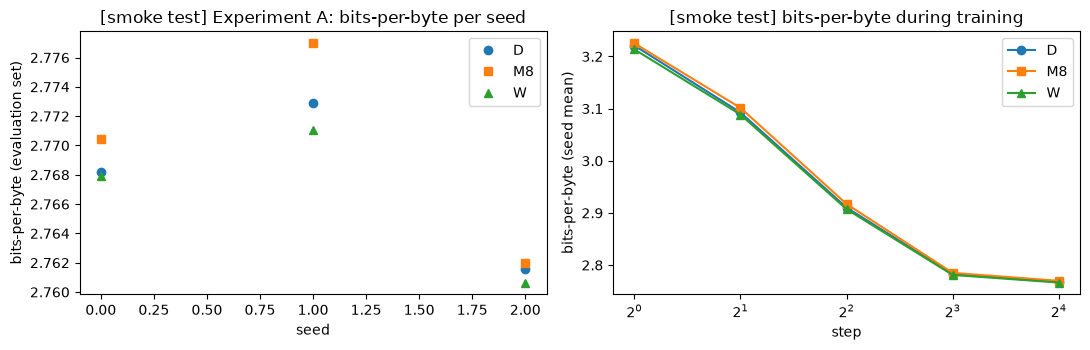

In [11]:
_seeds = list(range(SEEDS_A))
B_D, B_M8 = bits_per_byte_of("D", SEEDS_A), bits_per_byte_of("M8", SEEDS_A)
A_PER_SEED = B_D - B_M8
_boot = bootstrap_bits_per_byte([("D", s) for s in _seeds] + [("M8", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_A].mean(axis=1) - _boot[:, SEEDS_A:].mean(axis=1)
DELTA_A = float(A_PER_SEED.mean())
SIGMA_A = combined_sigma(A_PER_SEED, _boot_contrast)

_p1 = {(c, s): learning_precondition(RUNS[(c, s)]) for c in ("D", "M8") for s in _seeds}
_p2 = {s: load_precondition(RUNS[("M8", s)]) for s in _seeds}
precondition_status["P1(A)"] = all(_p1.values())
precondition_status["P2(A)"] = all(_p2.values())
A_PRECONDITIONS = ["P0(A)", "P1(A)", "P2(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"])
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 A(シード {_seeds}、T = {NUM_STEPS})")
print(f"  bits-per-byte b_D: {rounded(B_D)}、b_M8: {rounded(B_M8)}")
print(f"  d_s = b_D - b_M8: {rounded(A_PER_SEED)}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(A)']}、P1 {precondition_status['P1(A)']}"
    f"(不成立の学習 {[k for k, v in _p1.items() if not v] or 'なし'}、閾値 {P1_LOSS_RATIO} x ln V = {P1_LOSS_RATIO * UNIFORM_LOSS:.3f})、"
    f"P2 {precondition_status['P2(A)']}(M8 の破棄の最大 {max(max(RUNS[('M8', s)]['routing']['dropped']) for s in _seeds):.4f} <= {P2_DROPPED_MAX}、"
    f"最大の負荷 {max(max(RUNS[('M8', s)]['routing']['max_load']) for s in _seeds):.3f} <= {P2_LOAD_FACTOR / 8:.3f})"
)
print(f"  判定関数の結果 {A_COMPUTED} -> {RUN_TAG}最終判定: {A_VERDICT}")

# 診断量(判定なし)
if NUM_SEEDS["W"] > 0:
    _b_w = bits_per_byte_of("W", NUM_SEEDS["W"])
    print(
        f"  診断量: 総パラメータ数を M8 に揃えた密なモデル W(計算量は揃わない)の bits-per-byte {rounded(_b_w)}、平均 {_b_w.mean():.4f}"
        f"(D の平均 {B_D.mean():.4f}、M8 の平均 {B_M8.mean():.4f})"
    )
else:
    print("  診断量: W(総パラメータ数を揃えた密なモデル)は、選ばれた段階では学習していない")
print(f"  診断量: 総パラメータ数 {dumps_compact_json({c: TOTAL_PARAMETERS[c] for c in ('D', 'M8', 'W')})}")
print("  診断量: 評価集合の bits-per-byte の推移(シード平均、評価のステップ " + f"{EVAL_STEPS})")
for _c in ("D", "M8", "W"):
    if NUM_SEEDS[_c] > 0:
        print(f"    {_c}: {rounded(np.mean([RUNS[(_c, s)]['eval_bits_per_byte'] for s in range(NUM_SEEDS[_c])], axis=0))}")
print("  診断量: 汎化の差(評価集合と学習用の部分の窓は別の記事なので、条件間での差の違いを読む)")
for _c in ("D", "M8", "W"):
    if NUM_SEEDS[_c] > 0:
        print(f"    {generalization_gap_line(_c)}")
print(
    f"  診断量: M8 の学習時の破棄の割合(評価と評価の間の学習ステップ、層とシードの最大): "
    f"{rounded(np.max([[max(d['train_dropped']) for d in RUNS[('M8', s)]['eval_diagnostics']] for s in _seeds], axis=0))}"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("D", "o"), ("M8", "s"), ("W", "^")):
    if NUM_SEEDS[_c] > 0:
        _axes[0].plot(range(NUM_SEEDS[_c]), bits_per_byte_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
        _curves = np.array([RUNS[(_c, s)]["eval_bits_per_byte"] for s in range(NUM_SEEDS[_c])])
        _axes[1].plot(EVAL_STEPS, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("bits-per-byte (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment A: bits-per-byte per seed")
_axes[0].legend()
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("bits-per-byte (seed mean)")
_axes[1].set_title(f"{PLOT_TAG}bits-per-byte during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.8 実験 B: 負荷分散損失と負荷の偏り

[スモークテスト] 実験 B(シード [0, 1, 2]、T = 16)
  h_M8(負荷分散損失あり): [0.3461, 0.4368, 0.5235]、h_N8(なし): [0.2169, 0.3187, 0.235]
  d_s = h_M8 - h_N8: [0.1292, 0.1181, 0.2885]
  Delta_B = +0.1786、sigma_B = 0.0552(シード間 0.0550・ブートストラップ 0.0044、反復 1,000)、閾値 2 sigma_B = 0.1104
  前提条件: P0 True、P1 False(不成立の学習 [('M8', 0), ('M8', 1), ('M8', 2), ('N8', 0), ('N8', 1), ('N8', 2)])、P3 False(M8 のルーターの確率の最大値の平均(層平均)[0.161, 0.159, 0.163] >= 0.188)
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 前提不成立
  診断量: h の推移(シード平均、評価のステップ (1, 2, 4, 8, 16))
    M8: [0.8536, 0.5172, 0.3093, 0.2402, 0.4355]
    N8: [0.8185, 0.4848, 0.2908, 0.2161, 0.2569]
    M8(学習の終わり、層ごとのシード平均): 最大の負荷 [0.276, 0.538, 0.669, 0.905]、ほとんど選ばれないエキスパートの数 [0.0, 4.67, 5.67, 6.33]、評価集合で capacity factor 2.0 なら破棄されたはずの割合 [0.0343, 0.4105, 0.5591, 0.6553]、学習時の破棄(最後の区間)[0.2033, 0.6882, 0.76, 0.7939]、確率の最大値の平均 [0.149, 0.164, 0.166, 0.166]、ロジットのノルム [3.54, 1.04, 0.89, 1.0]
    M8: 補助損失(最後の区間の平均、係数を掛ける前、4 層の合計。シード平均): {"load_balancing": 4.9355, "router_z": 14.7758}
    N8(学習の終わり、

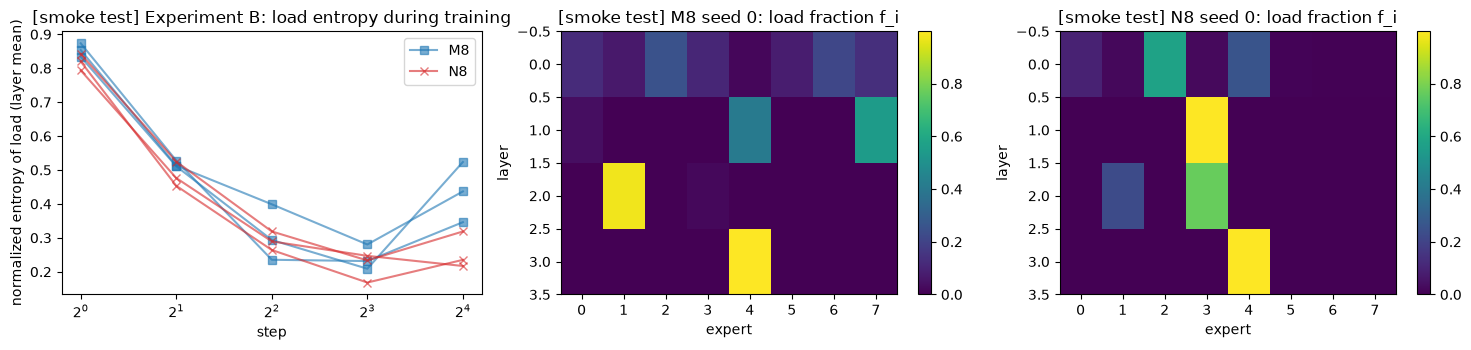

In [12]:
_seeds = list(range(SEEDS_B))
H_M8 = np.array([RUNS[("M8", s)]["routing"]["h"] for s in _seeds])
H_N8 = np.array([RUNS[("N8", s)]["routing"]["h"] for s in _seeds])
B_PER_SEED = H_M8 - H_N8
_boot = bootstrap_normalized_entropy([("M8", s) for s in _seeds] + [("N8", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_B].mean(axis=1) - _boot[:, SEEDS_B:].mean(axis=1)
DELTA_B = float(B_PER_SEED.mean())
SIGMA_B = combined_sigma(B_PER_SEED, _boot_contrast)

_p1 = {(c, s): learning_precondition(RUNS[(c, s)]) for c in ("M8", "N8") for s in _seeds}
_max_probability = np.array([np.mean(RUNS[("M8", s)]["routing"]["max_probability"]) for s in _seeds])
precondition_status["P1(B)"] = all(_p1.values())
precondition_status["P3(B)"] = bool((_max_probability >= P3_MAX_PROBABILITY_FACTOR / 8).all())
B_PRECONDITIONS = ["P0(B)", "P1(B)", "P3(B)"]
B_COMPUTED = judge(DELTA_B, SIGMA_B["sigma"])
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 B(シード {_seeds}、T = {NUM_STEPS})")
print(f"  h_M8(負荷分散損失あり): {rounded(H_M8)}、h_N8(なし): {rounded(H_N8)}")
print(f"  d_s = h_M8 - h_N8: {rounded(B_PER_SEED)}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B['sigma']:.4f}(シード間 {SIGMA_B['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_B['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(B)']}、P1 {precondition_status['P1(B)']}(不成立の学習 {[k for k, v in _p1.items() if not v] or 'なし'})、"
    f"P3 {precondition_status['P3(B)']}(M8 のルーターの確率の最大値の平均(層平均){rounded(_max_probability, 3)} >= {P3_MAX_PROBABILITY_FACTOR / 8:.3f})"
)
print(f"  判定関数の結果 {B_COMPUTED} -> {RUN_TAG}最終判定: {B_VERDICT}")

# 診断量(判定なし)
print(f"  診断量: h の推移(シード平均、評価のステップ {EVAL_STEPS})")
for _c in ("M8", "N8"):
    _recs = [RUNS[(_c, s)] for s in _seeds]
    print(f"    {_c}: {rounded(np.mean([[d['h'] for d in r['eval_diagnostics']] for r in _recs], axis=0))}")
for _c in ("M8", "N8"):
    _recs = [RUNS[(_c, s)] for s in _seeds]
    print(
        f"    {_c}(学習の終わり、層ごとのシード平均): 最大の負荷 {rounded(np.mean([r['routing']['max_load'] for r in _recs], axis=0), 3)}、"
        f"ほとんど選ばれないエキスパートの数 {rounded(np.mean([r['routing']['rare_experts'] for r in _recs], axis=0), 2)}、"
        f"評価集合で capacity factor 2.0 なら破棄されたはずの割合 {rounded(np.mean([r['routing']['dropped'] for r in _recs], axis=0))}、"
        f"学習時の破棄(最後の区間){rounded(np.mean([r['eval_diagnostics'][-1]['train_dropped'] for r in _recs], axis=0))}、"
        f"確率の最大値の平均 {rounded(np.mean([r['routing']['max_probability'] for r in _recs], axis=0), 3)}、"
        f"ロジットのノルム {rounded(np.mean([r['routing']['logit_norm'] for r in _recs], axis=0), 2)}"
    )
    print(
        f"    {_c}: 補助損失(最後の区間の平均、係数を掛ける前、4 層の合計。シード平均): "
        f"{json.dumps({k: round(float(np.mean([r['auxiliary'][k] for r in _recs])), 4) for k in _recs[0]['auxiliary']})}"
    )
_b_m8, _b_n8 = bits_per_byte_of("M8", SEEDS_B), bits_per_byte_of("N8", SEEDS_B)
print(f"  診断量: bits-per-byte b_M8 {rounded(_b_m8)}、b_N8 {rounded(_b_n8)}、差 b_N8 - b_M8 の平均 {float((_b_n8 - _b_m8).mean()):+.4f}")

_fig, _axes = plt.subplots(1, 3, figsize=(15, 3.6))
for _c, _marker in (("M8", "s"), ("N8", "x")):
    for _s in _seeds:
        _axes[0].plot(EVAL_STEPS, [d["h"] for d in RUNS[(_c, _s)]["eval_diagnostics"]], marker=_marker, color="C0" if _c == "M8" else "C3",
                      alpha=0.6, label=_c if _s == 0 else None)
_axes[0].set_xscale("log", base=2)
_axes[0].set_xlabel("step")
_axes[0].set_ylabel("normalized entropy of load (layer mean)")
_axes[0].set_title(f"{PLOT_TAG}Experiment B: load entropy during training")
_axes[0].legend()
for _axis, _c in zip(_axes[1:], ("M8", "N8"), strict=True):
    _fractions = RUNS[(_c, 0)]["counts"].sum(axis=0).astype(np.float64)
    _fractions = _fractions / _fractions.sum(axis=1, keepdims=True)
    _image = _axis.imshow(_fractions, aspect="auto", cmap="viridis", vmin=0.0, vmax=max(0.5, float(_fractions.max())))
    _axis.set_xlabel("expert")
    _axis.set_ylabel("layer")
    _axis.set_title(f"{PLOT_TAG}{_c} seed 0: load fraction f_i")
    plt.colorbar(_image, ax=_axis)
plt.tight_layout()
plt.show()

### 6.9 実験 C: エキスパート数の等比スケーリング

[スモークテスト] 実験 C(シード [0, 1, 2]、T = 16)
  bits-per-byte b_1(D): [2.7682, 2.7729, 2.7616]、b_4(M4): [2.7706, 2.7744, 2.7626]、b_16(M16): [2.7695, 2.7773, 2.7628]
  g_low = (b_1 - b_4) / 2: [-0.0012, -0.0008, -0.0005]、g_high = (b_4 - b_16) / 2: [0.0006, -0.0014, -0.0001]
  d_s = g_low - g_high: [-0.0018, 0.0007, -0.0004]
  Delta_C = -0.0005、sigma_C = 0.0008(シード間 0.0007・ブートストラップ 0.0003、反復 1,000)、閾値 2 sigma_C = 0.0015
  前提条件: P0 True、P1 False(不成立の学習 [('D', 0), ('D', 1), ('D', 2), ('M4', 0), ('M4', 1), ('M4', 2), ('M16', 0), ('M16', 1), ('M16', 2)])、P2 False(不成立の学習 [('M4', 1), ('M4', 2), ('M16', 0), ('M16', 1), ('M16', 2)])
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: g_low の平均 -0.0008(標準偏差 0.0004)、g_high の平均 -0.0003(標準偏差 0.0006)
  診断量: 全水準(E、シード数、bits-per-byte の平均とシード間の標準偏差、h・最大の負荷 x E・capacity factor 2.0 なら破棄されたはずの割合の層とシードの最大)
    E =  1(D、3 シード、学習率 0.0024): 2.7676 ± 0.0057
    E =  2(M2、3 シード、学習率 0.0024): 2.7698 ± 0.0064、h 0.4762、最大の負荷 x E 1.99、破棄 0.0000、学習時の破棄(最後の区間)0.3564
    E =  4(M4、3 

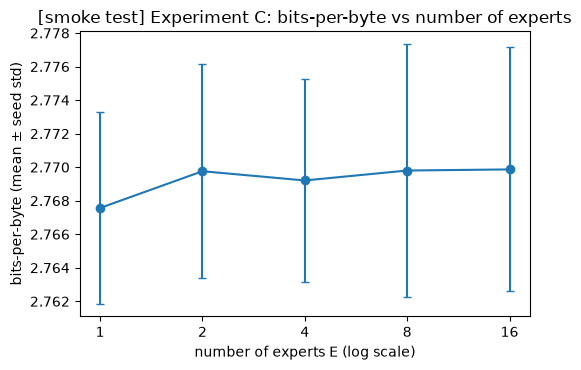

In [13]:
_seeds = list(range(SEEDS_C))
_levels = {"D": 1, "M2": 2, "M4": 4, "M8": 8, "M16": 16}
B1, B4, B16 = (bits_per_byte_of(c, SEEDS_C) for c in ("D", "M4", "M16"))
G_LOW, G_HIGH = (B1 - B4) / 2, (B4 - B16) / 2
C_PER_SEED = G_LOW - G_HIGH
_boot = bootstrap_bits_per_byte([(c, s) for c in ("D", "M4", "M16") for s in _seeds])
_b1, _b4, _b16 = (_boot[:, i * SEEDS_C : (i + 1) * SEEDS_C].mean(axis=1) for i in range(3))
_boot_contrast = (_b1 - 2 * _b4 + _b16) / 2
DELTA_C = float(C_PER_SEED.mean())
SIGMA_C = combined_sigma(C_PER_SEED, _boot_contrast)
assert math.isclose(DELTA_C, float((B1 - 2 * B4 + B16).mean() / 2), abs_tol=1e-12)

_c_conditions = [c for c in _levels if NUM_SEEDS[c] > 0]
_p1 = {(c, s): learning_precondition(RUNS[(c, s)]) for c in ("D", "M4", "M16") for s in _seeds}
_p2 = {(c, s): load_precondition(RUNS[(c, s)]) for c in ("M4", "M16") for s in _seeds}
precondition_status["P1(C)"] = all(_p1.values())
precondition_status["P2(C)"] = all(_p2.values())
C_PRECONDITIONS = ["P0(C)", "P1(C)", "P2(C)"]
C_COMPUTED = judge(DELTA_C, SIGMA_C["sigma"])
C_VERDICT = C_COMPUTED if all(precondition_status[k] for k in C_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 C(シード {_seeds}、T = {NUM_STEPS})")
print(f"  bits-per-byte b_1(D): {rounded(B1)}、b_4(M4): {rounded(B4)}、b_16(M16): {rounded(B16)}")
print(f"  g_low = (b_1 - b_4) / 2: {rounded(G_LOW)}、g_high = (b_4 - b_16) / 2: {rounded(G_HIGH)}")
print(f"  d_s = g_low - g_high: {rounded(C_PER_SEED)}")
print(
    f"  Delta_C = {DELTA_C:+.4f}、sigma_C = {SIGMA_C['sigma']:.4f}(シード間 {SIGMA_C['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_C['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_C = {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(C)']}、P1 {precondition_status['P1(C)']}(不成立の学習 {[k for k, v in _p1.items() if not v] or 'なし'})、"
    f"P2 {precondition_status['P2(C)']}(不成立の学習 {[k for k, v in _p2.items() if not v] or 'なし'})"
)
print(f"  判定関数の結果 {C_COMPUTED} -> {RUN_TAG}最終判定: {C_VERDICT}")

# 診断量(判定なし)
_g_low, _g_high = combined_sigma(G_LOW, (_b1 - _b4) / 2), combined_sigma(G_HIGH, (_b4 - _b16) / 2)
print(
    f"  診断量: g_low の平均 {G_LOW.mean():+.4f}(標準偏差 {_g_low['sigma']:.4f})、g_high の平均 {G_HIGH.mean():+.4f}(標準偏差 {_g_high['sigma']:.4f})"
)
print(
    "  診断量: 全水準(E、シード数、bits-per-byte の平均とシード間の標準偏差、h・最大の負荷 x E・"
    "capacity factor 2.0 なら破棄されたはずの割合の層とシードの最大)"
)
_means, _stds = {}, {}
for _c in _c_conditions:
    _b = bits_per_byte_of(_c, NUM_SEEDS[_c])
    _means[_c], _stds[_c] = float(_b.mean()), float(_b.std(ddof=1))
    _line = f"    E = {_levels[_c]:>2}({_c}、{NUM_SEEDS[_c]} シード、学習率 {LEARNING_RATE[_c]:.3g}): {_means[_c]:.4f} ± {_stds[_c]:.4f}"
    if _c != "D":
        _recs = [RUNS[(_c, s)] for s in range(NUM_SEEDS[_c])]
        _line += (
            f"、h {np.mean([r['routing']['h'] for r in _recs]):.4f}、最大の負荷 x E {max(max(r['routing']['max_load']) for r in _recs) * _levels[_c]:.2f}、"
            f"破棄 {max(max(r['routing']['dropped']) for r in _recs):.4f}、"
            f"学習時の破棄(最後の区間){max(max(r['eval_diagnostics'][-1]['train_dropped']) for r in _recs):.4f}"
        )
    print(_line)
print("  診断量: 汎化の差(評価集合と学習用の部分の窓は別の記事なので、条件間での差の違いを読む)")
for _c in _c_conditions:
    print(f"    {generalization_gap_line(_c)}")

_fig, _axis = plt.subplots(figsize=(5.5, 3.8))
_x = [math.log2(_levels[c]) for c in _c_conditions]
_axis.errorbar(_x, [_means[c] for c in _c_conditions], yerr=[_stds[c] for c in _c_conditions], marker="o", capsize=3)
_axis.set_xticks(_x)
_axis.set_xticklabels([str(_levels[c]) for c in _c_conditions])
_axis.set_xlabel("number of experts E (log scale)")
_axis.set_ylabel("bits-per-byte (mean ± seed std)")
_axis.set_title(f"{PLOT_TAG}Experiment C: bits-per-byte vs number of experts")
plt.tight_layout()
plt.show()

### 6.10 観察 D: エキスパートの専門化(判定基準を設けない)

実験 A の MoE(M8、シード 0)の学習の最終ステップの重みで、評価集合の各位置の **入力トークンの種類**(5.3 節の 6 種類)と、その位置の
表現が送られたエキスパート(破棄の前の割り当て)の対応を、層ごとに数える。層ごとに、種類を行・エキスパートを列とする分割表を、
行ごとに割合にして印字する(行の和が 1)。あわせて、種類とエキスパートの正規化した相互情報量
$I(X; Y) / \min(H(X), H(Y))$ を層ごとに示す($X$ はトークンの種類、$Y$ は割り当て先のエキスパート。独立なら 0、一方が他方の
関数なら 1)。

**読み方の注意**: これは 1 つの学習(1 シード)の観察であり、判定基準を設けない。層 1 以降の入力は、注意機構によって文脈が混ざった
表現であり、「その位置のトークンの種類」は割り当てを説明しうる要因の 1 つにすぎない。種類の分類は語彙の文字列だけから決めた
粗い規則である。

[スモークテスト] 観察 D(M8・シード 0、評価集合の 7,680 トークン)
  層 0: 正規化した相互情報量 0.0343。種類ごとの割り当ての割合(列はエキスパート 0〜7)
    数字(n = 211): [0.13, 0.1, 0.19, 0.16, 0.01, 0.09, 0.22, 0.1]
    句読点・記号・空白(n = 304): [0.21, 0.06, 0.2, 0.07, 0.02, 0.12, 0.27, 0.06]
    機能語(n = 1,697): [0.16, 0.03, 0.38, 0.13, 0.01, 0.06, 0.21, 0.02]
    内容語の先頭(n = 2,635): [0.09, 0.06, 0.22, 0.11, 0.02, 0.08, 0.22, 0.2]
    単語の途中の部分語(n = 2,404): [0.12, 0.1, 0.22, 0.09, 0.03, 0.09, 0.2, 0.14]
    その他(n = 429): [0.13, 0.09, 0.21, 0.09, 0.01, 0.03, 0.19, 0.24]
  層 1: 正規化した相互情報量 0.0650。種類ごとの割り当ての割合(列はエキスパート 0〜7)
    数字(n = 211): [0.06, 0.0, 0.0, 0.0, 0.27, 0.0, 0.0, 0.67]
    句読点・記号・空白(n = 304): [0.02, 0.0, 0.0, 0.0, 0.62, 0.0, 0.0, 0.36]
    機能語(n = 1,697): [0.03, 0.0, 0.0, 0.0, 0.69, 0.0, 0.0, 0.28]
    内容語の先頭(n = 2,635): [0.03, 0.0, 0.0, 0.0, 0.31, 0.0, 0.0, 0.65]
    単語の途中の部分語(n = 2,404): [0.04, 0.0, 0.0, 0.0, 0.33, 0.0, 0.0, 0.63]
    その他(n = 429): [0.05, 0.0, 0.0, 0.0, 0.31, 0.0, 0.0, 0.64]
  層 2: 正規化した相互情報量 0.0479。種類ごとの割り当ての割合(列はエキスパート

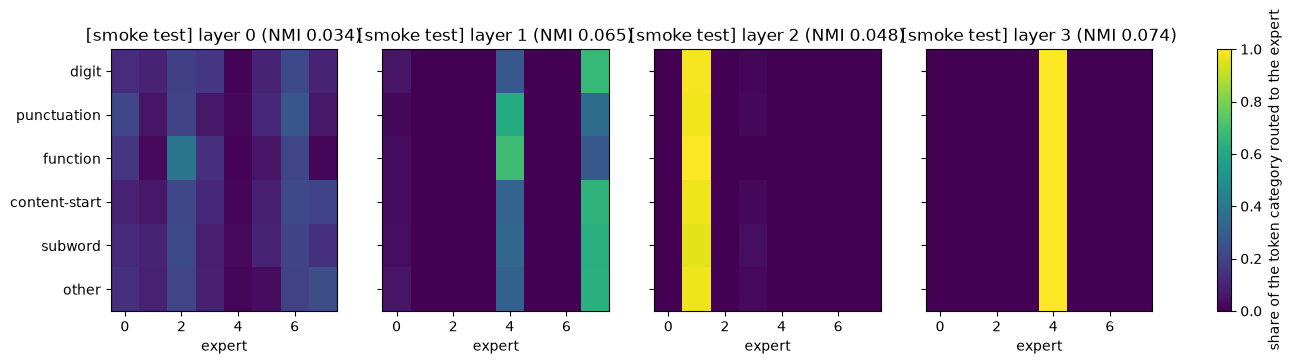

In [14]:
_record = RUNS[OBSERVATION_RUN]
_token_category = TOKEN_CATEGORY[EVAL_WINDOWS.numpy()]  # (窓, 位置)
_num_experts = CONDITIONS[OBSERVATION_RUN[0]]["experts"]
SPECIALIZATION_TABLES, SPECIALIZATION_NMI = [], []
print(f"{RUN_TAG}観察 D({OBSERVATION_RUN[0]}・シード {OBSERVATION_RUN[1]}、評価集合の {_token_category.size:,} トークン)")
for _layer in range(NUM_LAYERS):
    _table = np.zeros((len(TOKEN_CATEGORIES), _num_experts))
    np.add.at(_table, (_token_category.reshape(-1), _record["token_routing"][:, _layer].reshape(-1)), 1)
    assert _table.sum() == _token_category.size
    assert np.array_equal(_table.sum(axis=0), _record["counts"][:, _layer].sum(axis=0))  # 評価の割り当ての個数と一致
    SPECIALIZATION_TABLES.append(_table)
    SPECIALIZATION_NMI.append(compute_normalized_mutual_information(_table))
    print(f"  層 {_layer}: 正規化した相互情報量 {SPECIALIZATION_NMI[-1]:.4f}。種類ごとの割り当ての割合(列はエキスパート 0〜{_num_experts - 1})")
    for _i, _label in enumerate(TOKEN_CATEGORY_LABELS):
        _row = _table[_i] / max(_table[_i].sum(), 1.0)
        print(f"    {_label}(n = {int(_table[_i].sum()):,}): {rounded(_row, 2)}")

_fig, _axes = plt.subplots(1, NUM_LAYERS, figsize=(4.2 * NUM_LAYERS, 3.4), sharey=True)
for _layer, _axis in enumerate(_axes):
    _rows = SPECIALIZATION_TABLES[_layer] / np.maximum(SPECIALIZATION_TABLES[_layer].sum(axis=1, keepdims=True), 1.0)
    _image = _axis.imshow(_rows, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    _axis.set_xlabel("expert")
    _axis.set_title(f"{PLOT_TAG}layer {_layer} (NMI {SPECIALIZATION_NMI[_layer]:.3f})")
    _axis.set_yticks(range(len(TOKEN_CATEGORIES)))
    _axis.set_yticklabels(TOKEN_CATEGORIES)
plt.colorbar(_image, ax=_axes, label="share of the token category routed to the expert")
plt.show()

### 6.11 不変条件のアサーションと`SMOKE_TEST`の配線

- 実効水準の照合: 実際に学習した条件・シード・ステップ数・評価のステップが、5.2 節で印字した水準と 6.4 節で選ばれた計画に一致する。
- 対応のある比較: 同じシードの条件どうしで、順伝播ネットワーク以外の初期値が一致する(異なるシードでは異なる)。
- 全条件で、学習ステップ数・バッチサイズ・系列長(したがって見たトークン数)・評価窓・bits-per-byte の分母が同じである。
- D と M8 の学習は 1 回だけで、実験 A・B・C が同じ記録を共有している。
- 学習率が、較正した値または規則で決めた値に一致する。
- 各対比量と診断量が何個のシードで計算されたかを印字し、選ばれた段階の条件ごとのシード数(6.1 節の削る段階の表)と一致する
  ことを確かめる。
- 評価は破棄なしで行われ(`evaluate_model()`の中で、層が数えた破棄が 0 であることを毎回確かめている)、P2 と診断量の
  「破棄されたはずの割合」が、記録した割り当ての個数から作り直した値と一致する。

In [15]:
# --- 実効水準の照合(SMOKE_TEST の配線) ---
assert SELECTED_PLAN in PLANS and NUM_STEPS in STEP_CANDIDATES and NUM_SEEDS == STAGES[CURRENT_LEVEL_NAME][STAGE]
assert set(RUNS) == {(c, s) for c in CONDITIONS for s in range(NUM_SEEDS[c])}
for (_c, _s), _r in RUNS.items():
    assert _r["num_steps"] == NUM_STEPS == len(_r["train_loss"]), (_c, _s)
    assert tuple(_r["eval_step"]) == EVAL_STEPS and len(_r["eval_bits_per_byte"]) == len(EVAL_STEPS)
    assert _r["nll"].shape == (len(EVAL_WINDOWS),) and math.isfinite(_r["train_bits_per_byte"])
    assert _r["learning_rate"] == LEARNING_RATE[_c] == CALIBRATION[LEARNING_RATE_SOURCE[_c]]["chosen"]
    if CONDITIONS[_c]["kind"] == "moe":
        assert _r["counts"].shape == (len(EVAL_WINDOWS), NUM_LAYERS, CONDITIONS[_c]["experts"])
        assert (_r["counts"].sum(axis=2) == SEQUENCE_LENGTH).all()  # どの窓・層でも、全位置が 1 個ずつ割り当てられている
        # 「破棄されたはずの割合」は、記録した割り当ての個数から作り直した値と一致する
        assert _r["routing"]["dropped"] == reference_dropped_fraction(_r["counts"], SEQUENCE_LENGTH)
assert SMOKE_TEST or len(EVAL_WINDOWS) == NUM_EVAL_WINDOWS_AVAILABLE  # 本番は評価集合の全部の窓
assert BOOTSTRAP_RESAMPLES == LEVELS[CURRENT_LEVEL_NAME]["BOOTSTRAP_RESAMPLES"]
assert set(CALIBRATION) == set(calibration_targets(CALIBRATION_MODE, NUM_SEEDS))
for _c, _r in CALIBRATION.items():
    assert len(_r["grid"]) in (3, 4) and (len(_r["grid"]) == 4) == (_r["extended"] is not None)

# --- 対応のある比較: 同じシードの条件どうしで順伝播ネットワーク以外の初期値が同じ、異なるシードでは異なる ---
for _s in range(max(NUM_SEEDS.values())):
    _hashes = {RUNS[(c, _s)]["trunk_hash"] for c in CONDITIONS if NUM_SEEDS[c] > _s}
    assert len(_hashes) == 1, _s
assert len({RUNS[("D", s)]["trunk_hash"] for s in range(NUM_SEEDS["D"])}) == NUM_SEEDS["D"]

# --- 実験 A・B・C が同じ D・M8 の記録を使っている(学習を重複させていない) ---
assert np.array_equal(B_D[:SEEDS_C], B1) and np.array_equal(B_M8[:SEEDS_B], bits_per_byte_of("M8", SEEDS_B))
# --- 量ごとのシード数(削る段階でシード数を減らした条件が入る量は、共通するシードだけで計算する) ---
SEED_COUNTS = {
    "Delta_A(D・M8)": len(A_PER_SEED),
    "Delta_B(M8・N8)": len(B_PER_SEED),
    "Delta_C(D・M4・M16)": len(C_PER_SEED),
    "汎化の差の D との対応(条件: 共通するシード数)": {c: min(NUM_SEEDS[c], NUM_SEEDS["D"]) for c in CONDITIONS if c != "D" and NUM_SEEDS[c] > 0},
    "実験 C の図の水準(条件: シード数)": {c: NUM_SEEDS[c] for c in ("D", "M2", "M4", "M8", "M16")},
    "W(実験 A の診断量)": NUM_SEEDS["W"],
}
assert SEED_COUNTS["Delta_A(D・M8)"] == SEEDS_A == min(NUM_SEEDS["D"], NUM_SEEDS["M8"])
assert SEED_COUNTS["Delta_B(M8・N8)"] == SEEDS_B == NUM_SEEDS["N8"] <= NUM_SEEDS["M8"]
assert SEED_COUNTS["Delta_C(D・M4・M16)"] == SEEDS_C == NUM_SEEDS["M16"] <= NUM_SEEDS["M4"] == NUM_SEEDS["D"]
assert len(H_M8) == len(H_N8) == SEEDS_B and len(B1) == len(B4) == len(B16) == SEEDS_C
print(f"量ごとのシード数(段階 {STAGE}、条件ごとのシード数 {json.dumps(NUM_SEEDS)}): {json.dumps(SEED_COUNTS, ensure_ascii=False)}")
_trained = sum(NUM_SEEDS.values())
_calibrated = sum(len(r["grid"]) for r in CALIBRATION.values())
print(
    f"実効水準: 水準 {CURRENT_LEVEL_NAME!r}、計画 {SELECTED_PLAN['plan']}(T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})、"
    f"本番の学習 {_trained} 回・較正の学習 {_calibrated} 回、評価窓 {len(EVAL_WINDOWS)} 個・記事 {NUM_EVAL_ARTICLES} 本、"
    f"ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回"
)
print("不変条件(実効水準、対応のある初期値、ステップ数・評価窓・分母の一致、記録の共有、学習率の出どころ): OK")

量ごとのシード数(段階 0、条件ごとのシード数 {"D": 3, "M8": 3, "N8": 3, "M4": 3, "M16": 3, "M2": 3, "W": 3}): {"Delta_A(D・M8)": 3, "Delta_B(M8・N8)": 3, "Delta_C(D・M4・M16)": 3, "汎化の差の D との対応(条件: 共通するシード数)": {"M2": 3, "M4": 3, "M8": 3, "M16": 3, "N8": 3, "W": 3}, "実験 C の図の水準(条件: シード数)": {"D": 3, "M2": 3, "M4": 3, "M8": 3, "M16": 3}, "W(実験 A の診断量)": 3}
実効水準: 水準 'smoke'、計画 0(T = 16、較正の方式 'all'、段階 0)、本番の学習 21 回・較正の学習 21 回、評価窓 30 個・記事 15 本、ブートストラップ 1,000 回
不変条件(実効水準、対応のある初期値、ステップ数・評価窓・分母の一致、記録の共有、学習率の出どころ): OK


### 6.12 判定結果の一覧

In [16]:
print(f"{RUN_TAG}判定結果(計画 {SELECTED_PLAN['plan']}、T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})")
for _name, _delta, _sigma, _computed, _verdict, _preconditions in (
    ("実験 A(計算量を揃えた密なモデルとの比較)", DELTA_A, SIGMA_A["sigma"], A_COMPUTED, A_VERDICT, A_PRECONDITIONS),
    ("実験 B(負荷分散損失と負荷の偏り)", DELTA_B, SIGMA_B["sigma"], B_COMPUTED, B_VERDICT, B_PRECONDITIONS),
    ("実験 C(エキスパート数の等比スケーリング)", DELTA_C, SIGMA_C["sigma"], C_COMPUTED, C_VERDICT, C_PRECONDITIONS),
):
    print(
        f"  {_name}: 対比量 {_delta:+.4f}、標準偏差 {_sigma:.4f}、閾値 {SIGMA_MULTIPLIER * _sigma:.4f}、"
        f"前提条件 {json.dumps({k: precondition_status[k] for k in _preconditions}, ensure_ascii=False)}、"
        f"判定関数の結果 {_computed} -> 最終判定 {_verdict}"
    )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

[スモークテスト] 判定結果(計画 0、T = 16、較正の方式 'all'、段階 0)
  実験 A(計算量を揃えた密なモデルとの比較): 対比量 -0.0022、標準偏差 0.0012、閾値 0.0025、前提条件 {"P0(A)": true, "P1(A)": false, "P2(A)": false}、判定関数の結果 判定不能 -> 最終判定 前提不成立
  実験 B(負荷分散損失と負荷の偏り): 対比量 +0.1786、標準偏差 0.0552、閾値 0.1104、前提条件 {"P0(B)": true, "P1(B)": false, "P3(B)": false}、判定関数の結果 支持 -> 最終判定 前提不成立
  実験 C(エキスパート数の等比スケーリング): 対比量 -0.0005、標準偏差 0.0008、閾値 0.0015、前提条件 {"P0(C)": true, "P1(C)": false, "P2(C)": false}、判定関数の結果 判定不能 -> 最終判定 前提不成立

ノートブック全体の実行時間: 10.8 分


## 7. 結果・考察 / Results and Discussion

**この節の本文は、本番実行(Google Colab T4、`SMOKE_TEST = False`)の後に、実際のセル出力と突き合わせて書く。** 現在のセル出力は
スモークテスト(ステップ数を極端に縮小したもの)であり、数値にも判定にも意味はない。以下は、各節に何を書くかの一覧である。

判定(7.3〜7.5 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.7 節に分けて記し、検証済みの結論としては
扱わない。

### 7.1 実行の概要

- 実行環境(5.1 節の印字を出典とする): GPU、Python・torch・CUDA・cuDNN の版、コミット、実行日時、精度。
- 準備と計測の時間、定常状態の 1 ステップの時間(条件の種類ごと)、べき指数とべき乗則の外挿と比例の値の差、バッチサイズへの依存。
- 選ばれた実行計画($T$・較正の方式・段階)と、見積もりと実際の時間の対応。
- 学習率の較正の結果(格子点ごとの値、拡張の有無、選んだ学習率、指標とは別の観点の量)。

### 7.2 前提条件

- P0〜P3 の成否を実験ごとに表にする。不成立があれば、その実験は「前提不成立」として記録し、判定関数の参考値を結論として書かない。

### 7.3 実験 A: 計算量を揃えた密なモデルとの比較

- 最終判定、$\Delta_A$・$\sigma_A$(シード間とブートストラップの内訳)・閾値。
- 診断量: W の bits-per-byte、途中の評価の位置ごとの bits-per-byte、M8 の負荷と破棄の割合。
- 汎化の差の読み取り: D・M8・W の、評価集合と学習用の部分の窓の bits-per-byte の差。パラメータ数の多い条件(M8・W)で差が
  大きいか(過学習の兆候があるか)。同じシードの D との差(対応付き)の符号がシードをまたいで揃っているかも見る。選ばれた $T$ が学習用のトークンの何エポック分にあたるかとあわせて書く。
- 検出力の事前確認(6.2 節)の見込みと、実際の $\sigma_A$ の対応。

### 7.4 実験 B: 負荷分散損失と負荷の偏り

- 最終判定、$\Delta_B$・$\sigma_B$・閾値。
- 診断量: $h$ の推移(どの時点で差が現れたか)、最大の負荷、ほとんど選ばれないエキスパートの数、破棄の割合、補助損失の値、
  bits-per-byte の差。

### 7.5 実験 C: エキスパート数の等比スケーリング

- 最終判定、$\Delta_C$・$\sigma_C$・閾値。
- 診断量: $g_{\mathrm{low}}$・$g_{\mathrm{high}}$ の値と符号($\Delta_C$ と分けて記述する)、全水準の bits-per-byte と $\log_2 E$ の図、
  各水準の負荷と破棄の割合。
- 選ばれた $T$ と、学習が飽和していない状態での比較であることの扱い。
- 汎化の差の読み取り: 全水準($E = 1, 2, 4, 8, 16$)の、評価集合と学習用の部分の窓の bits-per-byte の差。$E$ とともに差が
  大きくなるか(同じシードの D との差の平均と、各シードの符号で読む)。大きくなる場合、$b_{16}$ の悪化が $\Delta_C$ を正の向きに偏らせうること(6.1 節)との関係を書く。

### 7.6 観察 D: エキスパートの専門化(判定基準を設けない)

- 層ごとの対応表と正規化した相互情報量の読み取り。1 シードの観察であることを明記する。

### 7.7 事後的な解釈(検証済みの結論ではない)

最終判定が支持以外(反証・判定不能・前提不成立)になった実験について、「なぜそうなったか」を次の 4 項目で書く。前提不成立の実験では、
「なぜ前提が崩れたか」と「判定関数の参考値がなぜその向きになったか」を別々の問いとして扱う。

| 項目 | 書くこと |
|---|---|
| 原因の候補 | 設計(条件・水準・較正の格子・学習量など)と、実際に起きた現象の両面から挙げる |
| 根拠 | セル出力の診断量のうち、その候補を支持または否定するもの。根拠となる数値がない候補は、その旨を明記する |
| 確かめる方法 | その候補が正しいかを検証するには、どういう追加の実験が要るか(実行はしない) |
| 教訓 | 次のトピックの設計に持ち越せる一般的な事項 |

- 実験 A(該当する場合)
- 実験 B(該当する場合)
- 実験 C(該当する場合)
- 共通: 結論の一般化の制約(モデルとデータの規模、学習量、1 台の GPU 上の固定形状の実装であること)

### 本番実行の後に更新が必要な箇所

1. 5.1 節のセットアップセルの`SMOKE_TEST`を`False`にして実行した出力に、全セルの出力を置き換える(Colab で実行)。
2. 1.2 節「本番実行の結果の要約」を記入する。
3. 7.1〜7.7 節の本文を、本番のセル出力と突き合わせて書く(7.7 節は、支持以外の判定になった実験について 4 項目を書く)。
4. `theories/README.md`の 022 の行に、結果の要約を追記する。
5. 本番のコミットは、5.1 節のセットアップセルのアサーション(`a835c21`の子孫で、それ自身ではなく、追跡しているファイルに未コミットの変更がないこと。
   満たさなければ学習の前に停止する)で確かめられる。セットアップセルの出力に「本番の実行条件: … OK」が印字されていることを確認する。